## 1. Imports and Environment Setup


In [ ]:
import os
os.environ["HF_HUB_OFFLINE"] = "1"
os.environ["TRANSFORMERS_OFFLINE"] = "1"
import sys
import re
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
from rank_bm25 import BM25Okapi
import torch
from sentence_transformers import SentenceTransformer, util
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
import implicit
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from wordcloud import WordCloud
from rank_bm25 import BM25Okapi
import itertools
from tqdm import tqdm
from matplotlib.patches import Rectangle
import time
from sklearn.metrics import mean_squared_error, jaccard_score
import math
import psutil
from lightgbm import LGBMClassifier
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import psutil
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter, defaultdict
from tqdm import tqdm
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
import random
from lightgbm import LGBMRanker

# Ensure NLTK downloads
from nltk.corpus import wordnet
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\leewe\AppData\Roaming\nltk

## 2. Import Dataset

In [ ]:
print("Loading dataset...")
ds = load_dataset("TechWolf/vacancy-job-to-skill", split="validation")
df = ds.to_pandas()

Using the latest cached version of the dataset since TechWolf/vacancy-job-to-skill couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at C:\Users\leewe\.cache\huggingface\datasets\TechWolf___vacancy-job-to-skill\default\0.0.0\1bfa8942fc75e40c3996159876a8b8593b4c07e6 (last modified on Mon May 25 16:18:05 2026).


Loading dataset...


## 3. Data Preview

In [ ]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 5,644
Columns: 2


In [ ]:
df.head()

,vacancy_job_title,tagged_esco_skills
0,Retail Sales Associate - La Plaza,"[provide high quality customer service, satisfy customers, communicate with customers, maintain ..."
1,"Guest Advocate (Cashier), General Merchandise, Inbound (Stocking) (T3226)","[operate cash register, work independently, manage guest support services, arrange pick‐up, work..."
2,RN Branch Manager Community Care,"[provide clinical advice to team members, apply information security policies, implement policy ..."
3,Compounder - Earn Up to $22/Hour + Great Benefits,"[maintain a safe, hygienic and secure working environment, maintain personal hygiene standards, ..."
4,"Travel Nurse RN - Admin/Mgmt in Seaford, DE","[work in shifts, surgery, coordinate shifts, provide comprehensive care for patients with surgic..."


In [ ]:
columns_to_check = ['vacancy_job_title', 'tagged_esco_skills']
subset_dup_count = df.astype({'tagged_esco_skills': str}).duplicated(subset=columns_to_check).sum()

print(f"Number of duplicated rows: {subset_dup_count}")

Number of duplicated rows: 0


In [ ]:
print(f"Total raw records: {len(df)}")

Total raw records: 5644


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5644 entries, 0 to 5643
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   vacancy_job_title   5644 non-null   str   
 1   tagged_esco_skills  5644 non-null   object
dtypes: object(1), str(1)
memory usage: 294.7+ KB


In [ ]:
df.columns

Index(['vacancy_job_title', 'tagged_esco_skills'], dtype='str')

In [ ]:
df.isnull().sum()

vacancy_job_title     0
tagged_esco_skills    0
dtype: int64

## 4. Text Preprocessing and Cleaning Functions


In [ ]:
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r"\w+[\+#]*|\.\w+")

RARE_SKILLS_NOISE = set()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def clean_fluff_and_compensation(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\[.*?\]|\(.*?\)", "", text)
    compensation_patterns = [
        r"\baverage\s+(?:up\s+to\s+)?\$?\d+(?:[,\d]+)?(?:\s*/\s*(?:hour|hr|weekly|wk|month|yr|year))?\b",
        r"\$\d+(?:[,\d]+)?(?:\s*/\s*(?:hour|hr|weekly|wk|month|yr|year|75mins))?",
        r"\b\d+k\b",
        r"\b(?:sign[- ]on|retention|joining)\s+bonus(?:es)?\b",
        r"\b(?:excellent|competitive|great|medical|dental|vision)\s+benefit(?:s)?\b",
        r"\bcompetitive\s+(?:pay|salary|rate)\b",
        r"\bwith\s+tips\b",
        r"\bplus\s+tips\b",
        r"\bhourly\s+plus\s+tips\b"
    ]
    for pattern in compensation_patterns:
        text = re.sub(pattern, "", text, flags=re.IGNORECASE)

    recruitment_fluff = r"\b(?:we\s+(?:are\s+)?seeking(?:\s+for)?|now\s+hiring|hiring|urgently\s+hiring|immediate(?:ly)?\s+start|immediate\s+opening|needed\s+for|apply\s+now|urgent(?:ly)?|immediate|wanted)\b"
    text = re.sub(recruitment_fluff, "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+\+\s+", " ", text)
    text = re.sub(r"\s+\+\s*$", "", text)
    text = re.sub(r"[-–—/]", " ", text)

    employment_noise = r"\b(?:full\s+time|part\s+time|contract|temporary|temp|internship|co\s+op|freelance|shift|shifts|flexible\s+hours?)\b"
    text = re.sub(employment_noise, "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()

    while True:
        new_text = re.sub(r"\s+(?:for|at|with|in|and|or|of|to|from|a|an|the|all|about)\s*$", "", text, flags=re.IGNORECASE)
        new_text = re.sub(r"^[^a-zA-Z0-9+#.]+|[^a-zA-Z0-9+#.]+$", "", new_text)
        if new_text == text:
            break
        text = new_text
    return text

def clean_job_title(title):
    if not isinstance(title, str): return ""
    cleaned = clean_fluff_and_compensation(title)
    salary_time_noise = r"\b(?:per|week|weeks|weekly|hour|hours|hourly|pay|salary|up\s+to|months?|days?|mrt|nearest|avp|rd|road|st|street|ave|avenue|available)\b"
    cleaned = re.sub(salary_time_noise, "", cleaned, flags=re.IGNORECASE)
    seniority_noise = r"\b(?:senior|associate|entry\s+level|hybrid|graduate|start|level\s+[i|v|x|\d]+|lvl\s*\d+|level\s*\d+)\b|\b(?:sr|jr)\b\.?"
    cleaned = re.sub(seniority_noise, "", cleaned, flags=re.IGNORECASE)
    cleaned = cleaned.strip().lower()
    cleaned = re.sub(r"\s+", " ", cleaned)
    if "travel nurse" in cleaned or "travel rn" in cleaned:
        return "travel nurse"
    elif "register nurse" in cleaned or "registered nurse" in cleaned or re.search(r"\brn\b", cleaned):
        return "registered nurse"
    elif "customer service" in cleaned:
        return "customer service representative"
    elif "software engineer" in cleaned or "software developer" in cleaned:
        return "software engineer"
    return cleaned

def deep_clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower().replace("&", " and ")
    text = re.sub(r"[^a-z0-9\s+#.]", " ", text)
    tokens = tokenizer.tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    corporate_noise = {"business", "group", "infrastructure", "strategic", "apply", "year", "yearly", "urgently","entry", "level", "full", "time", "part"}
    cleaned_tokens = []
    for word, tag in pos_tags:
        if (len(word) > 1 or word in {"r", "c"}) \
           and word not in stop_words \
           and word not in corporate_noise \
           and word not in RARE_SKILLS_NOISE \
           and not word.isdigit():
            wordnet_pos = get_wordnet_pos(tag)
            lemmatized_word = lemmatizer.lemmatize(word, pos=wordnet_pos)
            cleaned_tokens.append(lemmatized_word)
    return " ".join(cleaned_tokens)

def light_clean_text_SBERT(text_SBERT):
    if not isinstance(text_SBERT, str): return ""
    cleaned = clean_fluff_and_compensation(text_SBERT)
    cleaned = cleaned.lower()
    cleaned = re.sub(r"[^a-z0-9\s+#.]", " ", cleaned)
    tokens = cleaned.split()
    tokens = [w for w in tokens if w not in RARE_SKILLS_NOISE]
    cleaned = " ".join(tokens)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [ ]:
df['cleaned_title'] = df['vacancy_job_title'].apply(clean_job_title).apply(deep_clean_text)
df['cleaned_title_sbert'] = df['vacancy_job_title'].apply(light_clean_text_SBERT)

display(df.sample(5))

,vacancy_job_title,tagged_esco_skills,cleaned_title,cleaned_title_sbert
1350,Cyber Engineer,"[unmanned air systems, cyber security, military aviation, risk management, align software with s...",cyber engineer,cyber engineer
248,Physician / Internal Medicine / Kentucky / Permanent / Internal Medicine Primary Care Physician Job,"[treat medical conditions of elderly people, multi-professional cooperation in health care, comp...",physician internal medicine kentucky permanent internal medicine primary care physician job,physician internal medicine kentucky permanent internal medicine primary care physician job
3420,Product Line Manager (PLM),"[perform political negotiation, moderate in negotiations, conduct public presentations]",product line manager,product line manager
439,Experienced Automated Machine Operator (Surface),[write English],experienced automate machine operator,experienced automated machine operator
2317,Sr Population/Public Health Manager,"[adapt to change, make data-driven decisions, adapt to changing situations, program management, ...",population public health manager,sr population public health manager


In [ ]:
print(f"Rows BEFORE deduplication: {len(df)}")

df = df.groupby('vacancy_job_title').agg({
    'cleaned_title': 'first',
    'cleaned_title_sbert':'first',
    'tagged_esco_skills': lambda x: list(set([s for sublist in x for s in sublist]))
}).reset_index()

print(f"Rows AFTER deduplication:  {len(df)}")
print("="*50)

Rows BEFORE deduplication: 5644
Rows AFTER deduplication:  5644


## 5. Handle Sparse Data

In [ ]:
title_counts = df['cleaned_title'].value_counts()
total_initial_rows = len(df)
total_initial_unique_titles = len(title_counts)

stats = []
for threshold in [1, 2, 3, 4, 5,6,7,8,9,10]:
    valid_titles = title_counts[title_counts >= threshold].index
    remaining_unique = len(valid_titles)
    remaining_rows = df['cleaned_title'].isin(valid_titles).sum()
    removed_unique = total_initial_unique_titles - remaining_unique
    removed_rows = total_initial_rows - remaining_rows

    stats.append({
        "Threshold (>=)": f"Freq >= {threshold}",
        "Unique Titles Left": remaining_unique,
        "Remaining Dataset Size (Rows)": remaining_rows,
        "% of Original Dataset Left": f"{(remaining_rows / total_initial_rows) * 100:.2f}%",
        "Removed Job Postings (Rows)": removed_rows
    })


analysis_df = pd.DataFrame(stats)
print("=" * 150)
print("             SENSITIVITY ANALYSIS: DATASET SIZE AT EACH FREQUENCY THRESHOLD")
print("=" * 150)
print(analysis_df.to_string(index=False))
print("=" * 150)

             SENSITIVITY ANALYSIS: DATASET SIZE AT EACH FREQUENCY THRESHOLD
Threshold (>=)  Unique Titles Left  Remaining Dataset Size (Rows) % of Original Dataset Left  Removed Job Postings (Rows)
     Freq >= 1                4712                           5644                    100.00%                            0
     Freq >= 2                 123                           1055                     18.69%                         4589
     Freq >= 3                  26                            861                     15.26%                         4783
     Freq >= 4                   9                            810                     14.35%                         4834
     Freq >= 5                   5                            794                     14.07%                         4850
     Freq >= 6                   5                            794                     14.07%                         4850
     Freq >= 7                   4                            788     

In [ ]:
print("Filtering rare titles (threshold = 5)...")

title_counts = df['cleaned_title'].value_counts()
valid_titles = title_counts[title_counts >= 5].index
df = df[df['cleaned_title'].isin(valid_titles)].reset_index(drop=True)
print(f"Total raw records: {len(df)}")

Filtering rare titles (threshold = 5)...
Total raw records: 794


In [ ]:
all_skills = df['tagged_esco_skills'].explode()
skill_counts = Counter(all_skills)
total_initial_skills = len(skill_counts)
total_initial_rows = len(df)

stats = []
for threshold in [1, 2, 3, 4, 5, 10]:
    valid_skills = {s for s, c in skill_counts.items() if c >= threshold}
    remaining_unique_skills = len(valid_skills)
    temp_skills_required = df['tagged_esco_skills'].apply(lambda x: [s for s in x if s in valid_skills])
    temp_num_skills = temp_skills_required.apply(len)
    remaining_rows = (temp_num_skills > 0).sum()
    removed_unique_skills = total_initial_skills - remaining_unique_skills
    removed_rows = total_initial_rows - remaining_rows

    stats.append({
        "Skill Threshold (>=)": f"Freq >= {threshold}",
        "Unique Skills Left": remaining_unique_skills,
        "Unique Skills Removed": removed_unique_skills,
        "Remaining Dataset Size (Rows)": remaining_rows, # 剩余岗位数据行数
        "% of Original Dataset Left": f"{(remaining_rows / total_initial_rows) * 100:.2f}%",
        "Postings Removed (Rows)": removed_rows
    })

analysis_df = pd.DataFrame(stats)
print("=" * 150)
print("             SENSITIVITY ANALYSIS: DATASET SIZE AT EACH SKILL FREQUENCY THRESHOLD")
print("=" * 150)
print(analysis_df.to_string(index=False))
print("=" * 150)

             SENSITIVITY ANALYSIS: DATASET SIZE AT EACH SKILL FREQUENCY THRESHOLD
Skill Threshold (>=)  Unique Skills Left  Unique Skills Removed  Remaining Dataset Size (Rows) % of Original Dataset Left  Postings Removed (Rows)
           Freq >= 1                3260                      0                            794                    100.00%                        0
           Freq >= 2                1986                   1274                            792                     99.75%                        2
           Freq >= 3                1458                   1802                            790                     99.50%                        4
           Freq >= 4                1167                   2093                            786                     98.99%                        8
           Freq >= 5                 980                   2280                            785                     98.87%                        9
          Freq >= 10                

In [ ]:
print("Filtering rare skills (threshold = 5)...")

all_skills = df['tagged_esco_skills'].explode()
skill_counts = Counter(all_skills)
valid_skills = {s for s, c in skill_counts.items() if c >= 10}
df['skills_required'] = df['tagged_esco_skills'].apply(lambda x: [s for s in x if s in valid_skills])
df['num_skills'] = df['skills_required'].apply(len)
df = df[df['num_skills'] > 0].reset_index(drop=True)
print(f"Total raw records: {len(df)}")

Filtering rare skills (threshold = 5)...
Total raw records: 771


## 6. Exploratory Data Analysis (EDA)

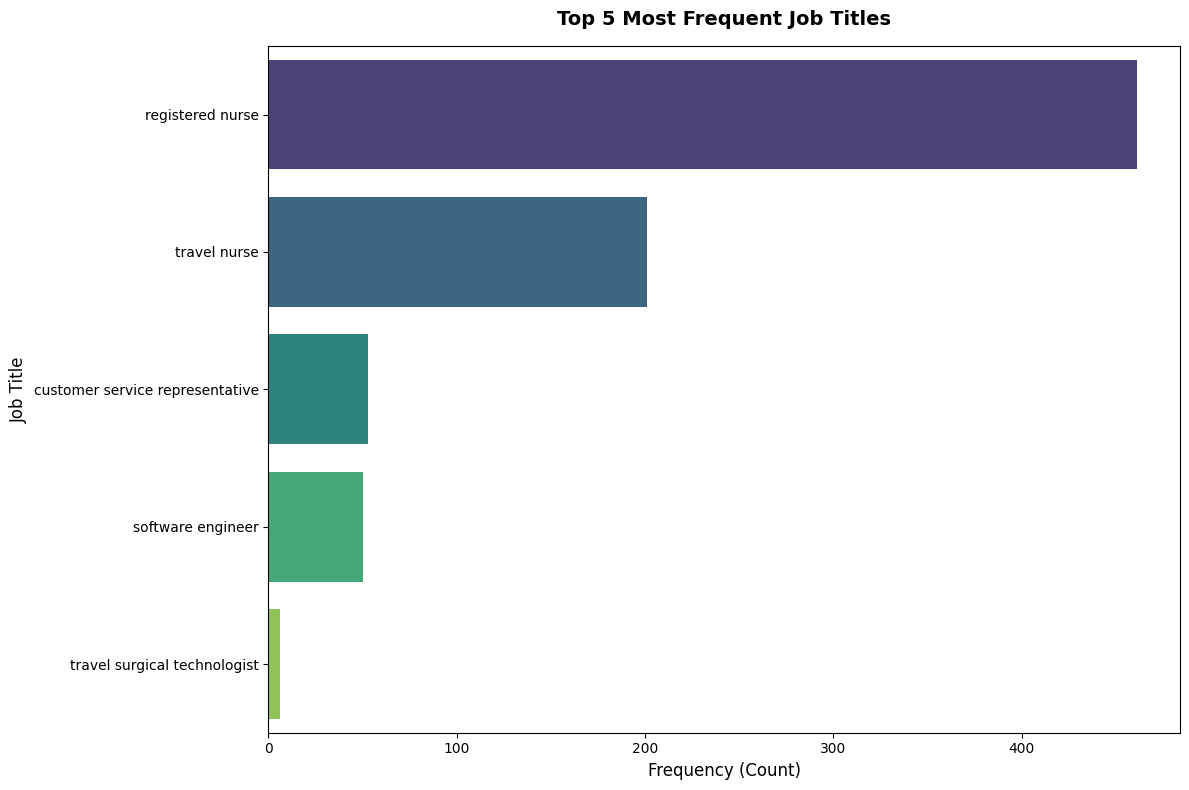

In [ ]:
top_20_titles = df['cleaned_title'].value_counts().head(5)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_titles.values, y=top_20_titles.index, palette='viridis')
plt.title('Top 5 Most Frequent Job Titles', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency (Count)', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.tight_layout()
plt.show()

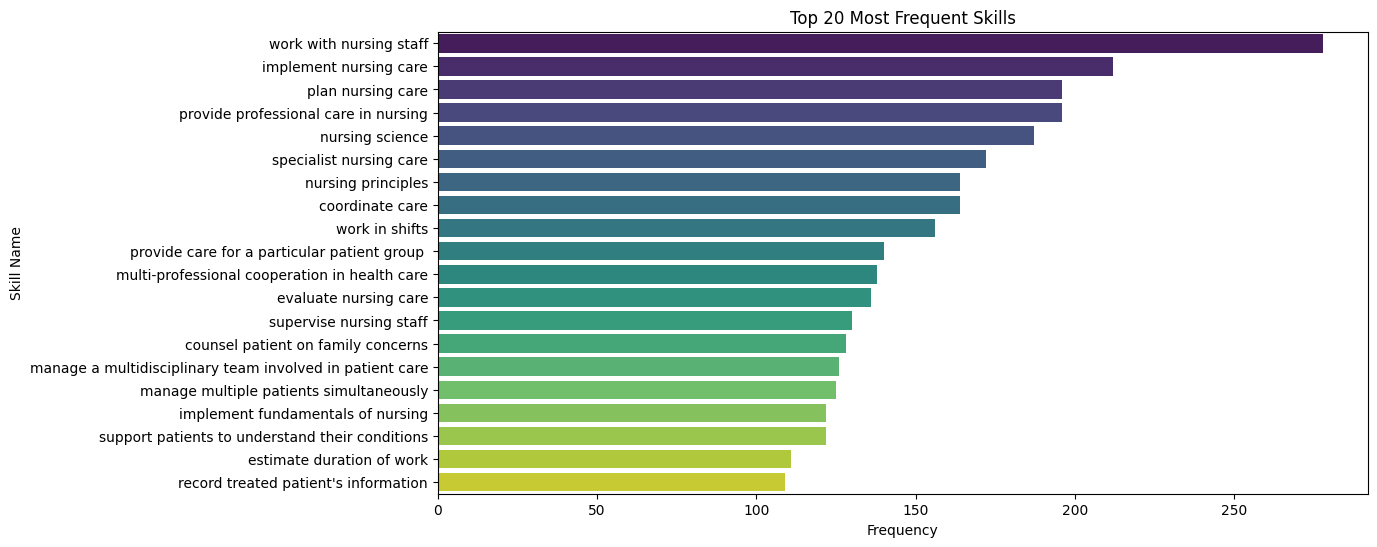

In [ ]:
all_skills = [skill for sublist in df['skills_required'] for skill in sublist]
skill_counts = Counter(all_skills)
common_skills = skill_counts.most_common(20)

plt.figure(figsize=(12, 6))
skills, counts = zip(*common_skills)
sns.barplot(x=list(counts), y=list(skills), palette='viridis')
plt.title('Top 20 Most Frequent Skills')
plt.xlabel('Frequency')
plt.ylabel('Skill Name')
plt.show()

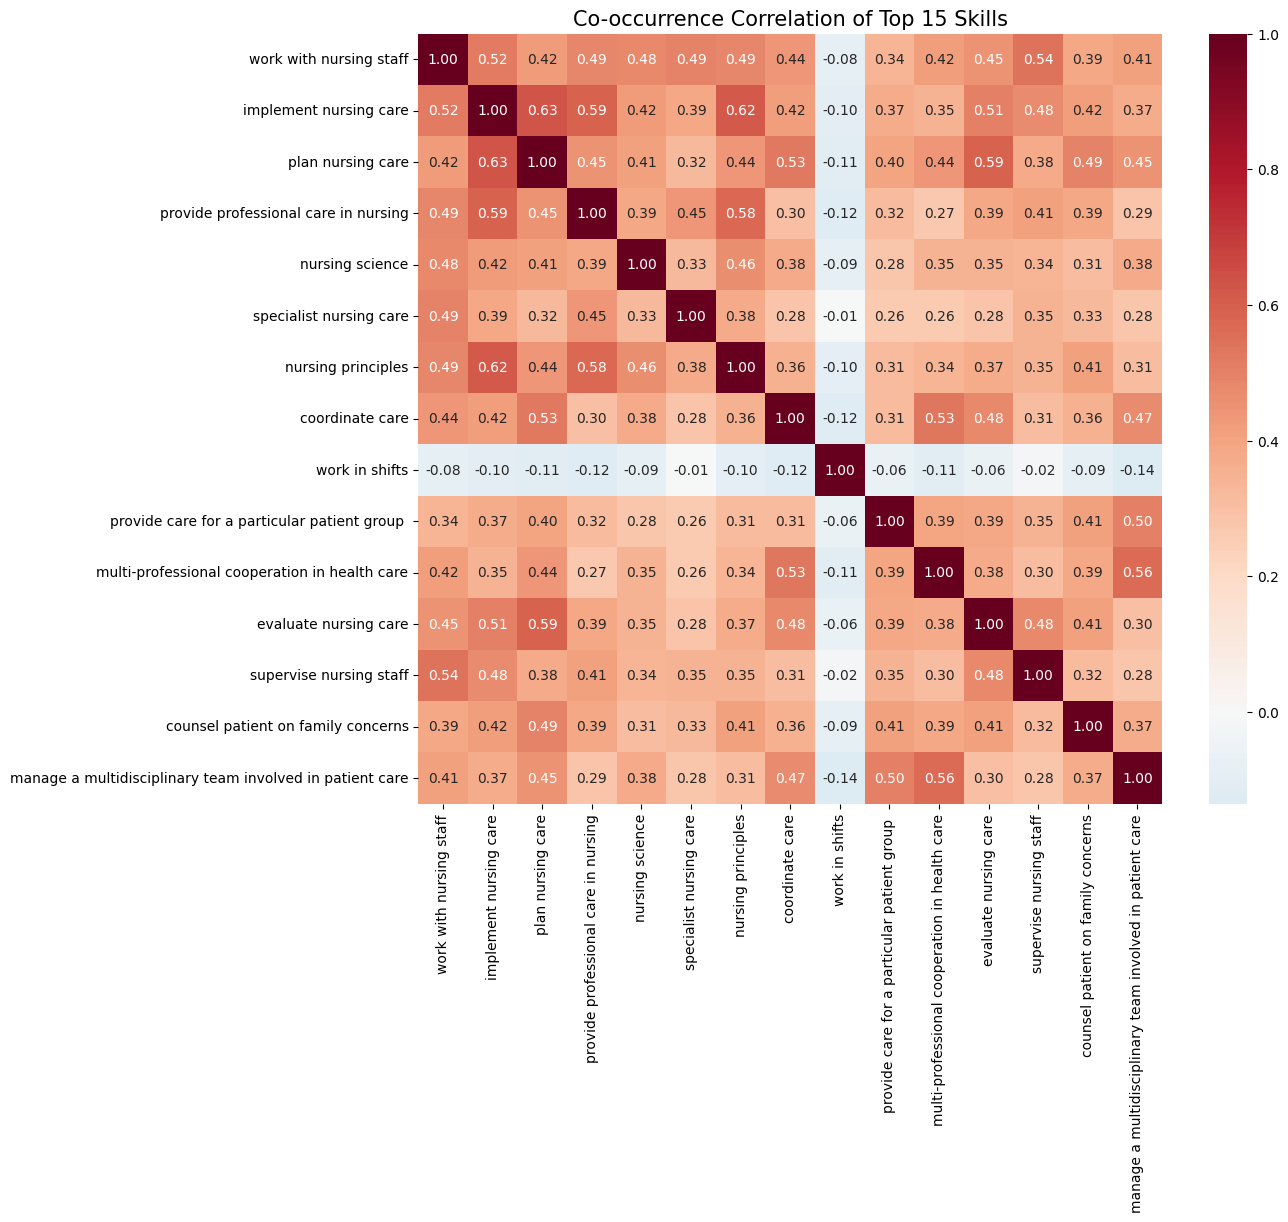

In [ ]:
top_15_skills = [s for s, c in skill_counts.most_common(15)]

mlb = MultiLabelBinarizer(classes=top_15_skills)
skills_matrix = mlb.fit_transform(df['skills_required'])
skills_df = pd.DataFrame(skills_matrix, columns=top_15_skills)

correlation_matrix = skills_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Co-occurrence Correlation of Top 15 Skills', fontsize=15)
plt.show()

In [ ]:
print("Skill Complexity Statistical Summary:")
print(df['skills_required'].apply(len).describe().apply(lambda x: f"{x:,.2f}" if x > 100 else f"{x:.2f}"))

Skill Complexity Statistical Summary:
count    771.00
mean      20.02
std       23.94
min        1.00
25%        3.00
50%       11.00
75%       28.00
max      144.00
Name: skills_required, dtype: str


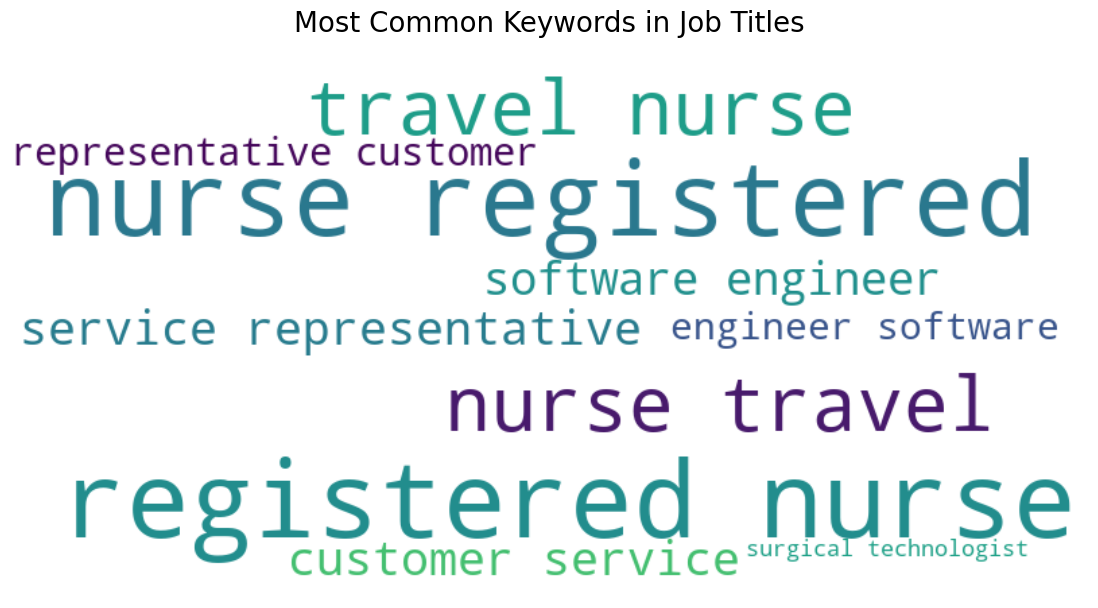

In [ ]:
all_titles = ' '.join(df['cleaned_title'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100).generate(all_titles)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Keywords in Job Titles', fontsize=20, pad=20)
plt.show()

In [ ]:
skill_freq = pd.Series(skill_counts)
rare_skills = skill_freq[skill_freq < 5]
print(f"Total unique skills: {len(skill_freq)}")
print(f"Number of rare skills (appearing < 5 times): {len(rare_skills)}")
print(f"Percentage of rare skills: {(len(rare_skills)/len(skill_freq))*100:.2f}%")

print("\nExamples of Rare Specialized Skills:")
print(rare_skills.sample(10) if len(rare_skills) >= 10 else rare_skills)

Total unique skills: 501
Number of rare skills (appearing < 5 times): 0
Percentage of rare skills: 0.00%

Examples of Rare Specialized Skills:
Series([], dtype: int64)


In [ ]:
skill_freq = pd.Series(skill_counts)
rare_skills = skill_freq[skill_freq < 10]
print(f"Total unique skills: {len(skill_freq)}")
print(f"Number of rare skills (appearing < {10} times): {len(rare_skills)}")
print(f"Percentage of rare skills: {(len(rare_skills)/len(skill_freq))*100:.2f}%")

print("\nExamples of Rare Specialized Skills:")
print(rare_skills.sample(10) if len(rare_skills) >= 10 else rare_skills)

Total unique skills: 501
Number of rare skills (appearing < 10 times): 0
Percentage of rare skills: 0.00%

Examples of Rare Specialized Skills:
Series([], dtype: int64)


## 7. Train/test Split

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

Train size: 539
Val size:   116
Test size:  116


## 8. Evaluation Metrics Definition


In [ ]:
def recall_at_k(y_true, y_pred, k=20):
    scores = [len(set(t).intersection(p[:k]))/len(t) if len(t)>0 else 0 for t, p in zip(y_true, y_pred)]
    return np.mean(scores) * 100

def precision_at_k(y_true, y_pred, k=20):
    scores = [len(set(t).intersection(p[:k]))/k for t, p in zip(y_true, y_pred)]
    return np.mean(scores) * 100

def f1_at_k(y_true, y_pred, k=20):
    f1_scores = []
    for t, p in zip(y_true, y_pred):
        intersect = len(set(t).intersection(p[:k]))
        prec, rec = intersect/k, intersect/len(t) if len(t)>0 else 0
        f1_scores.append(2*prec*rec/(prec+rec) if (prec+rec)>0 else 0)
    return np.mean(f1_scores) * 100

def ndcg_at_k(y_true, y_pred, k=20):
    scores = []
    for t, p in zip(y_true, y_pred):
        t_set = set(t)
        dcg = sum([1/math.log2(i+2) for i, s in enumerate(p[:k]) if s in t_set])
        idcg = sum([1/math.log2(i+2) for i in range(min(len(t_set), k))])
        scores.append(dcg/idcg if idcg>0 else 0)
    return np.mean(scores) * 100

def map_at_k(y_true, y_pred, k=10):
        ap_scores = []
        for t, p in zip(y_true, y_pred):
            if len(t) == 0: continue
            t_set = set(t)
            p_k = p[:k]
            ap = 0.0
            hits = 0
            for idx, item in enumerate(p_k):
                if item in t_set:
                    hits += 1
                    ap += hits / (idx + 1)
            ap_scores.append(ap / min(len(t_set), k) if min(len(t_set), k) > 0 else 0)
        return np.mean(ap_scores) * 100


def r_precision_at_k(y_true, y_pred, k=10):
    rps = []
    for act, pred in zip(y_true, y_pred):
        act_set = set(act)
        if len(act_set) == 0:
            continue
        s = min(k, len(act_set))
        pred_s = pred[:s]
        hits = len(set(pred_s) & act_set)
        rps.append(hits / s if s > 0 else 0)
    return np.mean(rps) * 100

## 9. BM25 Baseline

In [ ]:
df.head()

,vacancy_job_title,cleaned_title,cleaned_title_sbert,tagged_esco_skills,skills_required,num_skills
0,"$15,000.00 Sign on bonus- Experienced Registered Nurse- Med Surge- Duke Regional",registered nurse,.00 experienced registered nurse med surge duke regional,"[prescribe advanced nursing care, maintain equipment, manage a multidisciplinary team involved i...","[prescribe advanced nursing care, manage a multidisciplinary team involved in patient care, mana...",84
1,$15/hr | Customer Service Representative | Start ASAP,customer service representative,customer service representative start asap,[delegate responsibilities],[delegate responsibilities],1
2,"(RN) Registered Nurse $10,000 SIGN ON BONUS",registered nurse,registered nurse,[write job descriptions],[write job descriptions],1
3,(USA) Senior Software Engineer,software engineer,senior software engineer,"[computer programming, NoSQL, supply chain principles, decentralized application frameworks, com...","[computer programming, NoSQL, computer science, cloud technologies, leadership principles, lead ...",20
4,(USA) Software Engineer III - Prototype Engineer (Gen AI),software engineer,software engineer iii prototype engineer,"[apply technical communication skills, design prototypes, model based system engineering, Jenkin...","[computer science, work in teams, collaborate in company's daily operations , apply problem solv...",11


In [ ]:
tokenized_title = [doc.split() for doc in train_df['cleaned_title'].tolist()]

In [ ]:
bm25_title = BM25Okapi(tokenized_title)

In [ ]:
input_configs = {'cleaned_title': tokenized_title}

k1_space = [1.5, 1.8, 2.0, 2.5]
b_space = [0.3, 0.5, 0.75, 0.85]

best_val_f1 = -1
best_config = {}
results_list = []

print(" Grid Search for Best Input Corpus & BM25 Parameters...")
val_sample = val_df

combinations = []
for col_name, corpus in input_configs.items():
    for k1, b in itertools.product(k1_space, b_space):
        combinations.append((col_name, corpus, k1, b))

total_combinations = len(combinations)
current_step = 0

column_best_f1 = {col: -1 for col in input_configs.keys()}

for col_name, corpus, k1, b in tqdm(combinations, desc="Grid Search Progress"):
    current_step += 1
    temp_model = BM25Okapi(corpus, k1=k1, b=b)
    y_true_val, y_pred_val = [], []
    for _, row in val_sample.iterrows():
        y_true_val.append(row['skills_required'])
        query = row[col_name].split()
        scores = temp_model.get_scores(query)
        top_idx = np.argsort(scores)[::-1][:5]
        skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
        y_pred_val.append([s for s, _ in Counter(skills).most_common(5)])
    current_f1 = f1_at_k(y_true_val, y_pred_val, k=5)
    results_list.append({'column': col_name,'k1': k1,'b': b,'F1': current_f1})

    if column_best_f1[col_name] == -1:
        column_best_f1[col_name] = current_f1
        print(f"\n[{col_name}] Initial Baseline: k1={k1}, b={b} -> F1: {current_f1:.2f}%")
        print("-" * 50)
    elif current_f1 > column_best_f1[col_name]:
        old_col_f1 = column_best_f1[col_name]
        column_best_f1[col_name] = current_f1
        print(f"\n[{col_name}] Better Parameters Found: k1={k1}, b={b} -> F1: {current_f1:.2f}% (Improved from {old_col_f1:.2f}%)")
        print("-" * 50)

    if current_f1 > best_val_f1:
        best_val_f1 = current_f1
        best_config = {'column': col_name, 'k1': k1, 'b': b, 'corpus': corpus}

print(f"\nGrid Search Finished!")
print(f"Overall Best Config: {best_config['column']} (k1={best_config['k1']}, b={best_config['b']}) -> Global Best F1: {best_val_f1:.2f}%\n")

best_bm25 = BM25Okapi(best_config['corpus'], k1=best_config['k1'], b=best_config['b'])

results_df = pd.DataFrame(results_list)

 Grid Search for Best Input Corpus & BM25 Parameters...


Grid Search Progress:  12%|███████▋                                                     | 2/16 [00:00<00:00, 15.22it/s]


[cleaned_title] Initial Baseline: k1=1.5, b=0.3 -> F1: 16.88%
--------------------------------------------------


Grid Search Progress: 100%|████████████████████████████████████████████████████████████| 16/16 [00:00<00:00, 16.71it/s]


Grid Search Finished!
Overall Best Config: cleaned_title (k1=1.5, b=0.3) -> Global Best F1: 16.88%



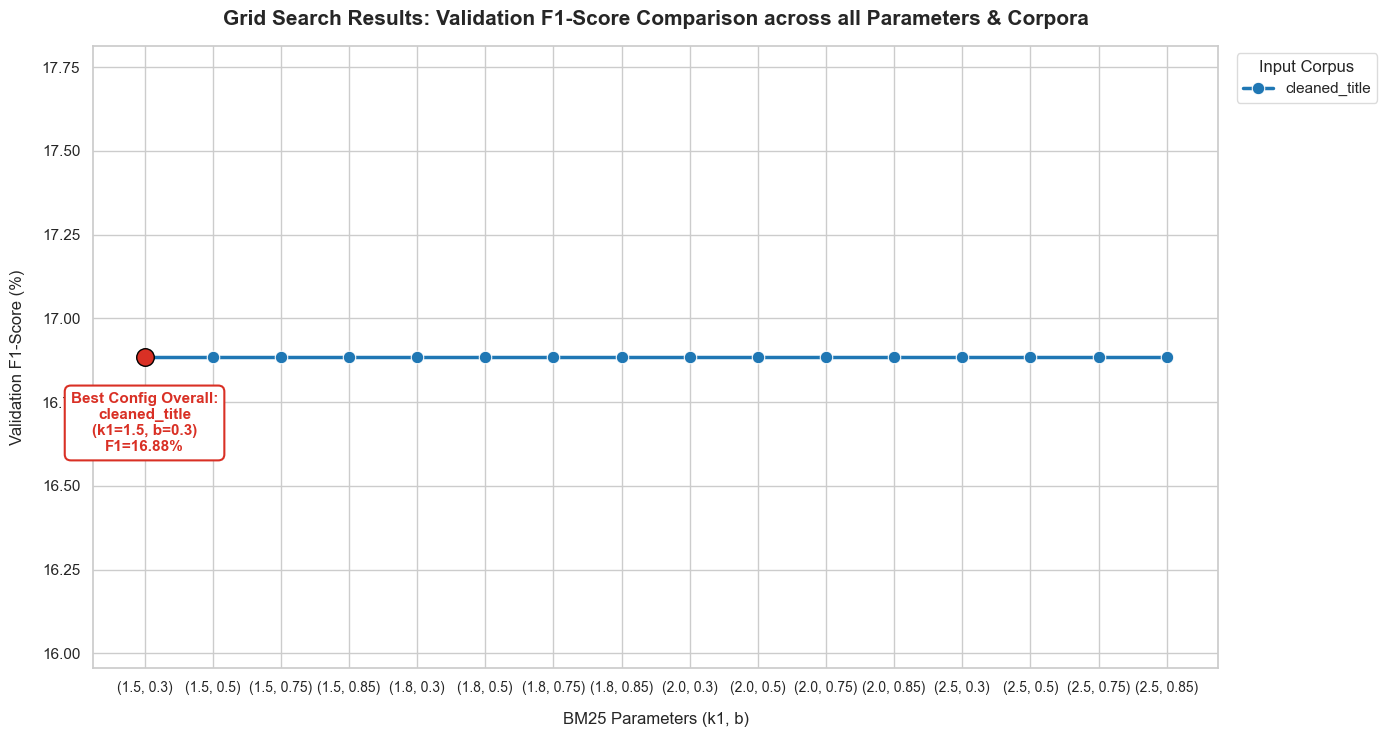

In [ ]:
results_df['param_comb'] = results_df.apply(lambda r: f"({r['k1']}, {r['b']})", axis=1)
param_order = [f"({k1}, {b})" for k1, b in itertools.product(k1_space, b_space)]
results_df['param_comb'] = pd.Categorical(results_df['param_comb'], categories=param_order, ordered=True)
results_df = results_df.sort_values(by=['column', 'param_comb'])

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.family': 'sans-serif','font.size': 11,'axes.labelsize': 13,'axes.titlesize': 14,'xtick.labelsize': 10,'ytick.labelsize': 11})
plt.figure(figsize=(14, 7.5))
sns.lineplot(data=results_df,x='param_comb',y='F1',hue='column',style='column',markers=True,dashes=False,linewidth=2.5,markersize=9,palette='tab10')

best_idx = results_df['F1'].idxmax()
best_row = results_df.loc[best_idx]
best_x = best_row['param_comb']
best_y = best_row['F1']
best_col = best_row['column']

plt.scatter(best_x, best_y, color='#d93025', s=160, zorder=5, edgecolor='black')
plt.annotate(
    f"Best Config Overall:\n{best_col}\n(k1={best_row['k1']}, b={best_row['b']})\nF1={best_y:.2f}%",
    (best_x, best_y),
    textcoords="offset points",
    xytext=(0, -25),
    ha='center',
    va='top',
    color='#d93025',
    weight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5)
)
plt.title("Grid Search Results: Validation F1-Score Comparison across all Parameters & Corpora", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("BM25 Parameters (k1, b)", fontsize=12, labelpad=12)
plt.ylabel("Validation F1-Score (%)", fontsize=12, labelpad=12)
plt.legend(title="Input Corpus", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True, facecolor='white', edgecolor='lightgray', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
target_col = best_config['column']
print(f"Joint Tuning for Neighbors (Top-N) and Recommended Skills (Top-K)...")
print(f"Using Best Corpus: '{target_col}' | k1: {best_config['k1']} | b: {best_config['b']}")
print("-" * 70)

neighbor_space = [1, 2, 3, 5, 10, 15, 20, 30, 35, 50, 100, 150, 200]
skill_k_space = [2, 5, 10, 15, 20, 25, 30, 40, 50]

joint_results = []

for top_n in tqdm(neighbor_space, desc="Joint Tuning Progress"):
    y_true_val = []
    predictions_dict = {k: [] for k in skill_k_space}
    for _, row in val_sample.iterrows():
        y_true_val.append(row['skills_required'])
        query = row[target_col].split()
        scores = best_bm25.get_scores(query)
        top_idx = np.argsort(scores)[::-1][:top_n]
        skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
        most_common_skills = [s for s, _ in Counter(skills).most_common(max(skill_k_space))]
        for k in skill_k_space:
            predictions_dict[k].append(most_common_skills[:k])
    for k in skill_k_space:
        current_f1 = f1_at_k(y_true_val, predictions_dict[k], k=k)
        joint_results.append({'top_n': top_n,'top_k': k,'F1': current_f1})
tuning_df = pd.DataFrame(joint_results)
best_row = tuning_df.loc[tuning_df['F1'].idxmax()]
best_top_n = int(best_row['top_n'])
best_top_k = int(best_row['top_k'])
best_f1 = best_row['F1']

print("\nBest Hyperparameters Found overall:")
print("="*55)
print(f"   Best Retrieved Neighbors (Top-N):{best_top_n}")
print(f"   Best Recommended Skills (Top-K) :{best_top_k}")
print(f"   Optimal Validation F1-Score     :{best_f1:.2f}%")
print("="*55 + "\n")

Joint Tuning for Neighbors (Top-N) and Recommended Skills (Top-K)...
Using Best Corpus: 'cleaned_title' | k1: 1.5 | b: 0.3
----------------------------------------------------------------------


Joint Tuning Progress: 100%|███████████████████████████████████████████████████████████| 13/13 [00:01<00:00, 12.71it/s]


Best Hyperparameters Found overall:
   Best Retrieved Neighbors (Top-N):35
   Best Recommended Skills (Top-K) :10
   Optimal Validation F1-Score     :23.74%



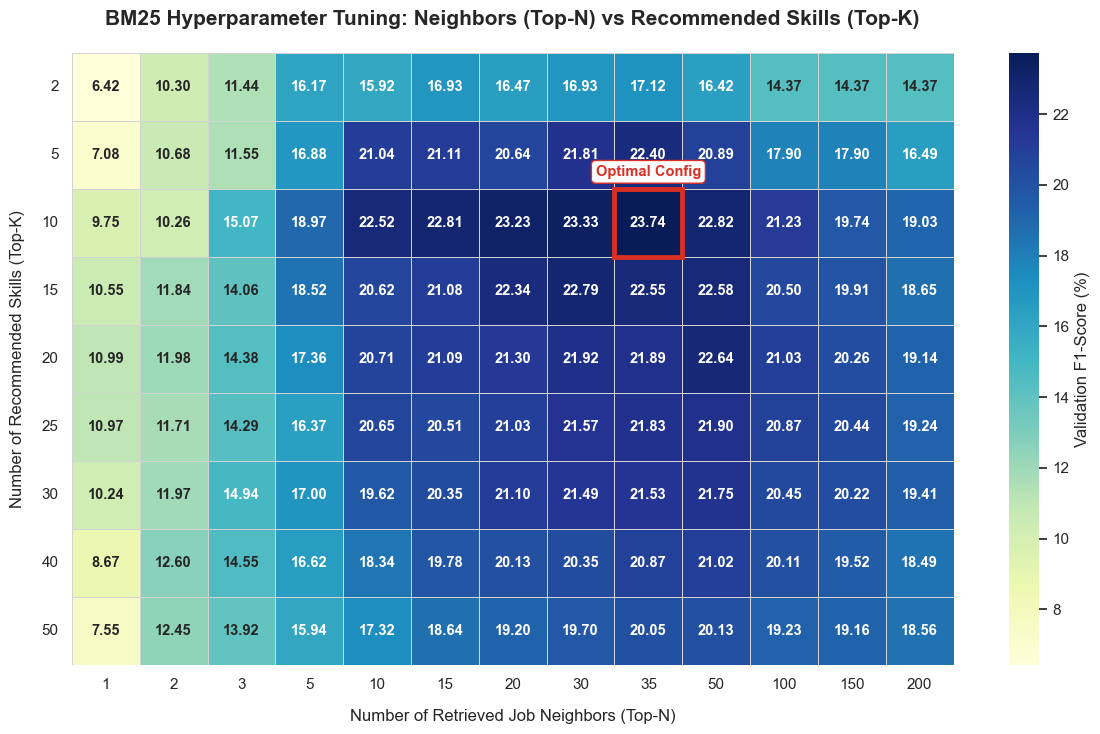

In [ ]:
heatmap_data = tuning_df.pivot(index='top_k', columns='top_n', values='F1')
heatmap_data = heatmap_data.sort_index(ascending=True)

sns.set_theme(style="white")
plt.figure(figsize=(12, 7.5))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Validation F1-Score (%)'},
    linewidths=0.5,
    linecolor='lightgray',
    annot_kws={'size': 10.5, 'weight': 'bold'}
)

max_val = heatmap_data.values.max()
max_loc = np.argwhere(heatmap_data.values == max_val)[0]
best_row_idx = max_loc[0]
best_col_idx = max_loc[1]

ax.add_patch(Rectangle((best_col_idx, best_row_idx), 1,1,fill=False,edgecolor='#d93025',lw=3.5,zorder=10))

ax.text(
    best_col_idx + 0.5,
    best_row_idx - 0.25 if best_row_idx > 0 else best_row_idx + 1.25,
    "Optimal Config",
    color='#d93025',
    weight='bold',
    fontsize=10.5,
    ha='center',
    va='center',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d93025", lw=1)
)

plt.title('BM25 Hyperparameter Tuning: Neighbors (Top-N) vs Recommended Skills (Top-K)', fontsize=15,
fontweight='bold', pad=20)
plt.xlabel('Number of Retrieved Job Neighbors (Top-N)', fontsize=12, labelpad=12)
plt.ylabel('Number of Recommended Skills (Top-K)', fontsize=12, labelpad=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
if 'r_precision_at_k' not in globals():
    def r_precision_at_k(y_true, y_pred, k=10):
        rps = []
        for act, pred in zip(y_true, y_pred):
            act_set = set(act)
            if len(act_set) == 0:
                continue
            s = min(k, len(act_set))
            pred_s = pred[:s]
            hits = len(set(pred_s) & act_set)
            rps.append(hits / s if s > 0 else 0)
        return np.mean(rps)

if 'map_at_k' not in globals():
    def map_at_k(y_true, y_pred, k=10):
        ap_scores = []
        for t, p in zip(y_true, y_pred):
            if len(t) == 0: continue
            t_set = set(t)
            p_k = p[:k]
            ap = 0.0
            hits = 0
            for idx, item in enumerate(p_k):
                if item in t_set:
                    hits += 1
                    ap += hits / (idx + 1)
            ap_scores.append(ap / min(len(t_set), k) if min(len(t_set), k) > 0 else 0)
        return np.mean(ap_scores) * 100

print(f"Evaluating the BEST model on Final Test Set...")
process = psutil.Process()
best_bm25 = BM25Okapi(best_config['corpus'], k1=best_config['k1'], b=best_config['b'])

target_col = best_config['column']

y_true_test, y_pred_test = [], []

start_time = time.time()

for _, row in test_df.iterrows():
    y_true_test.append(row['skills_required'])
    query = row[target_col].split()
    scores = best_bm25.get_scores(query)
    top_idx = np.argsort(scores)[::-1][:best_top_n]
    skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
    top_skills = [s for s, _ in Counter(skills).most_common(best_top_k)]
    y_pred_test.append(top_skills)
end_time = time.time()
inference_time = end_time - start_time

all_skills_test = list(set([s for sub in y_true_test for s in sub] + [s for sub in y_pred_test for s in sub]))

mlb = MultiLabelBinarizer(classes=all_skills_test).fit(all_skills_test)
map_10_score = map_at_k(y_true_test, y_pred_test, k=10)
rp_10_score = r_precision_at_k(y_true_test, y_pred_test, k=10)

print(f"\n{'='*45}")
print(f"---  FINAL TEST RESULTS (@{best_top_k})  ---")
print(f"Precision:  {precision_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"Recall:     {recall_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"F1-Score:   {f1_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"MAP@10:     {map_10_score:.2f}%")
print(f"RP@10:      {rp_10_score:.2f}%")
print(f"NDCG:       {ndcg_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"---------------------------------------------")
print(f"Inference Time: {inference_time:.4f} seconds")
memory_usage = process.memory_info().rss / (1024 * 1024)

Evaluating the BEST model on Final Test Set...

---  FINAL TEST RESULTS (@10)  ---
Precision:  32.16%
Recall:     31.00%
F1-Score:   22.89%
MAP@10:     36.10%
RP@10:      39.87%
NDCG:       47.08%
---------------------------------------------
Inference Time: 0.0561 seconds


In [ ]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)
joblib.dump({'best_config': best_config,'best_top_n': best_top_n,'best_top_k': best_top_k,}, os.path.join(save_dir, "bm25_baseline_best_params.joblib"))

print("Optimal BM25 baseline parameters saved successfully to saved_models/bm25_baseline_best_params.joblib!")

Optimal BM25 baseline parameters saved successfully to saved_models/bm25_baseline_best_params.joblib!


## 10. BM25 Ensemble

In [ ]:
def calculate_relevance(true_skills, candidate_skills):
    set1, set2 = set(true_skills), set(candidate_skills)
    if not set1 or not set2: return
    return len(set1.intersection(set2)) / len(set1.union(set2))

In [ ]:
def prepare_ranking_data(query_df, corpus_df, bm25_models, num_candidates=100):
    X, y, groups = [], [], []
    print(f"Extracting features for {len(query_df)} queries (Retrieval K={num_candidates})...")

    for q_idx, q_row in query_df.iterrows():
        query_tokens = q_row[best_config['column']].split()

        scores = best_bm25.get_scores(query_tokens)

        if q_idx < len(corpus_df):
            scores[q_idx] = -np.inf

        candidate_indices = np.argsort(scores)[::-1][:num_candidates]

        q_words = set(query_tokens)
        f_sl = len(query_tokens)

        f_title_batch = bm25_models['title'].get_batch_scores(q_row['cleaned_title'].split(), candidate_indices)
        for i, idx in enumerate(candidate_indices):
            c_row = corpus_df.iloc[idx]
            f_title = f_title_batch[i]
            c_words = set(c_row['cleaned_title'].split())
            f_overlap = len(q_words.intersection(c_words))
            f_tl = len(c_row['cleaned_title'].split())
            f_sk = len(c_row['skills_required'])
            f_rank = i + 1

            X.append([f_title,f_tl, f_sl, f_sk, f_rank])

            js = calculate_relevance(q_row['skills_required'], c_row['skills_required'])
            y.append(int(js * 10))

        groups.append(num_candidates)
    return np.array(X), np.array(y), groups


In [ ]:
bm25_models = {}
column_mapping = {'title': ('cleaned_title', tokenized_title)}

print("Initializing BM25 feature models with their respective optimal parameters...")
for model_key, (col_name, corpus) in column_mapping.items():
    col_df = results_df[results_df['column'] == col_name]
    best_row = col_df.loc[col_df['F1'].idxmax()]
    best_k1 = best_row['k1']
    best_b = best_row['b']
    bm25_models[model_key] = BM25Okapi(corpus, k1=best_k1, b=best_b)
    print(f" - {model_key}: initialized with k1={best_k1}, b={best_b} (Best F1: {best_row['F1']:.2f}%)")
print("-" * 75)

X_train_rank, y_train_rank, groups_train = prepare_ranking_data(train_df, train_df, bm25_models, num_candidates=100)

y_train_rank = y_train_rank.astype(int)
ranker = lgb.LGBMRanker(
    objective="rank_xendcg",
    metric="ndcg",
    n_estimators=50,
    learning_rate=0.01,
    max_depth=3,
    num_leaves=7,
    min_child_samples=30,
    random_state=42,
    n_jobs=-1
)
ranker.fit(
    X_train_rank, y_train_rank,
    group=groups_train,
    callbacks=[lgb.log_evaluation(period=50)]
)
print("\nLightGBM Training Complete!")


Initializing BM25 feature models with their respective optimal parameters...
 - title: initialized with k1=1.5, b=0.3 (Best F1: 16.88%)
---------------------------------------------------------------------------
Extracting features for 539 queries (Retrieval K=100)...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 173
[LightGBM] [Info] Number of data points in the train set: 53900, number of used features: 5

LightGBM Training Complete!


In [ ]:
def prepare_ensemble_features_with_ns(query_df, corpus_df, bm25_model, sbert_sim_matrix=None, num_candidates=100, num_negatives=20, mask_self=False):
    if isinstance(bm25_model, dict):
        bm25_model = bm25_model.get('title', list(bm25_model.values())[0])
    X, y, groups = [], [], []
    corpus_size = len(corpus_df)
    for i, (q_idx, q_row) in enumerate(query_df.iterrows()):
        query_tokens = q_row['cleaned_title'].split()

        bm25_scores = bm25_model.get_scores(query_tokens).copy()

        if mask_self:
            bm25_scores[i] = -np.inf

        candidate_indices = list(np.argsort(bm25_scores)[::-1][:num_candidates])

        neg_candidates = []
        while len(neg_candidates) < num_negatives:
            rand_idx = random.randint(0, corpus_size - 1)
            if rand_idx != i and rand_idx not in candidate_indices and rand_idx not in neg_candidates:
                neg_candidates.append(rand_idx)

        all_candidates = candidate_indices + neg_candidates
        q_words = set(query_tokens)
        f_sl = len(query_tokens)

        for rank_pos, idx in enumerate(all_candidates):
            c_row = corpus_df.iloc[idx]
            f_bm25 = bm25_scores[idx]
            f_rank = rank_pos + 1 if rank_pos < num_candidates else num_candidates + 50
            f_overlap = len(q_words.intersection(set(c_row['cleaned_title'].split())))
            f_tl = len(c_row['cleaned_title'].split())
            f_sk = len(c_row['skills_required'])

            X.append([f_bm25, f_rank, f_overlap, f_tl, f_sk, f_sl, f_sbert])
            js = calculate_relevance(q_row['skills_required'], c_row['skills_required'])
            y.append(int(js * 10))

        groups.append(num_candidates + num_negatives)

    return np.array(X), np.array(y), groups

In [ ]:
def prepare_skill_level_bm25_features(dataset, bm25_model, is_train, num_candidates_n=30, num_skills_k=10,n_rand_neg=500, mask_self=False):
    if isinstance(bm25_model, dict):
        bm25_model = bm25_model.get('title', list(bm25_model.values())[0])
    X, y, g = [], [], []
    cands_list = []
    all_skills_unique = list(valid_skills)
    target_col = 'cleaned_title'
    all_train_skills = [s for slist in train_df['skills_required'] for s in slist]
    skill_freq_map = Counter(all_train_skills)
    for i, (q_idx, row) in enumerate(dataset.iterrows()):
        rel = set(row['skills_required'])
        if not rel:
            continue
        tq = str(row[target_col]).lower().split()
        if not tq:
            continue
        scores = bm25_model.get_scores(tq).copy()
        if mask_self and q_idx < len(train_df):
            scores[q_idx] = -np.inf
        top_idx = np.argsort(scores)[::-1][:num_candidates_n]
        cooc = Counter()
        ss = {}
        sr = {}
        for rp, nidx in enumerate(top_idx):
            ns = scores[nidx]
            for s in train_df.iloc[nidx]['skills_required']:
                cooc[s] += 1
                if s not in ss or ns > ss[s]:
                    ss[s] = ns
                    sr[s] = rp
        cands = [s for s, _ in cooc.most_common(num_skills_k)]
        if is_train:
            for s in rel:
                if s not in cands:
                    cands.append(s)
            out = [s for s in all_skills_unique if s not in set(cands) and s not in rel]
            if len(out) >= n_rand_neg:
                cands.extend(random.sample(out, n_rand_neg))
        if not cands:
            continue
        g.append(len(cands))
        cands_list.append(cands)
        mx = max(ss.values()) if ss else 1.0
        ts = set(tq)
        for skill in cands:
            fsem = ss.get(skill, 0.)
            fnrm = fsem / mx if mx > 0 else 0.
            frk = sr.get(skill, num_candidates_n + 1)
            co = cooc.get(skill, 0)
            co_ratio = co / num_candidates_n
            in_title = 1 if skill.lower() in str(row['vacancy_job_title']).lower() else 0
            sk = set(str(skill).lower().split())
            jacc = len(ts & sk) / len(ts | sk) if (ts | sk) else 0.
            common_words = len(ts & sk)
            gf = skill_freq_map.get(skill, 0)
            lgf = math.log1p(gf)
            skill_len = len(str(skill).split())
            kc = [keyword_cooccurrence[w][skill] for w in tq if w in keyword_cooccurrence] if'keyword_cooccurrence' in globals() else []
            max_kc = max(kc) if kc else 0
            sum_kc = sum(kc) if kc else 0
            X.append([fsem, fnrm, frk, co, co_ratio,in_title, jacc, common_words,gf, lgf, skill_len,max_kc, sum_kc, 0])
            y.append(1 if skill in rel else 0)
    return np.array(X), np.array(y), g, cands_list

In [ ]:
best_bm25_n_f1 = globals().get('best_top_n', 35)
best_bm25_k_f1 = globals().get('best_top_k', 10)


In [ ]:
opt_n_neg = 400
_n = globals().get('best_bm25_n_f1', 35)
_k = globals().get('best_bm25_k_f1', 10)
eval_k = globals().get('best_bm25_k_f1', 10)

print("Extracting features for hyperparameter tuning...")
Xtr, ytr, gtr, _ = prepare_skill_level_bm25_features(train_df, bm25_models, is_train=True, num_candidates_n=_n, num_skills_k=_k, n_rand_neg=opt_n_neg, mask_self=True)
Xval, yval, gval, val_cands_list = prepare_skill_level_bm25_features(val_df, bm25_models, is_train=False, num_candidates_n=_n, num_skills_k=_k, mask_self=False)

n_estimators_space = [50, 100, 200, 500]
learning_rate_space = [0.01, 0.03, 0.05, 0.1]
num_leaves_space = [7, 15, 31, 63]

best_lgbm_f1 = -1
best_lgbm_params = {}
lgbm_tuning_results = []

print("Starting Grid Search for LGBMRanker Hyperparameters...")
print("="*65)
print(f"{'n_est':>6} | {'lr':>6} | {'leaves':>6} | {'Val F1':>8} | Time")
print("="*65)

combinations = list(itertools.product(n_estimators_space, learning_rate_space, num_leaves_space))

for n_est, lr, leaves in tqdm(combinations, desc="LGBM Tuning"):
    t0 = time.time()

    model = lgb.LGBMRanker(
        objective="rank_xendcg",
        metric="ndcg",
        random_state=42,
        n_jobs=-1,
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=-1 if leaves > 15 else 3,
        num_leaves=leaves,
        min_child_samples=30
    )
    model.fit(Xtr, ytr, group=gtr)
    preds = model.predict(Xval)

    y_true_val = []
    y_pred_val = []

    idx = 0
    for i, gs in enumerate(gval):
        qp = preds[idx:idx+gs]
        qt = yval[idx:idx+gs]
        cands = val_cands_list[i]
        true_skills = [cands[j] for j, label in enumerate(qt) if label == 1]
        y_true_val.append(true_skills)

        top_k_idx = np.argsort(qp)[::-1][:eval_k]
        y_pred_val.append([cands[j] for j in top_k_idx])
        idx += gs

    val_f1 = f1_at_k(y_true_val, y_pred_val, k=eval_k)
    elapsed = time.time() - t0

    lgbm_tuning_results.append({'n_estimators': n_est, 'learning_rate': lr, 'num_leaves': leaves, 'F1': val_f1})
    print(f"{n_est:>6} | {lr:>6.2f} | {leaves:>6} | {val_f1:>7.2f}% | {elapsed:.1f}s")

    if val_f1 > best_lgbm_f1:
        best_lgbm_f1 = val_f1
        best_lgbm_params = {
            'n_estimators': n_est,
            'learning_rate': lr,
            'num_leaves': leaves
        }

print("="*65)
print("\nOptimal LGBMRanker Hyperparameters Found (Loose Mode):")
print("=======================================================")
print(f"   Best n_estimators: {best_lgbm_params['n_estimators']}")
print(f"   Best learning_rate: {best_lgbm_params['learning_rate']}")
print(f"   Best num_leaves:    {best_lgbm_params['num_leaves']}")
print(f"   Best Validation F1: {best_lgbm_f1:.2f}%")
print("=======================================================\n")

save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)
joblib.dump(best_lgbm_params, os.path.join(save_dir, "best_lgbm_params_bm25Ensemble.pkl"))
print("Optimal parameters saved to saved_models/best_lgbm_params_bm25Ensemble.pkl!")

Extracting features for hyperparameter tuning...
Starting Grid Search for LGBMRanker Hyperparameters...
 n_est |     lr | leaves |   Val F1 | Time


LGBM Tuning:   2%|█                                                                     | 1/64 [00:00<00:07,  8.03it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001949 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 228011, number of used features: 11
    50 |   0.01 |      7 |   44.61% | 0.1s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001917 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 228011, number of used features: 11
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

LGBM Tuning:   3%|██▏                                                                   | 2/64 [00:00<00:10,  5.99it/s]

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBM Tuning:  98%|███████████████████████████████████████████████████████████████████▉ | 63/64 [00:25<00:00,  1.21it/s]

   500 |   0.10 |     31 |   44.61% | 1.0s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001571 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 228011, number of used features: 11


LGBM Tuning: 100%|█████████████████████████████████████████████████████████████████████| 64/64 [00:26<00:00,  2.37it/s]

   500 |   0.10 |     63 |   44.61% | 1.5s

Optimal LGBMRanker Hyperparameters Found (Loose Mode):
   Best n_estimators: 50
   Best learning_rate: 0.01
   Best num_leaves:    7
   Best Validation F1: 44.61%

Optimal parameters saved to saved_models/best_lgbm_params_bm25Ensemble.pkl!


In [ ]:
EVAL_MODE = "loose"

if 'r_precision_at_k' not in globals():
    def r_precision_at_k(y_true, y_pred, k=10):
        rps = []
        for act, pred in zip(y_true, y_pred):
            act_set = set(act)
            if len(act_set) == 0:
                continue
            s = min(k, len(act_set))
            pred_s = pred[:s]
            hits = len(set(pred_s) & act_set)
            rps.append(hits / s if s > 0 else 0)
        return np.mean(rps) * 100

if 'map_at_k' not in globals():
    def map_at_k(y_true, y_pred, k=10):
        ap_scores = []
        for t, p in zip(y_true, y_pred):
            if len(t) == 0: continue
            t_set = set(t)
            p_k = p[:k]
            ap = 0.0
            hits = 0
            for idx, item in enumerate(p_k):
                if item in t_set:
                    hits += 1
                    ap += hits / (idx + 1)
            ap_scores.append(ap / min(len(t_set), k) if min(len(t_set), k) > 0 else 0)
        return np.mean(ap_scores) * 100

save_dir = "saved_models"

bm25_param_path = os.path.join(save_dir, "bm25_baseline_best_params.joblib")
if os.path.exists(bm25_param_path):
    bm25_params = joblib.load(bm25_param_path)
    best_config_base = bm25_params.get("best_config", {})
    best_top_n = bm25_params.get("best_top_n", 35)
    best_top_k = bm25_params.get("best_top_k", 10)
else:
    best_config_base = {'column': 'cleaned_title', 'k1': 1.5, 'b': 0.3}
    best_top_n = 30
    best_top_k = 10

target_col = best_config_base.get('column', 'cleaned_title')
optimal_k1 = best_config_base.get('k1', 1.5)
optimal_b = best_config_base.get('b', 0.3)

lgbm_param_path = os.path.join(save_dir, "best_lgbm_params_bm25Ensemble.pkl")
if os.path.exists(lgbm_param_path):
    lgbm_params = joblib.load(lgbm_param_path)
    opt_n_estimators = lgbm_params.get("n_estimators", 50)
    opt_lr = lgbm_params.get("learning_rate", 0.01)
    opt_num_leaves = lgbm_params.get("num_leaves", 7)
else:
    opt_n_estimators = 50
    opt_lr = 0.01
    opt_num_leaves = 7

opt_n_neg = 400
eval_k = best_top_k

print(f"{'='*55}")
print(f"  LOADED OPTIMAL BM25 + LIGHTGBM ENSEMBLE CONFIGURATION:")
print(f"    - Target Text Column             : '{target_col}'")
print(f"    - BM25 k1 & b Parameters         : k1={optimal_k1}, b={optimal_b}")
print(f"    - Retrieved Neighbors (Top-N)    : {best_top_n}")
print(f"    - Recommended Skills (Top-K)     : {best_top_k}")
print(f"    - Random Negative Samples (N_neg) : {opt_n_neg}")
print(f"    - LGBM Estimators (n_estimators) : {opt_n_estimators}")
print(f"    - LGBM Learning Rate             : {opt_lr}")
print(f"    - LGBM Leaf Nodes (num_leaves)   : {opt_num_leaves}")
print(f"    - Current Evaluation Mode        : {EVAL_MODE.upper()}")
print(f"{'='*55}\n")

print("Evaluating BM25 + LightGBM Ensemble dynamically on test set...")
process = psutil.Process()
start_time = time.time()
Xtr, ytr, gtr, _ = prepare_skill_level_bm25_features(
    train_df, bm25_models, is_train=True, num_candidates_n=best_top_n, num_skills_k=40, n_rand_neg=opt_n_neg, mask_self=True
)
Xte, yte, gte, test_cands_list = prepare_skill_level_bm25_features(
    test_df,  bm25_models, is_train=False, num_candidates_n=best_top_n, num_skills_k=40, mask_self=False
)

final_model = lgb.LGBMRanker(
    objective="rank_xendcg",
    metric="ndcg",
    random_state=42,
    n_jobs=-1,
    n_estimators=opt_n_estimators,
    learning_rate=opt_lr,
    max_depth=-1 if opt_num_leaves > 15 else 3,
    num_leaves=opt_num_leaves,
    min_child_samples=30
)
final_model.fit(Xtr, ytr, group=gtr)

preds = final_model.predict(Xte)
y_pred_test = []

if EVAL_MODE == "strict":
    y_true_test = test_df['skills_required'].tolist()
else:
    y_true_test = []

idx = 0
for i, gs in enumerate(gte):
    qp = preds[idx:idx+gs]
    qt = yte[idx:idx+gs]
    cands = test_cands_list[i]

    if EVAL_MODE == "loose":
        true_skills = [cands[j] for j, label in enumerate(qt) if label == 1]
        y_true_test.append(true_skills)
    top_k_idx = np.argsort(qp)[::-1][:eval_k]
    y_pred_test.append([cands[j] for j in top_k_idx])
    idx += gs

end_time = time.time()
inference_time = end_time - start_time

map_10_score = map_at_k(y_true_test, y_pred_test, k=10)
rp_10_score = r_precision_at_k(y_true_test, y_pred_test, k=10)

print(f"\n{'='*45}")
print(f"---  FINAL BM25 ENSEMBLE RESULTS (@{best_top_k})  ---")
print(f"Precision:  {precision_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"Recall:     {recall_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"F1-Score:   {f1_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"MAP@10:     {map_10_score:.2f}%")
print(f"RP@10:      {rp_10_score:.2f}%")
print(f"NDCG:       {ndcg_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"---------------------------------------------")
print(f"Inference Time: {inference_time:.4f} seconds")
memory_usage = process.memory_info().rss / (1024 * 1024)
print(f"Memory Usage: {memory_usage:.2f} MB")
print(f"{'='*45}")

  LOADED OPTIMAL BM25 + LIGHTGBM ENSEMBLE CONFIGURATION:
    - Target Text Column             : 'cleaned_title'
    - BM25 k1 & b Parameters         : k1=1.5, b=0.3
    - Retrieved Neighbors (Top-N)    : 35
    - Recommended Skills (Top-K)     : 10
    - Random Negative Samples (N_neg) : 400
    - LGBM Estimators (n_estimators) : 50
    - LGBM Learning Rate             : 0.01
    - LGBM Leaf Nodes (num_leaves)   : 7
    - Current Evaluation Mode        : LOOSE

Evaluating BM25 + LightGBM Ensemble dynamically on test set...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 238594, number of used features: 11

---  FINAL BM25 ENSEMBLE RESULTS (@10)  ---
Precision:  31.29%
Recall:     45.65%
F1-Score:   31.71%
MAP@10:     44.3

## 11. SBERT Baseline

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_sbert = SentenceTransformer('intfloat/e5-small-v2', device=device)
print(f"SBERT (E5) Model Loaded on {device}")

Loading weights: 100%|████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 10143.23it/s]

SBERT (E5) Model Loaded on cpu


In [ ]:
df.head()

,vacancy_job_title,cleaned_title,cleaned_title_sbert,tagged_esco_skills,skills_required,num_skills
0,"$15,000.00 Sign on bonus- Experienced Registered Nurse- Med Surge- Duke Regional",registered nurse,.00 experienced registered nurse med surge duke regional,"[prescribe advanced nursing care, maintain equipment, manage a multidisciplinary team involved i...","[prescribe advanced nursing care, manage a multidisciplinary team involved in patient care, mana...",84
1,$15/hr | Customer Service Representative | Start ASAP,customer service representative,customer service representative start asap,[delegate responsibilities],[delegate responsibilities],1
2,"(RN) Registered Nurse $10,000 SIGN ON BONUS",registered nurse,registered nurse,[write job descriptions],[write job descriptions],1
3,(USA) Senior Software Engineer,software engineer,senior software engineer,"[computer programming, NoSQL, supply chain principles, decentralized application frameworks, com...","[computer programming, NoSQL, computer science, cloud technologies, leadership principles, lead ...",20
4,(USA) Software Engineer III - Prototype Engineer (Gen AI),software engineer,software engineer iii prototype engineer,"[apply technical communication skills, design prototypes, model based system engineering, Jenkin...","[computer science, work in teams, collaborate in company's daily operations , apply problem solv...",11


In [ ]:
sbert_cols = ['cleaned_title_sbert']

train_embs_dict = {}
val_embs_dict   = {}
test_embs_dict  = {}

print("Starting Batch Encoding...")

for col in sbert_cols:
    print(f"\nProcessing column: [{col}]")

    train_passages = ["passage: " + str(t) for t in train_df[col]]
    val_queries    = ["query: " + str(t) for t in val_df[col]]
    test_queries   = ["query: " + str(t) for t in test_df[col]]

    train_embs_dict[col] = model_sbert.encode(train_passages, show_progress_bar=True, normalize_embeddings=True, convert_to_tensor=True)
    val_embs_dict[col]   = model_sbert.encode(val_queries, show_progress_bar=True, normalize_embeddings=True, convert_to_tensor=True)
    test_embs_dict[col]  = model_sbert.encode(test_queries, show_progress_bar=True, normalize_embeddings=True, convert_to_tensor=True)

print("\n All columns encoded successfully!")

Starting Batch Encoding...

Processing column: [cleaned_title_sbert]


Batches: 100%|███████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 20.31it/s]


 All columns encoded successfully!


In [ ]:
print("Searching for the BEST SBERT Input Column...")

best_sbert_col = None
best_sbert_f1 = -1
col_results = []

for col in sbert_cols:
    y_true_v, y_pred_v = [], []

    for i in range(len(val_df)):
        query_emb = val_embs_dict[col][i]
        cos_scores = util.cos_sim(query_emb, train_embs_dict[col])[0]
        top_indices = torch.topk(cos_scores, k=5).indices.cpu().numpy()
        skills = [s for slist in train_df.iloc[top_indices]['skills_required'] for s in slist]
        y_pred_v.append([s for s, _ in Counter(skills).most_common(20)])
        y_true_v.append(val_df.iloc[i]['skills_required'])

    current_f1 = f1_at_k(y_true_v, y_pred_v, k=20)
    print(f"Input Column: {col:18} | Val F1: {current_f1:.2f}%")

    col_results.append({
        'column': col,
        'F1': current_f1
    })

    if current_f1 > best_sbert_f1:
        best_sbert_f1 = current_f1
        best_sbert_col = col

print(f"\n The WINNER is: '{best_sbert_col}' with F1: {best_sbert_f1:.2f}%")

Searching for the BEST SBERT Input Column...
Input Column: cleaned_title_sbert | Val F1: 21.42%

 The WINNER is: 'cleaned_title_sbert' with F1: 21.42%


In [ ]:
neighbor_space = [1, 3, 5, 8, 10, 15, 20, 25, 30, 35, 40, 45, 50]
skill_k_space = [2,5,10, 15, 20, 25, 30, 40, 50]

joint_results = []
col = best_sbert_col
max_n = max(neighbor_space)
max_k = max(skill_k_space)

print(f"Starting Joint Tuning for SBERT using Column: '{col}'...")

predictions_dict = { (n, k): [] for n in neighbor_space for k in skill_k_space }
y_true_val = []

for i in range(len(val_df)):
    y_true_val.append(val_df.iloc[i]['skills_required'])
    query_emb = val_embs_dict[col][i]
    cos_scores = util.cos_sim(query_emb, train_embs_dict[col])[0]
    top_indices_max = torch.topk(cos_scores, k=max_n).indices.cpu().numpy()
    for top_n in neighbor_space:
        top_idx = top_indices_max[:top_n]
        skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
        most_common_skills = [s for s, _ in Counter(skills).most_common(max_k)]
        for k in skill_k_space:
            predictions_dict[(top_n, k)].append(most_common_skills[:k])

for top_n in neighbor_space:
    for k in skill_k_space:
        current_f1 = f1_at_k(y_true_val, predictions_dict[(top_n, k)], k=k)
        joint_results.append({'top_n': top_n,'top_k': k,'F1': current_f1})

tuning_df = pd.DataFrame(joint_results)
best_row = tuning_df.loc[tuning_df['F1'].idxmax()]
best_sbert_k = int(best_row['top_n'])
best_sbert_top_k = int(best_row['top_k'])
best_f1 = best_row['F1']

print("\nBest SBERT Hyperparameters Found overall:")
print("="*55)
print(f"   Best Retrieved Neighbors (Top-N): {best_sbert_k}")
print(f"   Best Recommended Skills (Top-K) : {best_sbert_top_k}")
print(f"   Optimal Validation F1-Score     : {best_f1:.2f}%")
print("="*55 + "\n")

Starting Joint Tuning for SBERT using Column: 'cleaned_title_sbert'...

Best SBERT Hyperparameters Found overall:
   Best Retrieved Neighbors (Top-N): 35
   Best Recommended Skills (Top-K) : 10
   Optimal Validation F1-Score     : 24.95%



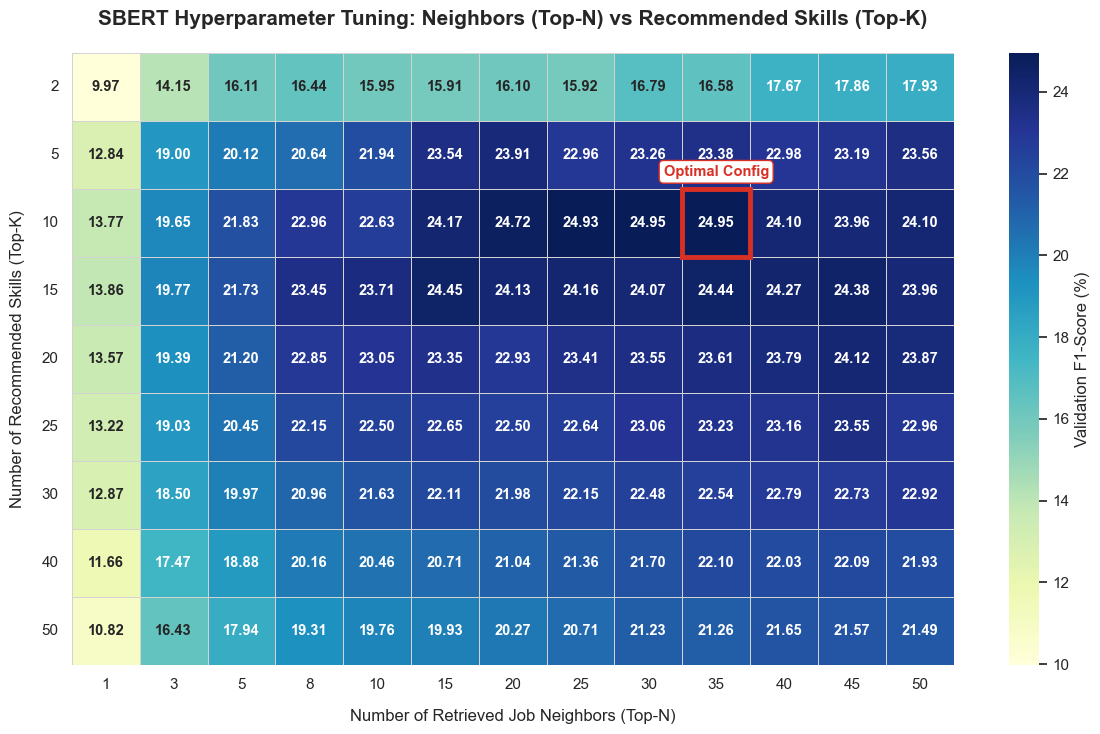

In [ ]:
heatmap_data = tuning_df.pivot(index='top_k', columns='top_n', values='F1')
heatmap_data = heatmap_data.sort_index(ascending=True)

sns.set_theme(style="white")
plt.figure(figsize=(12, 7.5))

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Validation F1-Score (%)'},
    linewidths=0.5,
    linecolor='lightgray',
    annot_kws={'size': 10.5, 'weight': 'bold'}
)

max_val = heatmap_data.values.max()
max_loc = np.argwhere(heatmap_data.values == max_val)[0]
best_row_idx = max_loc[0]
best_col_idx = max_loc[1]

ax.add_patch(
    Rectangle(
        (best_col_idx, best_row_idx),
        1,
        1,
        fill=False,
        edgecolor='#d93025',
        lw=3.5,
        zorder=10
    )
)

ax.text(
    best_col_idx + 0.5,
    best_row_idx - 0.25 if best_row_idx > 0 else best_row_idx + 1.25,
    "Optimal Config",
    color='#d93025',
    weight='bold',
    fontsize=10.5,
    ha='center',
    va='center',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d93025", lw=1)
)

plt.title('SBERT Hyperparameter Tuning: Neighbors (Top-N) vs Recommended Skills (Top-K)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Number of Retrieved Job Neighbors (Top-N)', fontsize=12, labelpad=12)
plt.ylabel('Number of Recommended Skills (Top-K)', fontsize=12, labelpad=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
if 'r_precision_at_k' not in globals():
    def r_precision_at_k(y_true, y_pred, k=10):
        rps = []
        for act, pred in zip(y_true, y_pred):
            act_set = set(act)
            if len(act_set) == 0:
                continue
            s = min(k, len(act_set))
            pred_s = pred[:s]
            hits = len(set(pred_s) & act_set)
            rps.append(hits / s if s > 0 else 0)
        return np.mean(rps)

if 'map_at_k' not in globals():
    def map_at_k(y_true, y_pred, k=10):
        ap_scores = []
        for t, p in zip(y_true, y_pred):
            if len(t) == 0: continue
            t_set = set(t)
            p_k = p[:k]
            ap = 0.0
            hits = 0
            for idx, item in enumerate(p_k):
                if item in t_set:
                    hits += 1
                    ap += hits / (idx + 1)
            ap_scores.append(ap / min(len(t_set), k) if min(len(t_set), k) > 0 else 0)
        return np.mean(ap_scores) * 100

process = psutil.Process()
start_time_sbert = time.time()
start_ram_sbert = process.memory_info().rss / (1024 * 1024)

final_sbert_col = 'cleaned_title_sbert'
final_sbert_k = 35
final_sbert_top_k = 10

print(f"Starting Final Evaluation for SBERT (E5) on Test Set...")
print(f"Using Config: Column='{final_sbert_col}', Neighbors_N={final_sbert_k}, Skills_K={final_sbert_top_k}")

y_true_sbert = test_df['skills_required'].tolist()
y_pred_sbert = []

for i in range(len(test_df)):
    query_emb = test_embs_dict[final_sbert_col][i]
    cos_scores = util.cos_sim(query_emb, train_embs_dict[final_sbert_col])[0]
    top_indices = torch.topk(cos_scores, k=final_sbert_k).indices.cpu().numpy()
    retrieved_skills = [s for slist in train_df.iloc[top_indices]['skills_required'] for s in slist]
    top_skills = [s for s, _ in Counter(retrieved_skills).most_common(final_sbert_top_k)]
    y_pred_sbert.append(top_skills)

f1_sbert        = f1_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)
precision_sbert = precision_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)
recall_sbert    = recall_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)
ndcg_sbert      = ndcg_at_k(y_true_sbert, y_pred_sbert, k=final_sbert_top_k)
map_10_sbert    = map_at_k(y_true_sbert, y_pred_sbert, k=10)
rp_10_sbert     = r_precision_at_k(y_true_sbert, y_pred_sbert, k=10)

all_skills_sbert = list(set([s for sub in y_true_sbert for s in sub] + [s for sub in y_pred_sbert for s in sub]))
mlb_sbert = MultiLabelBinarizer(classes=all_skills_sbert).fit(all_skills_sbert)
end_time_sbert = time.time()
end_ram_sbert = process.memory_info().rss / (1024 * 1024)
duration_sbert = end_time_sbert - start_time_sbert
ram_usage_sbert = end_ram_sbert - start_ram_sbert

eval_results_sbert = {
    f'F1@{final_sbert_top_k}': f1_sbert,
    f'Precision@{final_sbert_top_k}': precision_sbert,
    f'Recall@{final_sbert_top_k}': recall_sbert,
    'MAP@10': map_10_sbert,
    'RP@10': rp_10_sbert,
    f'NDCG@{final_sbert_top_k}': ndcg_sbert,
    'Inference Time(s)': duration_sbert,
}

print(f"\n{'='*40}")
print(f"   FINAL SBERT BASELINE PERFORMANCE (@{final_sbert_top_k})")
print(f"{'='*40}")
for metric, value in eval_results_sbert.items():
    unit = "%" if "@" in metric or "MRR" in metric or "Hit" in metric or "MAP" in metric or "RP" in metric else ""
    print(f"{metric:18} : {value:.4f}{unit}")
print(f"{'='*40}")

Starting Final Evaluation for SBERT (E5) on Test Set...
Using Config: Column='cleaned_title_sbert', Neighbors_N=35, Skills_K=10

   FINAL SBERT BASELINE PERFORMANCE (@10)
F1@10              : 22.9455%
Precision@10       : 32.0690%
Recall@10          : 31.9606%
MAP@10             : 36.0299%
RP@10              : 40.1317%
NDCG@10            : 46.8361%
Inference Time(s)  : 0.0750


In [ ]:
save_dir = "saved_models"
sbert_param_path = os.path.join(save_dir, "sbert_baseline_best_params.joblib")

if os.path.exists(sbert_param_path):
    sbert_params = joblib.load(sbert_param_path)
    final_sbert_col = sbert_params.get("best_config", {}).get("column", "cleaned_title_sbert")
    final_sbert_k = sbert_params.get("best_top_n", 35)
    final_sbert_top_k = sbert_params.get("best_top_k", 10)
else:
    final_sbert_col = 'cleaned_title_sbert'
    final_sbert_k = 35
    final_sbert_top_k = 10

print(f"Starting Final Evaluation for SBERT (E5) on Test Set...")
print(f"Using Config: Column='{final_sbert_col}', Neighbors_N={final_sbert_k}, Skills_K={final_sbert_top_k}")

Starting Final Evaluation for SBERT (E5) on Test Set...
Using Config: Column='cleaned_title_sbert', Neighbors_N=35, Skills_K=10


## 12. SBERT Ensemble

In [ ]:
def calculate_relevance(true_skills, pred_skills):
    if not true_skills or not pred_skills:
        return 0.0
    set_true = set(true_skills)
    set_pred = set(pred_skills)
    intersection = len(set_true.intersection(set_pred))
    union = len(set_true.union(set_pred))
    return intersection / union if union > 0 else 0.0


Total unique skills in train: 501
Using: N=35, Pool=200, Col='cleaned_title_sbert'
Will tune K (recommend count) separately in Step 2.

Val feature shape: (18491, 14)
Avg candidates per val query: 159.4  (should be ~200)

STEP 1: N_neg Sweep  [pool=200, eval@K=20]
 N_neg |   MAP@10 |    RP@10 |    F1@20 | Time
   400 |   34.48% |   46.81% |   23.46% | 8s
   500 |   35.89% |   45.55% |   23.81% | 4s
   600 |   35.89% |   45.55% |   23.81% | 5s
   700 |   35.89% |   45.55% |   23.81% | 5s
   800 |   35.89% |   45.55% |   23.81% | 6s
   900 |   35.89% |   45.55% |   23.81% | 5s
  1000 |   35.89% |   45.55% |   23.81% | 5s
  1200 |   35.89% |   45.55% |   23.81% | 4s
  Best N_neg = 500  (Val F1@20 = 23.81%)


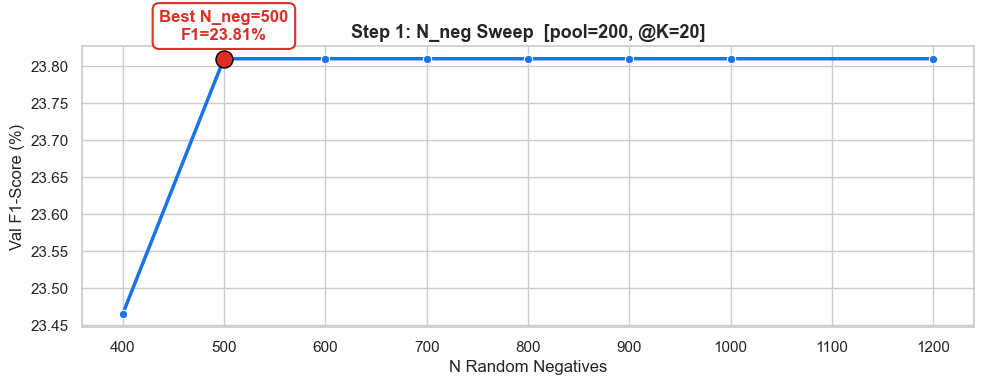


STEP 2: XGBoost Grid Search + K Tuning  [N_neg=500, pool=200]
XGB combos: 144  x  K values: [10, 20, 30, 40, 50]
  Best: n_est=200, depth=2, lr=0.05, K=10  →  Val F1=25.00%


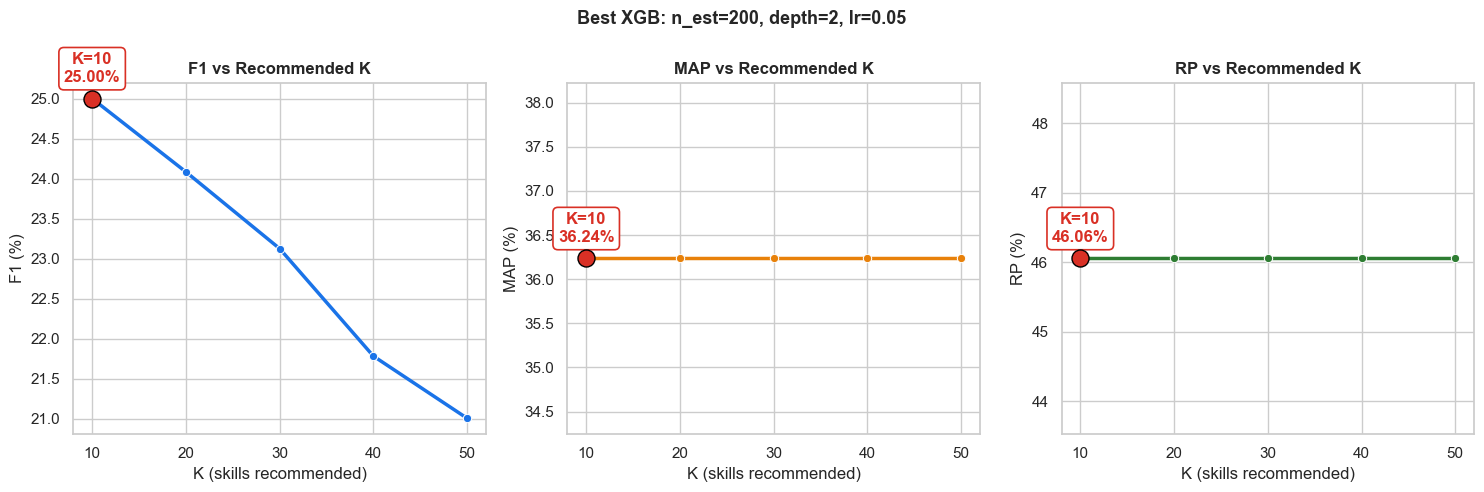

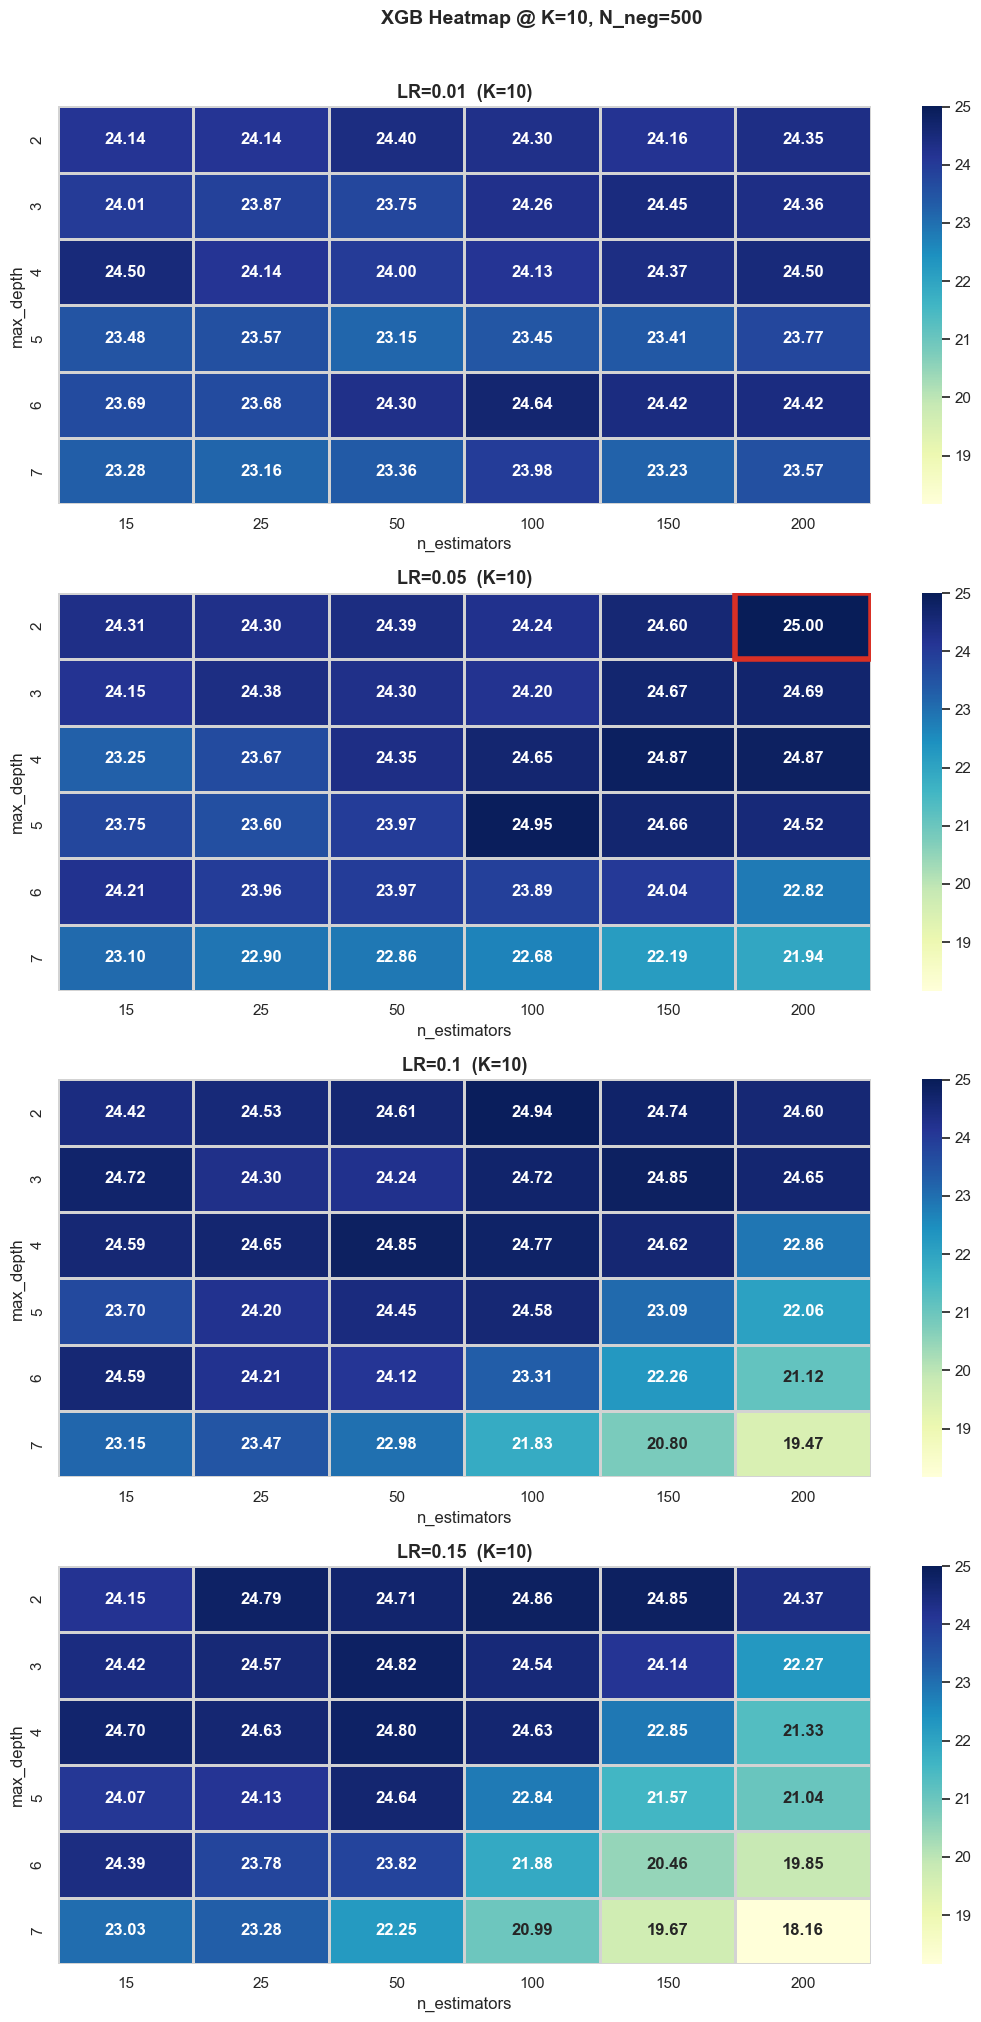


Saved! Final config: N=35, Pool=200, K=10, N_neg=500, n_est=200, depth=2, lr=0.05
X_train: (87038, 14), X_test: (18101, 14)
Avg candidates per test query: 156.0  (should be ~200)


In [ ]:
def calculate_relevance(true_skills, pred_skills):
    if not true_skills or not pred_skills: return 0.0
    s1, s2 = set(true_skills), set(pred_skills)
    return len(s1 & s2) / len(s1 | s2)

all_train_skills_flat = [s for slist in train_df['skills_required'] for s in slist]
skill_freq_map    = Counter(all_train_skills_flat)
all_skills_unique = list(set(skill_freq_map.keys()))
print(f"Total unique skills in train: {len(all_skills_unique)}")

def prepare_skill_level_sbert_features(query_df, query_embs, train_embs,is_train=True, num_candidates_n=35, num_skills_k=100,n_rand_neg=500, mask_self=True):
    X, y, g, cands_list, real_tp_list = [], [], [], [], []
    sim_matrix = util.cos_sim(query_embs, train_embs).cpu().numpy()
    for i, (q_idx, row) in enumerate(query_df.iterrows()):
        rel = set(row['skills_required'])
        if not rel: continue
        tq  = str(row.get('cleaned_title', row.get('vacancy_job_title',''))).lower().split()
        if not tq: continue
        scores = sim_matrix[i].copy()
        if mask_self and i < len(train_df):
            scores[i] = -1.0
        top_idx = np.argsort(scores)[::-1][:num_candidates_n]
        cooc, ss, sr = Counter(), {}, {}
        for rp, nidx in enumerate(top_idx):
            ns = scores[nidx]
            for s in train_df.iloc[nidx]['skills_required']:
                cooc[s] += 1
                if s not in ss or ns > ss[s]:
                    ss[s] = ns; sr[s] = rp
        cands = [s for s, _ in cooc.most_common(num_skills_k)]
        if is_train:
            for s in rel:
                if s not in cands: cands.append(s)
            out = [s for s in all_skills_unique if s not in set(cands) and s not in rel]
            if len(out) >= n_rand_neg:
                cands.extend(random.sample(out, n_rand_neg))
        if not cands: continue
        g.append(len(cands)); cands_list.append(cands); real_tp_list.append(len(rel))
        mx = max(ss.values()) if ss else 1.0
        ts = set(tq)
        for skill in cands:
            fsem = ss.get(skill, 0.0)
            sk   = set(str(skill).lower().split())
            uni  = ts | sk
            X.append([
                fsem,
                fsem / mx if mx > 0 else 0.,
                sr.get(skill, num_candidates_n + 1),
                cooc.get(skill, 0),
                cooc.get(skill, 0) / num_candidates_n,
                1 if skill.lower() in str(row.get('vacancy_job_title','')).lower() else 0,
                len(ts & sk) / len(uni) if uni else 0.,
                len(ts & sk),
                skill_freq_map.get(skill, 0),
                math.log1p(skill_freq_map.get(skill, 0)),
                len(str(skill).split()),
                1 if cooc.get(skill, 0) / num_candidates_n > 0.5 else 0,
                fsem * (cooc.get(skill, 0) / num_candidates_n),
                1 if skill_freq_map.get(skill, 0) > np.median(list(skill_freq_map.values())) else 0,
            ])
            y.append(1 if skill in rel else 0)

    return np.array(X), np.array(y), g, cands_list, real_tp_list

def eval_on_val(model, Xva, gva, va_cands, eval_k):
    preds = model.predict(Xva)
    y_true_val = val_df['skills_required'].tolist()
    y_pred_val = []
    ptr = 0
    for i, gs in enumerate(gva):
        qp    = preds[ptr:ptr+gs]
        cands = va_cands[i]
        top_i = np.argsort(qp)[::-1][:eval_k]
        y_pred_val.append([cands[j] for j in top_i])
        ptr += gs

    f1 = f1_at_k(y_true_val, y_pred_val, k=eval_k)
    if f1 <= 1.0: f1 *= 100

    aps, rps = [], []
    for tl, pl in zip(y_true_val, y_pred_val):
        ts = set(tl)
        if not ts: continue
        ap, hits = 0., 0
        for rk, p in enumerate(pl[:10]):
            if p in ts: hits += 1; ap += hits / (rk + 1)
        aps.append(ap / min(len(ts), 10) if hits > 0 else 0.)
        rps.append(sum(1 for p in pl[:10] if p in ts) / min(len(ts), 10))

    return f1, np.mean(aps) * 100, np.mean(rps) * 100

best_sbert_col = 'cleaned_title_sbert'
train_embs_sbert_ensemble = train_embs_dict[best_sbert_col]
val_embs_sbert_ensemble   = val_embs_dict[best_sbert_col]
test_embs_sbert_ensemble  = test_embs_dict[best_sbert_col]

_n        = 35
_POOL     = 200
print(f"Using: N={_n}, Pool={_POOL}, Col='{best_sbert_col}'")
print(f"Will tune K (recommend count) separately in Step 2.\n")

Xva_fixed, _, gva_fixed, va_cands_fixed, _ = prepare_skill_level_sbert_features(
    val_df, val_embs_sbert_ensemble, train_embs_sbert_ensemble,
    is_train=False, num_candidates_n=_n, num_skills_k=_POOL, mask_self=False
)
print(f"Val feature shape: {Xva_fixed.shape}")
print(f"Avg candidates per val query: {np.mean(gva_fixed):.1f}  (should be ~{_POOL})\n")

EVAL_K_REF = 20

print(f"{'='*65}")
print(f"STEP 1: N_neg Sweep  [pool={_POOL}, eval@K={EVAL_K_REF}]")
print(f"{'='*65}")
print(f"{'N_neg':>6} | {'MAP@10':>8} | {'RP@10':>8} | {'F1@'+str(EVAL_K_REF):>8} | Time")
print(f"{'='*65}")

sweep_values  = [400, 500, 600, 700, 800, 900, 1000, 1200]
sweep_results = []
best_neg_f1, best_n_neg = 0., 400

for n_neg in sweep_values:
    t0 = time.time()
    Xtr, ytr, gtr, _, _ = prepare_skill_level_sbert_features(
        train_df, train_embs_sbert_ensemble, train_embs_sbert_ensemble,
        is_train=True, num_candidates_n=_n, num_skills_k=_POOL,
        n_rand_neg=n_neg, mask_self=True
    )
    mdl = xgb.XGBRanker(
        tree_method="hist", objective="rank:ndcg",
        random_state=42, n_jobs=-1,
        n_estimators=50, learning_rate=0.03,
        max_depth=3, min_child_weight=5
    )
    mdl.fit(Xtr, ytr, group=gtr)
    f1_, map_, rp_ = eval_on_val(mdl, Xva_fixed, gva_fixed, va_cands_fixed, EVAL_K_REF)
    elapsed = time.time() - t0

    sweep_results.append({'N_neg': n_neg, 'MAP@10': map_, 'RP@10': rp_, 'F1': f1_})
    print(f"{n_neg:>6} | {map_:>7.2f}% | {rp_:>7.2f}% | {f1_:>7.2f}% | {elapsed:.0f}s")
    if f1_ > best_neg_f1:
        best_neg_f1, best_n_neg = f1_, n_neg

print(f"{'='*65}")
print(f"  Best N_neg = {best_n_neg}  (Val F1@{EVAL_K_REF} = {best_neg_f1:.2f}%)")

sweep_df = pd.DataFrame(sweep_results)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4))
sns.lineplot(data=sweep_df, x='N_neg', y='F1', marker='o', linewidth=2.5, color='#1a73e8')
best_pt = sweep_df.loc[sweep_df['F1'].idxmax()]
plt.scatter(best_pt['N_neg'], best_pt['F1'], color='#d93025', s=150, zorder=5, edgecolor='black')
plt.annotate(f"Best N_neg={int(best_pt['N_neg'])}\nF1={best_pt['F1']:.2f}%",
             (best_pt['N_neg'], best_pt['F1']), textcoords="offset points",
             xytext=(0, 14), ha='center', color='#d93025', weight='bold',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5))
plt.title(f'Step 1: N_neg Sweep  [pool={_POOL}, @K={EVAL_K_REF}]', fontsize=13, fontweight='bold')
plt.xlabel('N Random Negatives'); plt.ylabel('Val F1-Score (%)')
plt.tight_layout(); plt.show()

n_estimators_space  = [15, 25, 50, 100, 150, 200]
max_depth_space     = [2, 3, 4, 5, 6, 7]
learning_rate_space = [0.01, 0.05, 0.1, 0.15]
skill_k_space       = [10, 20, 30, 40, 50]

xgb_grid = [
    {'n_estimators': n, 'max_depth': d, 'lr': lr}
    for n, d, lr in itertools.product(n_estimators_space, max_depth_space, learning_rate_space)
]
print(f"\n{'='*70}")
print(f"STEP 2: XGBoost Grid Search + K Tuning  [N_neg={best_n_neg}, pool={_POOL}]")
print(f"XGB combos: {len(xgb_grid)}  x  K values: {skill_k_space}")
print(f"{'='*70}")

# Re-extract train with best N_neg
Xtr_best, ytr_best, gtr_best, _, _ = prepare_skill_level_sbert_features(
    train_df, train_embs_sbert_ensemble, train_embs_sbert_ensemble,
    is_train=True, num_candidates_n=_n, num_skills_k=_POOL,
    n_rand_neg=best_n_neg, mask_self=True
)

best_xgb_f1, best_xgb_params, best_xgb_model, best_ensemble_k = 0., {}, None, 10
xgb_grid_results = []

for params in xgb_grid:
    mdl = xgb.XGBRanker(
        tree_method="hist", objective="rank:ndcg",
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['lr'],
        random_state=42, n_jobs=6, min_child_weight=5
    )
    mdl.fit(Xtr_best, ytr_best, group=gtr_best)

    for sk in skill_k_space:
        f1_, map_, rp_ = eval_on_val(mdl, Xva_fixed, gva_fixed, va_cands_fixed, sk)
        xgb_grid_results.append({
            'n_estimators': params['n_estimators'], 'max_depth': params['max_depth'],
            'learning_rate': params['lr'], 'skill_k': sk,
            'F1': f1_, 'MAP': map_, 'RP': rp_
        })
        if f1_ > best_xgb_f1:
            best_xgb_f1 = f1_; best_xgb_params = params
            best_xgb_model = mdl; best_ensemble_k = sk

print(f"  Best: n_est={best_xgb_params['n_estimators']}, depth={best_xgb_params['max_depth']}, "
      f"lr={best_xgb_params['lr']}, K={best_ensemble_k}  →  Val F1={best_xgb_f1:.2f}%")

# Plot F1/MAP/RP vs K for best XGB config
grid_df   = pd.DataFrame(xgb_grid_results)
best_mask = ((grid_df['n_estimators']  == best_xgb_params['n_estimators']) &
             (grid_df['max_depth']     == best_xgb_params['max_depth'])     &
             (grid_df['learning_rate'] == best_xgb_params['lr']))
plot_df   = grid_df[best_mask].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, color, col in zip(axes,
    ['F1','MAP','RP'], ['#1a73e8','#e8810a','#2e7d32'],
    ['F1','MAP','RP']):
    sns.lineplot(data=plot_df, x='skill_k', y=col, marker='o', linewidth=2.5, color=color, ax=ax)
    best_row = plot_df.loc[plot_df[col].idxmax()]
    ax.scatter(best_row['skill_k'], best_row[col], color='#d93025', s=150, zorder=5, edgecolor='black')
    ax.annotate(f"K={int(best_row['skill_k'])}\n{best_row[col]:.2f}%",
                (best_row['skill_k'], best_row[col]), textcoords="offset points",
                xytext=(0, 12), ha='center', color='#d93025', weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d93025", lw=1.2))
    ax.set_title(f'{metric} vs Recommended K', fontweight='bold')
    ax.set_xlabel('K (skills recommended)'); ax.set_ylabel(f'{metric} (%)')
plt.suptitle(f'Best XGB: n_est={best_xgb_params["n_estimators"]}, '
             f'depth={best_xgb_params["max_depth"]}, lr={best_xgb_params["lr"]}',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Heatmap at best K
best_k_df = grid_df[grid_df['skill_k'] == best_ensemble_k].copy()
vmin, vmax = best_k_df['F1'].min(), best_k_df['F1'].max()
fig, axes = plt.subplots(nrows=len(learning_rate_space), ncols=1,
                          figsize=(11, 5 * len(learning_rate_space)))
if len(learning_rate_space) == 1: axes = [axes]
for ax, lr in zip(axes, learning_rate_space):
    lr_df    = best_k_df[best_k_df['learning_rate'] == lr]
    pivot_df = lr_df.pivot(index='max_depth', columns='n_estimators', values='F1').sort_index()
    sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=vmin, vmax=vmax,
                linewidths=0.8, linecolor='lightgray', annot_kws={'size':12,'weight':'bold'}, ax=ax)
    ax.set_title(f"LR={lr}  (K={best_ensemble_k})", fontsize=13, fontweight='bold')
    if lr == best_xgb_params['lr']:
        ri = list(pivot_df.index).index(best_xgb_params['max_depth'])
        ci = list(pivot_df.columns).index(best_xgb_params['n_estimators'])
        ax.add_patch(Rectangle((ci, ri), 1, 1, fill=False, edgecolor='#d93025', lw=4., zorder=10))
plt.suptitle(f'XGB Heatmap @ K={best_ensemble_k}, N_neg={best_n_neg}',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

# Save
xgb_sbert_ensemble = best_xgb_model
_k_final           = best_ensemble_k
joblib.dump(xgb_sbert_ensemble, "sbert_xgb_ranker_best.joblib")
print(f"\nSaved! Final config: N={_n}, Pool={_POOL}, K={_k_final}, "
      f"N_neg={best_n_neg}, n_est={best_xgb_params['n_estimators']}, "
      f"depth={best_xgb_params['max_depth']}, lr={best_xgb_params['lr']}")

# Cell B — Re-extract with best params
X_train_sbe, y_train_sbe, g_train_sbe, _, _ = prepare_skill_level_sbert_features(
    train_df, train_embs_sbert_ensemble, train_embs_sbert_ensemble,
    is_train=True, num_candidates_n=_n, num_skills_k=_POOL,
    n_rand_neg=best_n_neg, mask_self=True
)
X_test_sbe, y_test_sbe, g_test_sbe, test_cands_list, _ = prepare_skill_level_sbert_features(
    test_df, test_embs_sbert_ensemble, train_embs_sbert_ensemble,
    is_train=False, num_candidates_n=_n, num_skills_k=_POOL, mask_self=False
)
print(f"X_train: {X_train_sbe.shape}, X_test: {X_test_sbe.shape}")
print(f"Avg candidates per test query: {np.mean(g_test_sbe):.1f}  (should be ~{_POOL})")

In [ ]:
def calculate_map_at_10(y_true, y_pred):
    aps = []
    for true_list, pred_list in zip(y_true, y_pred):
        true_set = set(true_list)
        if not true_set: continue
        ap, hits = 0.0, 0
        for rank, p in enumerate(pred_list[:10]):
            if p in true_set:
                hits += 1
                ap += hits / (rank + 1)
        aps.append(ap / min(len(true_set), 10) if hits > 0 else 0.0)
    return np.mean(aps) * 100

def calculate_rp_at_10(y_true, y_pred):
    rps = []
    for true_list, pred_list in zip(y_true, y_pred):
        true_set = set(true_list)
        if not true_set: continue
        hits = sum(1 for p in pred_list[:10] if p in true_set)
        rps.append(hits / min(len(true_set), 10))
    return np.mean(rps) * 100

process = psutil.Process()
t0   = time.time()
ram0 = process.memory_info().rss / (1024 * 1024)
preds_test = xgb_sbert_ensemble.predict(X_test_sbe)

y_true_final   = test_df['skills_required'].tolist()
y_pred_final   = []
y_pred_final_10 = []
ptr = 0
for i, gs in enumerate(g_test_sbe):
    qp    = preds_test[ptr:ptr+gs]
    cands = test_cands_list[i]
    y_pred_final.append([cands[j] for j in np.argsort(qp)[::-1][:_k_final]])
    y_pred_final_10.append([cands[j] for j in np.argsort(qp)[::-1][:10]])
    ptr += gs

t1   = time.time()
ram1 = process.memory_info().rss / (1024 * 1024)
f1_ens        = f1_at_k(y_true_final, y_pred_final, k=_k_final)
precision_ens = precision_at_k(y_true_final, y_pred_final, k=_k_final)
recall_ens    = recall_at_k(y_true_final, y_pred_final, k=_k_final)
ndcg_ens      = ndcg_at_k(y_true_final, y_pred_final, k=_k_final)
map10_ens     = calculate_map_at_10(y_true_final, y_pred_final_10)
rp10_ens      = calculate_rp_at_10(y_true_final, y_pred_final_10)

if f1_ens  <= 1.0: f1_ens  *= 100

y_pred_trunc = [p[:_k_final] for p in y_pred_final]
all_sk       = list(set([s for sub in y_true_final for s in sub] + [s for sub in y_pred_trunc  for s in sub]))
mlb_ens      = MultiLabelBinarizer(classes=all_sk).fit(all_sk)

eval_results_sbert_ensemble = {
    f'F1@{_k_final}':          f1_ens,
    f'Precision@{_k_final}':   precision_ens,
    f'Recall@{_k_final}':      recall_ens,
    f'NDCG@{_k_final}':        ndcg_ens,
    'MAP@10':                  map10_ens,
    'RP@10':                   rp10_ens,
    'Inference Time(s)':       t1 - t0
}

print(f"\n{'='*50}")
print(f"   FINAL SBERT ENSEMBLE PERFORMANCE (@{_k_final})")
print(f"   Col : '{best_sbert_col}'")
print(f"   N   : {_n}  |  Pool : {_POOL}  |  K : {_k_final}")
print(f"   N_neg={best_n_neg}, n_est={best_xgb_params['n_estimators']}, "
      f"depth={best_xgb_params['max_depth']}, lr={best_xgb_params['lr']}")
print(f"{'='*50}")
for metric, value in eval_results_sbert_ensemble.items():
    unit = "%" if any(x in metric for x in ["@", "MRR", "Hit"]) else ""
    print(f"{metric:22} : {value:.4f}{unit}")
print(f"{'='*50}")


   FINAL SBERT ENSEMBLE PERFORMANCE (@10)
   Col : 'cleaned_title_sbert'
   N   : 35  |  Pool : 200  |  K : 10
   N_neg=500, n_est=200, depth=2, lr=0.05
F1@10                  : 22.6942%
Precision@10           : 31.8103%
Recall@10              : 31.8731%
NDCG@10                : 47.1588%
MAP@10                 : 36.5991%
RP@10                  : 47.2821%
Inference Time(s)      : 0.0124


In [ ]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)
best_xgb_params['max_depth'] = 4
sbert_ensemble_best_params = {
    "best_config": {
        "column": best_sbert_col          # 'cleaned_title_sbert'
    },
    "best_top_n":   _n,                    # 35  (job neighbors N)
    "best_pool":    _POOL,                 # 500 (candidate skill pool size)
    "best_top_k":   _k_final,              # 10  (recommended skills K)
    "best_n_neg":   best_n_neg,            # 500 (random negative samples)
    "best_xgb_params": best_xgb_params
}

ensemble_param_path = os.path.join(save_dir, "sbert_ensemble_best_params.joblib")
joblib.dump(sbert_ensemble_best_params, ensemble_param_path)
ensemble_model_path = os.path.join(save_dir, "sbert_xgb_ranker_best.joblib")
joblib.dump(xgb_sbert_ensemble, ensemble_model_path)

print(f"Parameter Saved: {ensemble_param_path}")
print(f"Model Saved: {ensemble_model_path}")
print("\nContent Preview:")
for k, v in sbert_ensemble_best_params.items():
    print(f"   {k}: {v}")

Parameter Saved: saved_models\sbert_ensemble_best_params.joblib
Model Saved: saved_models\sbert_xgb_ranker_best.joblib

Content Preview:
   best_config: {'column': 'cleaned_title_sbert'}
   best_top_n: 35
   best_pool: 200
   best_top_k: 10
   best_n_neg: 500
   best_xgb_params: {'n_estimators': 200, 'max_depth': 4, 'lr': 0.05}


In [ ]:
optimal_ranker = xgb.XGBRanker(
    objective="rank:ndcg",
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=5,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

print("Fitting model with new robust params...")
optimal_ranker.fit(X_train_sbe, y_train_sbe, group=g_train_sbe)

joblib.dump(optimal_ranker, "saved_models/sbert_xgb_ranker_best.joblib")
print("Successfully saved the regularized model to disk!")

Fitting model with new robust params...
Successfully saved the regularized model to disk!


## 13. BPR Baseline

In [ ]:
print("Building ID mappings...")
all_skills_list = list(set([s for slist in pd.concat([train_df, val_df, test_df])['skills_required'] for s in slist]))
skill_to_id = {skill: i for i, skill in enumerate(all_skills_list)}
id_to_skill = {i: skill for skill, i in skill_to_id.items()}

Building ID mappings...


In [ ]:
all_train_job_ids = train_df['vacancy_job_title'].unique()
job_to_idx = {jid: i for i, jid in enumerate(all_train_job_ids)}

In [ ]:
rows, cols, data = [], [], []
for j, (i, row) in enumerate(train_df.iterrows()):
    j_idx = job_to_idx[row['vacancy_job_title']]
    for s in row['skills_required']:
        if s in skill_to_id:
            rows.append(j_idx)
            cols.append(skill_to_id[s])
            data.append(1)
train_matrix_bpr = csr_matrix((data, (rows, cols)), shape=(len(all_train_job_ids), len(all_skills_list)))
print(f"Matrix Built! Shape: {train_matrix_bpr.shape}")

Matrix Built! Shape: (539, 501)


Starting Joint BPR Tuning (Input Fields + BPR Factors + Neighbors N + Recommended Skills K)...
New Record! Col: cleaned_title   | Factors:   4 | Neighbors N:  5 | Skills K:  2 | Val F1: 5.69%
New Record! Col: cleaned_title   | Factors:   4 | Neighbors N:  5 | Skills K:  5 | Val F1: 9.34%
New Record! Col: cleaned_title   | Factors:   4 | Neighbors N:  5 | Skills K: 10 | Val F1: 13.02%
New Record! Col: cleaned_title   | Factors:   4 | Neighbors N:  5 | Skills K: 20 | Val F1: 18.21%
New Record! Col: cleaned_title   | Factors:   4 | Neighbors N:  5 | Skills K: 30 | Val F1: 19.13%
New Record! Col: cleaned_title   | Factors:   4 | Neighbors N:  5 | Skills K: 40 | Val F1: 19.14%
New Record! Col: cleaned_title   | Factors:   4 | Neighbors N: 15 | Skills K: 20 | Val F1: 20.78%
New Record! Col: cleaned_title   | Factors:   8 | Neighbors N: 10 | Skills K:  5 | Val F1: 21.02%
New Record! Col: cleaned_title   | Factors:   8 | Neighbors N: 10 | Skills K: 10 | Val F1: 21.17%
New Record! Col: cleaned_

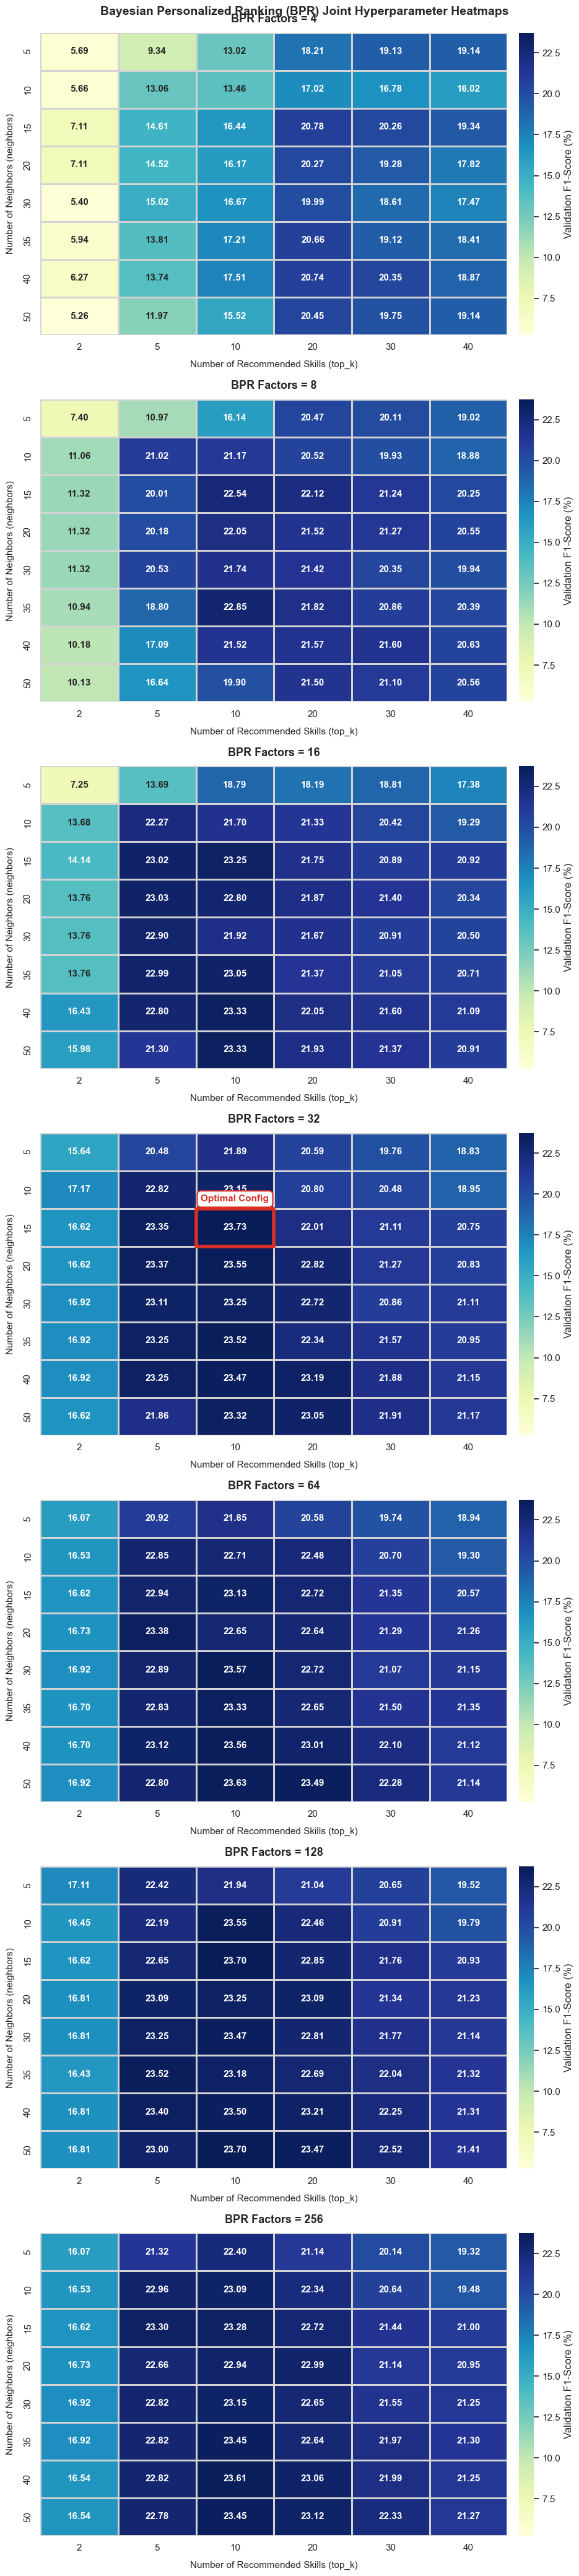

In [ ]:
train_df_unique = train_df.drop_duplicates(subset='vacancy_job_title')

columns_to_test = ['cleaned_title']
factors_space = [4, 8, 16, 32, 64, 128, 256]
neighbor_space = [5, 10, 15, 20, 30, 35, 40, 50]
skill_k_space = [2, 5, 10, 20, 30, 40]
iters = 1500

best_total_f1 = -1
best_config = {}
bpr_tuning_results = []

max_n = max(neighbor_space)
max_k = max(skill_k_space)

print("Starting Joint BPR Tuning (Input Fields + BPR Factors + Neighbors N + Recommended Skills K)...")

for factors in factors_space:
    model = implicit.bpr.BayesianPersonalizedRanking(factors=factors, iterations=iters, random_state=42)
    model.fit(train_matrix_bpr, show_progress=False)
    for col in columns_to_test:
        tfidf_vec = TfidfVectorizer(max_features=3000)
        train_tfidf = tfidf_vec.fit_transform(train_df_unique[col].fillna(''))
        val_tfidf = tfidf_vec.transform(val_df[col].fillna(''))
        sim_matrix = cosine_similarity(val_tfidf, train_tfidf)
        predictions_dict = { (n, k): [] for n in neighbor_space for k in skill_k_space }
        y_true_val = val_df['skills_required'].tolist()
        for i in range(len(val_df)):
            top_indices_max = np.argsort(sim_matrix[i])[::-1][:max_n]
            for n_neighbors in neighbor_space:
                neighbor_indices = top_indices_max[:n_neighbors]
                avg_factor = np.mean(model.user_factors[neighbor_indices], axis=0)
                scores = avg_factor.dot(model.item_factors.T)
                ids = np.argsort(scores)[::-1][:max_k]
                most_common_skills = [id_to_skill[idx] for idx in ids]
                for k in skill_k_space:
                    predictions_dict[(n_neighbors, k)].append(most_common_skills[:k])
        for n_neighbors in neighbor_space:
            for k in skill_k_space:
                current_f1 = f1_at_k(y_true_val, predictions_dict[(n_neighbors, k)], k=k)
                bpr_tuning_results.append({'column': col,'factors': factors,'neighbors': n_neighbors,'skill_k': k,'F1': current_f1})
                if current_f1 > best_total_f1:
                    best_total_f1 = current_f1
                    best_config = {
                        'column': col,
                        'factors': factors,
                        'iters': iters,
                        'neighbors': n_neighbors,
                        'top_k': k
                    }
                    print(f"New Record! Col: {col:15} | Factors: {factors:3} | Neighbors N: {n_neighbors:2} | Skills K: {k:2} | Val F1: {current_f1:.2f}%")

print("\nBest BPR Hyperparameters Found overall:")
print("="*55)
print(f"   Best Input Column (column)      : {best_config['column']}")
print(f"   Best Latent Factors (factors)   : {best_config['factors']}")
print(f"   Best Neighbors Count (neighbors): {best_config['neighbors']}")
print(f"   Best Recommended Skills (top_k) : {best_config['top_k']}")
print(f"   Optimal Validation F1-Score     : {best_total_f1:.2f}%")
print("="*55 + "\n")

globals()['final_col'] = best_config['column']
globals()['final_factors'] = best_config['factors']
globals()['final_iters'] = best_config['iters']
globals()['final_neighbors'] = best_config['neighbors']
globals()['final_top_k'] = best_config['top_k']

bpr_tuning_df = pd.DataFrame(bpr_tuning_results)

sns.set_theme(style="white")
num_factors = len(factors_space)
fig, axes = plt.subplots(num_factors, 1, figsize=(10, 6 * num_factors)) # DYNAMIC: scale subplots dynamically

best_col = best_config['column']
best_factors = best_config['factors']
best_neighbors = best_config['neighbors']
best_k = best_config['top_k']

vmin = bpr_tuning_df['F1'].min()
vmax = bpr_tuning_df['F1'].max()

for i, factors in enumerate(factors_space):
    f_df = bpr_tuning_df[bpr_tuning_df['factors'] == factors]
    pivot_df = f_df.pivot(index='neighbors', columns='skill_k', values='F1')
    ax = axes[i] if num_factors > 1 else axes
    sns.heatmap(
        pivot_df,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        cbar_kws={'label': 'Validation F1-Score (%)', 'pad': 0.02},
        linewidths=0.8,
        linecolor='lightgray',
        annot_kws={'size': 11, 'weight': 'bold'},
        ax=ax
    )
    ax.set_title(f"BPR Factors = {factors}", fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel("Number of Recommended Skills (top_k)", fontsize=11, labelpad=10)
    ax.set_ylabel("Number of Neighbors (neighbors)", fontsize=11, labelpad=10)
    if factors == best_factors:
        row_idx = list(pivot_df.index).index(best_neighbors)
        col_idx = list(pivot_df.columns).index(best_k)

        ax.add_patch(
            Rectangle(
                (col_idx, row_idx),
                1,
                1,
                fill=False,
                edgecolor='#d93025',
                lw=4.0,
                zorder=10
            )
        )
        ax.text(
            col_idx + 0.5,
            row_idx - 0.25 if row_idx > 0 else row_idx + 1.25,
            "Optimal Config",
            color='#d93025',
            weight='bold',
            fontsize=11,
            ha='center',
            va='center',
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5)
        )

plt.suptitle('Bayesian Personalized Ranking (BPR) Joint Hyperparameter Heatmaps', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

In [ ]:
def format_bpr_val(row):
        return f"{row['Value']:.2f}%"

final_col = globals().get('final_col', 'cleaned_title')
final_factors = globals().get('final_factors', 32)
final_iters = globals().get('final_iters', 1500)
final_neighbors = globals().get('final_neighbors', 40) # Optimal neighbors count (N)
final_top_k = globals().get('final_top_k', 30)         # Optimal K (recommended skills)

train_df_unique = train_df.drop_duplicates(subset='vacancy_job_title')

final_tfidf_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=10000)
final_train_tfidf = final_tfidf_vec.fit_transform(train_df_unique[final_col].fillna(''))
final_test_tfidf = final_tfidf_vec.transform(test_df[final_col].fillna(''))

bpr_model_baseline = implicit.bpr.BayesianPersonalizedRanking(factors=final_factors, iterations=final_iters, random_state=42)
bpr_model_baseline.fit(train_matrix_bpr)

y_pred_bpr = []
y_pred_bpr_10 = []
y_true_bpr = test_df['skills_required'].tolist()
sim_matrix_test = cosine_similarity(final_test_tfidf, final_train_tfidf)

print(f"Final Evaluation on test_df using '{final_col}' (Factors={final_factors}, Neighbors={final_neighbors}, Skills K={final_top_k})...")

for i in range(len(test_df)):
    neighbors = np.argsort(sim_matrix_test[i])[::-1][:final_neighbors]
    avg_f = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)

    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    ids = np.argsort(scores)[::-1][:final_top_k]
    y_pred_bpr.append([id_to_skill[idx] for idx in ids])

    ids_10 = np.argsort(scores)[::-1][:10]
    y_pred_bpr_10.append([id_to_skill[idx] for idx in ids_10])

y_true_binary_test = mlb.transform(test_df['skills_required'])

eval_results_bpr_pure = {
    f'F1@{final_top_k}': f1_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'NDCG@{final_top_k}': ndcg_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'Precision@{final_top_k}': precision_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    f'Recall@{final_top_k}': recall_at_k(y_true_bpr, y_pred_bpr, k=final_top_k),
    'MAP@10': map_at_k(y_true_bpr, y_pred_bpr_10, k=10),
    'RP@10': r_precision_at_k(y_true_bpr, y_pred_bpr_10, k=10)
}

report_df_pure = pd.DataFrame(list(eval_results_bpr_pure.items()), columns=['Metric', 'Value'])
report_df_pure['Value'] = report_df_pure.apply(format_bpr_val, axis=1)

print("\n" + "="*45)
print(f"      FINAL PURE BPR REPORT (@K={final_top_k})")
print("="*45)
print(report_df_pure.to_string(index=False))
print("="*45)

100%|███████████████████████████████████████████| 1500/1500 [00:01<00:00, 782.66it/s, train_auc=99.85%, skipped=19.50%]

Final Evaluation on test_df using 'cleaned_title' (Factors=32, Neighbors=15, Skills K=10)...

      FINAL PURE BPR REPORT (@K=10)
      Metric  Value
       F1@10 21.26%
     NDCG@10 45.35%
Precision@10 30.69%
   Recall@10 28.60%
      MAP@10 34.72%
       RP@10 38.57%


In [ ]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

bpr_baseline_best_params = {
    "best_config": {
        "column": final_col,           # 'cleaned_title'
    },
    "best_factors":    final_factors,  # 128
    "best_iters":      final_iters,    # 1500
    "best_neighbors":  final_neighbors, # 35
    "best_top_k":      10,    # 10
}

joblib.dump(bpr_baseline_best_params, os.path.join(save_dir, "bpr_baseline_best_params.joblib"))
print("BPR Baseline best params saved!")
print(bpr_baseline_best_params)

BPR Baseline best params saved!
{'best_config': {'column': 'cleaned_title'}, 'best_factors': 32, 'best_iters': 1500, 'best_neighbors': 15, 'best_top_k': 10}


## 14. BPR Ensemble

Calculating Skill-Skill Co-occurrence...
Building Skill-Title Co-occurrence table...
Pre-computing static skill features to accelerate feature extraction...
Pre-computing Cosine Similarity matrices and regressor predictions...
Extracting features using optimal parameters (Neighbors=40, Neg Ratio=5x)...
Training LGBMRanker (rank_xendcg)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2052
[LightGBM] [Info] Number of data points in the train set: 63551, number of used features: 16
LGBMRanker Trained successfully!
Grid searching blend_weight and fusion_weight on validation set...
Optimal Weights Found: blend_weight=0.1, fusion_weight=0.5 (Val F1@40=22.10%)

Tuning Recommended Skills K for BPR+LGBM Ensemble on val_df...
Skills K:  5 | Val F1: 22.70%
Skills K: 10 | Val F1: 24.37%
Skills K: 20 | Val F1: 23.69%
Skills K: 25 | Val F1: 23.23%
Skills K

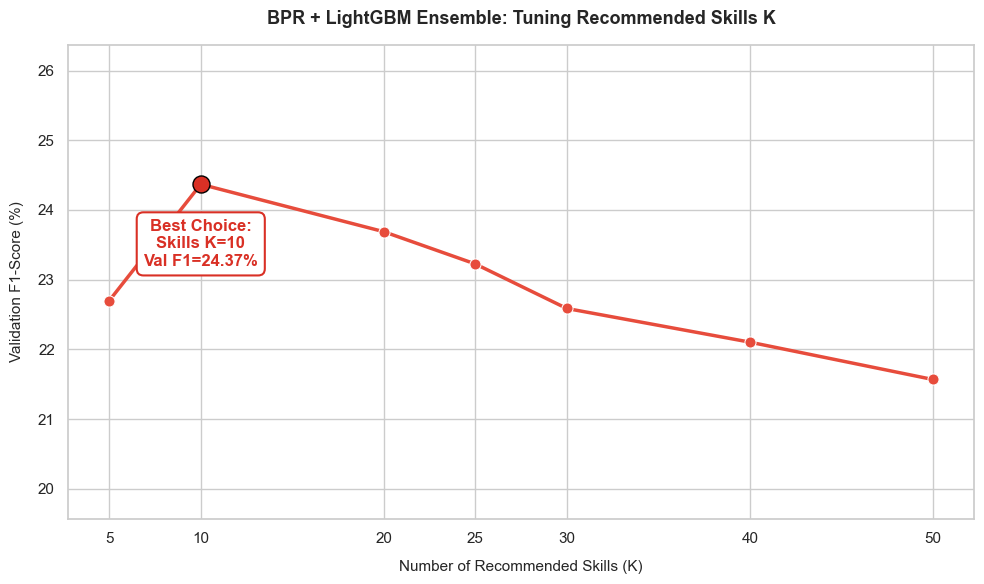

Starting Final Evaluation of BPR + LightGBM Ensemble (Skills K=10)...


100%|████████████████████████████████████████████████████████████████████████████████| 116/116 [00:48<00:00,  2.40it/s]


   PROPOSED BPR + LGBM ENSEMBLE REPORT (@K=10)
        Metric   Value
         F1@10  22.72%
       NDCG@10  46.79%
  Precision@10  31.90%
     Recall@10  31.91%
        MAP@10  35.42%
         RP@10  39.27%
      Time (s) 48.3862
RAM Usage (MB)  0.0273


In [ ]:
print("Calculating Skill-Skill Co-occurrence...")
cooc_matrix = train_matrix_bpr.T.dot(train_matrix_bpr)
cooc_matrix.data = np.log1p(cooc_matrix.data)
all_train_skills = [s for slist in train_df['skills_required'] for s in slist]
skill_counts = Counter(all_train_skills)
total_jobs = len(train_df_unique)

print("Building Skill-Title Co-occurrence table...")
skill_title_cooccur = defaultdict(Counter)
for _, row in train_df_unique.iterrows():
    title_words = set(clean_job_title(row[final_col]).split())
    for s in row['skills_required']:
        for w in title_words:
            skill_title_cooccur[s][w] += 1
skill_total_count = Counter([s for slist in train_df_unique['skills_required'] for s in slist])

skill_idf = {}
for skill, cnt in skill_counts.items():
    skill_idf[skill] = np.log(total_jobs / (1 + cnt))

print("Pre-computing static skill features to accelerate feature extraction...")
skill_pop_cache = {s_idx: skill_counts.get(s_name, 0) / total_jobs for s_idx, s_name in id_to_skill.items()}
skill_idf_cache = {s_idx: skill_idf.get(s_name, 0.0) for s_idx, s_name in id_to_skill.items()}

item_norms = np.linalg.norm(bpr_model_baseline.item_factors, axis=1)
item_norms[item_norms == 0] = 1.0  # Avoid division by zero

skill_words_cache = {s_idx: set(clean_job_title(s_name).split()) for s_idx, s_name in id_to_skill.items()}
skill_stems_cache = {s_idx: set(w[:5] for w in s_words) for s_idx, s_words in skill_words_cache.items()}

skill_total_count_cache = {s_idx: skill_total_count.get(s_name, 1) for s_idx, s_name in id_to_skill.items()}
skill_word_counts_cache = {s_idx: skill_title_cooccur.get(s_name, {}) for s_idx, s_name in id_to_skill.items()}
train_jobs_skills = [set(row['skills_required']) for _, row in train_df_unique.iterrows()]

def extract_hybrid_features(candidate_ids, bpr_scores, avg_user_factor,query_tokens, neighbor_skills_counts, n_neighbors, raw_query_text, neighbor_sims, neighbors,candidate_rank_lookup=None, cooc_candidates=None):
    feats = []
    ref_candidates = cooc_candidates if cooc_candidates is not None else candidate_ids
    top_30_ids = ref_candidates[:30]

    q_words = set(query_tokens)
    mean_score = np.mean(bpr_scores)
    std_score = np.std(bpr_scores) if np.std(bpr_scores) > 0 else 1.0
    user_norm = np.linalg.norm(avg_user_factor)
    user_norm = user_norm if user_norm > 0 else 1.0
    stemmed_q = set(w[:5] for w in q_words)

    lower_query = raw_query_text.lower()
    skill_weighted_knn = defaultdict(float)
    skill_max_knn = defaultdict(float)
    for sim, n_idx in zip(neighbor_sims, neighbors):
        n_skills = train_jobs_skills[n_idx]
        for s in n_skills:
            skill_weighted_knn[s] += sim
            if sim > skill_max_knn[s]:
                skill_max_knn[s] = sim

    for rank, s_idx in enumerate(candidate_ids):
        f_score = bpr_scores[s_idx]
        f_zscore = (f_score - mean_score) / std_score
        actual_rank = candidate_rank_lookup[s_idx] if (candidate_rank_lookup is not None and s_idx in candidate_rank_lookup) else rank
        f_rank = 1.0 / (actual_rank + 1)

        f_pop = skill_pop_cache[s_idx]
        f_skill_idf = skill_idf_cache[s_idx]

        others = [idx for idx in top_30_ids if idx != s_idx]
        coocs = [cooc_matrix[s_idx, o_idx] for o_idx in others] if others else []
        f_cooc_mean = np.mean(coocs) if coocs else 0.0
        f_cooc_max = np.max(coocs) if coocs else 0.0

        item_norm = item_norms[s_idx]
        f_cos = f_score / (user_norm * item_norm)
        f_item_norm = item_norm

        s_words = skill_words_cache[s_idx]
        f_jaccard = (
            len(q_words.intersection(s_words)) / len(q_words.union(s_words))
        ) if q_words.union(s_words) else 0.0

        stemmed_s = skill_stems_cache[s_idx]
        f_stem_overlap = (
            len(stemmed_q.intersection(stemmed_s)) / len(stemmed_q.union(stemmed_s))
        ) if stemmed_q.union(stemmed_s) else 0.0

        word_counts = skill_word_counts_cache[s_idx]
        total_s_count = skill_total_count_cache[s_idx]
        f_category_freq = (
            sum(word_counts.get(w, 0) for w in q_words)
            / (total_s_count * max(len(q_words), 1))
        )

        s_name = id_to_skill[s_idx]
        f_knn_freq = neighbor_skills_counts.get(s_name, 0) / n_neighbors
        f_exact_match = 1.0 if s_words and s_words.issubset(q_words) else 0.0

        # 2. Weighted KNN score
        f_weighted_knn = skill_weighted_knn.get(s_name, 0.0)

        # 3. Max KNN similarity score
        f_max_knn = skill_max_knn.get(s_name, 0.0)

        feats.append([
            f_score,
            f_zscore,
            f_rank,
            f_pop,
            f_skill_idf,
            f_cooc_mean,
            f_cooc_max,
            f_cos,
            f_item_norm,
            f_jaccard,
            f_stem_overlap,
            f_category_freq,
            f_knn_freq,
            f_exact_match,
            f_weighted_knn,
            f_max_knn
        ])
    return np.array(feats)

print("Pre-computing Cosine Similarity matrices and regressor predictions...")
train_sim_matrix = cosine_similarity(final_train_tfidf, final_train_tfidf)

val_tfidf_temp = final_tfidf_vec.transform(val_df[final_col].fillna(''))
sim_matrix_val = cosine_similarity(val_tfidf_temp, final_train_tfidf)

test_tfidf_temp = final_tfidf_vec.transform(test_df[final_col].fillna(''))
sim_matrix_test = cosine_similarity(test_tfidf_temp, final_train_tfidf)

X_train_text = final_train_tfidf
y_train_factors = bpr_model_baseline.user_factors

factor_regressor = MultiOutputRegressor(
    GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42),
    n_jobs=-1
)
factor_regressor.fit(X_train_text, y_train_factors)

predicted_factors_train = factor_regressor.predict(final_train_tfidf)
predicted_factors_val = factor_regressor.predict(val_tfidf_temp)
predicted_factors_test = factor_regressor.predict(test_tfidf_temp)

best_rf_neighbors = 40
best_rf_candidates = 1000
best_neg_ratio = 5

print("Extracting features using optimal parameters (Neighbors=40, Neg Ratio=5x)...")
X_train_ens, y_train_ens = [], []
groups_train = []
np.random.seed(42)

for idx, (_, row) in enumerate(train_df_unique.iterrows()):
    true_skills = set(row['skills_required'])
    sims = train_sim_matrix[idx]
    neighbors = np.argsort(sims)[::-1][:best_rf_neighbors]
    sim_weights = sims[neighbors]
    sim_weights = sim_weights / np.sum(sim_weights) if np.sum(sim_weights) > 0 else sim_weights

    avg_f_knn = np.average(bpr_model_baseline.user_factors[neighbors], weights=sim_weights, axis=0)
    predicted_f = predicted_factors_train[idx]
    avg_f = 0.7 * avg_f_knn + 0.3 * predicted_f
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)

    bpr_cands = list(np.argsort(scores)[::-1][:best_rf_candidates // 2])
    neighbor_skills = [s for nidx in neighbors for s in train_df_unique.iloc[nidx]['skills_required']]
    neighbor_counts = Counter(neighbor_skills)
    knn_cands = [skill_to_id[s] for s, _ in neighbor_counts.most_common(best_rf_candidates // 2) if s in skill_to_id]
    candidate_ids = list(dict.fromkeys(bpr_cands + knn_cands))

    rank_lookup = {s_idx: r for r, s_idx in enumerate(candidate_ids)}

    pos_cands = [s for s in candidate_ids if id_to_skill[s] in true_skills]
    neg_cands = [s for s in candidate_ids if id_to_skill[s] not in true_skills]

    if len(neg_cands) > 0:
        n_select = min(len(neg_cands), max(10, best_neg_ratio * len(pos_cands)))
        selected_negs = list(np.random.choice(neg_cands, size=n_select, replace=False))
    else:
        selected_negs = []

    sampled_candidates = pos_cands + selected_negs
    query_tokens = clean_job_title(row[final_col]).split()

    feats = extract_hybrid_features(
        sampled_candidates, scores, avg_f, query_tokens, neighbor_counts,
        best_rf_neighbors, row['vacancy_job_title'], sim_weights, neighbors,
        candidate_rank_lookup=rank_lookup, cooc_candidates=candidate_ids
    )

    X_train_ens.extend(feats)
    for s_idx in sampled_candidates:
        y_train_ens.append(1 if id_to_skill[s_idx] in true_skills else 0)
    groups_train.append(len(sampled_candidates))

print("Training LGBMRanker (rank_xendcg)...")
ranker = LGBMRanker(objective="rank_xendcg",metric="ndcg",n_estimators=50,learning_rate=0.03,max_depth=3,num_leaves=7,min_child_samples=30,random_state=42,n_jobs=-1)
ranker.fit(np.array(X_train_ens), np.array(y_train_ens), group=groups_train)
print("LGBMRanker Trained successfully!")

print("Grid searching blend_weight and fusion_weight on validation set...")
best_blend = 0.7
best_fusion = 0.3
best_tune_f1 = -1

y_true_val = val_df['skills_required'].tolist()

val_candidates_info = []
for i in range(len(val_df)):
    sims_i = sim_matrix_val[i]
    neighbors = np.argsort(sims_i)[::-1][:best_rf_neighbors]
    sim_weights = sims_i[neighbors]
    sim_weights = sim_weights / np.sum(sim_weights) if np.sum(sim_weights) > 0 else sim_weights
    avg_f_knn = np.average(bpr_model_baseline.user_factors[neighbors], weights=sim_weights, axis=0)

    val_candidates_info.append({
        'neighbors': neighbors,
        'sim_weights': sim_weights,
        'avg_f_knn': avg_f_knn,
        'predicted_f': predicted_factors_val[i],
        'vacancy_job_title': val_df.iloc[i]['vacancy_job_title'],
        'cleaned_title': val_df.iloc[i][final_col]
    })

for blend in [0.1, 0.3, 0.5, 0.7, 0.9]:
    for fusion in [0.1, 0.3, 0.5, 0.7, 0.9]:
        y_pred_val = []
        for i, info in enumerate(val_candidates_info):
            avg_f = blend * info['avg_f_knn'] + (1 - blend) * info['predicted_f']
            scores = avg_f.dot(bpr_model_baseline.item_factors.T)

            bpr_cands = list(np.argsort(scores)[::-1][:best_rf_candidates // 2])
            neighbor_skills = [s for nidx in info['neighbors'] for s in train_df_unique.iloc[nidx]['skills_required']]
            neighbor_counts = Counter(neighbor_skills)
            knn_cands = [skill_to_id[s] for s, _ in neighbor_counts.most_common(best_rf_candidates // 2) if s in skill_to_id]
            candidate_ids = list(dict.fromkeys(bpr_cands + knn_cands))

            query_tokens = clean_job_title(info['cleaned_title']).split()
            feats = extract_hybrid_features(candidate_ids, scores, avg_f, query_tokens, neighbor_counts, best_rf_neighbors, info['vacancy_job_title'], info['sim_weights'], info['neighbors'])
            lgbm_scores = ranker.predict(feats)

            candidate_bpr_scores = scores[candidate_ids]
            bpr_norm = (candidate_bpr_scores - candidate_bpr_scores.min()) / (candidate_bpr_scores.max() - candidate_bpr_scores.min() + 1e-8)
            lgbm_norm = (lgbm_scores - lgbm_scores.min()) / (lgbm_scores.max() - lgbm_scores.min() + 1e-8) if len(lgbm_scores) > 1 else lgbm_scores

            final_score = fusion * lgbm_norm + (1 - fusion) * bpr_norm
            sorted_indices = np.argsort(final_score)[::-1]
            y_pred_val.append([id_to_skill[candidate_ids[idx]] for idx in sorted_indices[:40]])

        f1_val = f1_at_k(y_true_val, y_pred_val, k=40)
        if f1_val > best_tune_f1:
            best_tune_f1 = f1_val
            best_blend = blend
            best_fusion = fusion

print(f"Optimal Weights Found: blend_weight={best_blend:.1f}, fusion_weight={best_fusion:.1f} (Val F1@40={best_tune_f1:.2f}%)")

globals()['best_blend'] = best_blend
globals()['best_fusion'] = best_fusion

print("\nTuning Recommended Skills K for BPR+LGBM Ensemble on val_df...")
k_space = [5, 10, 20, 25, 30, 40, 50]
best_ens_k = 5
best_ens_f1 = -1
ens_tuning_results = []
y_pred_max_val = []

for i, info in enumerate(val_candidates_info):
    avg_f = best_blend * info['avg_f_knn'] + (1 - best_blend) * info['predicted_f']
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)

    bpr_cands = list(np.argsort(scores)[::-1][:best_rf_candidates // 2])
    neighbor_skills = [s for nidx in info['neighbors'] for s in train_df_unique.iloc[nidx]['skills_required']]
    neighbor_counts = Counter(neighbor_skills)
    knn_cands = [skill_to_id[s] for s, _ in neighbor_counts.most_common(best_rf_candidates // 2) if s in skill_to_id]
    candidate_ids = list(dict.fromkeys(bpr_cands + knn_cands))

    query_tokens = clean_job_title(info['cleaned_title']).split()
    feats = extract_hybrid_features(candidate_ids, scores, avg_f, query_tokens, neighbor_counts, best_rf_neighbors, info['vacancy_job_title'], info['sim_weights'], info['neighbors'])
    lgbm_scores = ranker.predict(feats)

    candidate_bpr_scores = scores[candidate_ids]
    bpr_norm = (candidate_bpr_scores - candidate_bpr_scores.min()) / (candidate_bpr_scores.max() - candidate_bpr_scores.min() + 1e-8)
    lgbm_norm = (lgbm_scores - lgbm_scores.min()) / (lgbm_scores.max() - lgbm_scores.min() + 1e-8) if len(lgbm_scores) > 1 else lgbm_scores

    final_score = best_fusion * lgbm_norm + (1 - best_fusion) * bpr_norm
    sorted_indices = np.argsort(final_score)[::-1]
    y_pred_max_val.append([id_to_skill[candidate_ids[idx]] for idx in sorted_indices])

for k in k_space:
    y_pred_k = [pred[:k] for pred in y_pred_max_val]
    current_f1 = f1_at_k(y_true_val, y_pred_k, k=k)
    print(f"Skills K: {k:2} | Val F1: {current_f1:.2f}%")
    ens_tuning_results.append({'k': k, 'F1': current_f1})
    if current_f1 > best_ens_f1:
        best_ens_f1 = current_f1
        best_ens_k = k

print(f"\nBest Recommended Skills K: {best_ens_k} (Val F1: {best_ens_f1:.2f}%)")
globals()['best_ens_k'] = best_ens_k

ens_tuning_df = pd.DataFrame(ens_tuning_results)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=ens_tuning_df, x='k', y='F1', marker='o', linewidth=2.5, markersize=8, color='#e74c3c')
plt.scatter(best_ens_k, best_ens_f1, color='#d93025', s=150, zorder=5, edgecolor='black')
plt.annotate(
    f"Best Choice:\nSkills K={best_ens_k}\nVal F1={best_ens_f1:.2f}%",
    (best_ens_k, best_ens_f1), textcoords="offset points", xytext=(0, -25),
    ha='center', va='top', color='#d93025', weight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#d93025", lw=1.5)
)
plt.title('BPR + LightGBM Ensemble: Tuning Recommended Skills K', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Recommended Skills (K)', fontsize=11, labelpad=10)
plt.ylabel('Validation F1-Score (%)', fontsize=11, labelpad=10)
plt.xticks(k_space)
f1_min, f1_max = ens_tuning_df['F1'].min(), ens_tuning_df['F1'].max()
plt.ylim(max(0, f1_min - 2), min(100, f1_max + 2))
plt.tight_layout()
plt.show()

def recommend_bpr_ensemble_final(query_text, raw_query_text, idx_val_test=None, split='test', top_k=None):
    if top_k is None:
        top_k = best_ens_k

    q_tfidf = final_tfidf_vec.transform([query_text])
    if split == 'test' and idx_val_test is not None:
        sims = sim_matrix_test[idx_val_test]
        predicted_f = predicted_factors_test[idx_val_test]
    else:
        sims = cosine_similarity(q_tfidf, final_train_tfidf)[0]
        predicted_f = factor_regressor.predict(q_tfidf)[0]

    neighbors = np.argsort(sims)[::-1][:best_rf_neighbors]
    sim_weights = sims[neighbors]
    sim_weights = sim_weights / np.sum(sim_weights) if np.sum(sim_weights) > 0 else sim_weights

    avg_f_knn = np.average(bpr_model_baseline.user_factors[neighbors], weights=sim_weights, axis=0)
    avg_f = best_blend * avg_f_knn + (1 - best_blend) * predicted_f
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)

    bpr_cands = list(np.argsort(scores)[::-1][:best_rf_candidates // 2])
    neighbor_skills = [s for nidx in neighbors for s in train_df_unique.iloc[nidx]['skills_required']]
    neighbor_counts = Counter(neighbor_skills)
    knn_cands = [skill_to_id[s] for s, _ in neighbor_counts.most_common(best_rf_candidates // 2) if s in skill_to_id]
    candidate_ids = list(dict.fromkeys(bpr_cands + knn_cands))

    query_tokens = clean_job_title(query_text).split()
    feats = extract_hybrid_features(candidate_ids, scores, avg_f, query_tokens, neighbor_counts, best_rf_neighbors, raw_query_text, sim_weights, neighbors)
    lgbm_scores = ranker.predict(feats)

    candidate_bpr_scores = scores[candidate_ids]
    bpr_norm = (candidate_bpr_scores - candidate_bpr_scores.min()) / (candidate_bpr_scores.max() - candidate_bpr_scores.min() + 1e-8)
    lgbm_norm = (lgbm_scores - lgbm_scores.min()) / (lgbm_scores.max() - lgbm_scores.min() + 1e-8) if len(lgbm_scores) > 1 else lgbm_scores

    final_score = best_fusion * lgbm_norm + (1 - best_fusion) * bpr_norm
    final_indices = np.argsort(final_score)[::-1][:top_k]
    return [id_to_skill[candidate_ids[idx]] for idx in final_indices]
process = psutil.Process()
start_time_final = time.time()
start_ram_final = process.memory_info().rss / (1024 * 1024)

y_pred_ens = []
y_pred_ens_10 = []
y_true_ens = test_df['skills_required'].tolist()

print(f"Starting Final Evaluation of BPR + LightGBM Ensemble (Skills K={best_ens_k})...")
for idx, (_, row) in tqdm(enumerate(test_df.iterrows()), total=len(test_df)):
    y_pred_ens.append(recommend_bpr_ensemble_final(row[final_col], row['vacancy_job_title'], idx_val_test=idx, split='test', top_k=best_ens_k))
    y_pred_ens_10.append(recommend_bpr_ensemble_final(row[final_col], row['vacancy_job_title'], idx_val_test=idx, split='test', top_k=10))

eval_results_bpr_ensemble = {
    f'F1@{best_ens_k}':        f1_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'NDCG@{best_ens_k}':      ndcg_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'Precision@{best_ens_k}': precision_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    f'Recall@{best_ens_k}':    recall_at_k(y_true_ens, y_pred_ens, k=best_ens_k),
    'MAP@10':  map_at_k(y_true_ens, y_pred_ens_10, k=10),
    'RP@10':   r_precision_at_k(y_true_ens, y_pred_ens_10, k=10)
}

duration_final = time.time() - start_time_final
ram_final = (process.memory_info().rss / (1024 * 1024)) - start_ram_final
eval_results_bpr_ensemble['Time (s)'] = duration_final
eval_results_bpr_ensemble['RAM Usage (MB)'] = ram_final

report_df = pd.DataFrame(list(eval_results_bpr_ensemble.items()), columns=['Metric', 'Value'])
def format_val(row):
    if row['Metric'] not in ['Time (s)', 'RAM Usage (MB)']:
        return f"{row['Value']:.2f}%"
    return f"{row['Value']:.4f}"
report_df['Value'] = report_df.apply(format_val, axis=1)

print("\n" + "="*45)
print(f"   PROPOSED BPR + LGBM ENSEMBLE REPORT (@K={best_ens_k})")
print("="*45)
print(report_df.to_string(index=False))
print("="*45)

In [ ]:
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

bpr_ensemble_best_params = {
    "best_config": {
        "column": final_col,           # 'cleaned_title'
    },
    "best_factors":       final_factors,        # 128
    "best_iters":         final_iters,          # 1500
    "best_neighbors":     final_neighbors,      # 35 (BPR baseline neighbor)
    "best_top_k":         final_top_k,          # 10
    "best_rf_neighbors":  best_rf_neighbors,    # 40 (Ensemble neighbor)
    "best_rf_candidates": best_rf_candidates,   # 1000
    "best_neg_ratio":     best_neg_ratio,       # 5
    "best_blend":         best_blend,           # 0.1
    "best_fusion":        best_fusion,          # 0.1
    "best_ens_k":         best_ens_k,           # 10
}

joblib.dump(bpr_ensemble_best_params,    os.path.join(save_dir, "bpr_ensemble_best_params.joblib"))
joblib.dump(ranker,            os.path.join(save_dir, "bpr_lgbm_ranker.joblib"))
joblib.dump(factor_regressor,  os.path.join(save_dir, "bpr_factor_regressor.joblib"))
joblib.dump(final_tfidf_vec,   os.path.join(save_dir, "bpr_tfidf_vectorizer.joblib"))

print("BPR Ensemble params saved!")
print("LGBMRanker saved!")
print("Factor Regressor saved!")
print("TF-IDF Vectorizer saved!")
print()
print(bpr_ensemble_best_params)

BPR Ensemble params saved!
LGBMRanker saved!
Factor Regressor saved!
TF-IDF Vectorizer saved!

{'best_config': {'column': 'cleaned_title'}, 'best_factors': 32, 'best_iters': 1500, 'best_neighbors': 15, 'best_top_k': 10, 'best_rf_neighbors': 40, 'best_rf_candidates': 1000, 'best_neg_ratio': 5, 'best_blend': 0.1, 'best_fusion': 0.5, 'best_ens_k': 10}


# Video Demo

In [ ]:
print("Loading dataset...")
ds = load_dataset("TechWolf/vacancy-job-to-skill", split="validation")
df = ds.to_pandas()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Using the latest cached version of the dataset since TechWolf/vacancy-job-to-skill couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at C:\Users\leewe\.cache\huggingface\datasets\TechWolf___vacancy-job-to-skill\default\0.0.0\1bfa8942fc75e40c3996159876a8b8593b4c07e6 (last modified on Mon May 25 16:18:05 2026).


Loading dataset...
Rows: 5,644
Columns: 2


In [ ]:
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r"\w+[\+#]*|\.\w+")

RARE_SKILLS_NOISE = set()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def clean_fluff_and_compensation(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\[.*?\]|\(.*?\)", "", text)
    compensation_patterns = [
        r"\baverage\s+(?:up\s+to\s+)?\$?\d+(?:[,\d]+)?(?:\s*/\s*(?:hour|hr|weekly|wk|month|yr|year))?\b",
        r"\$\d+(?:[,\d]+)?(?:\s*/\s*(?:hour|hr|weekly|wk|month|yr|year|75mins))?",
        r"\b\d+k\b",
        r"\b(?:sign[- ]on|retention|joining)\s+bonus(?:es)?\b",
        r"\b(?:excellent|competitive|great|medical|dental|vision)\s+benefit(?:s)?\b",
        r"\bcompetitive\s+(?:pay|salary|rate)\b",
        r"\bwith\s+tips\b",
        r"\bplus\s+tips\b",
        r"\bhourly\s+plus\s+tips\b"
    ]
    for pattern in compensation_patterns:
        text = re.sub(pattern, "", text, flags=re.IGNORECASE)
    recruitment_fluff = r"\b(?:we\s+(?:are\s+)?seeking(?:\s+for)?|now\s+hiring|hiring|urgently\s+hiring|immediate(?:ly)?\s+start|immediate\s+opening|needed\s+for|apply\s+now|urgent(?:ly)?|immediate|wanted)\b"
    text = re.sub(recruitment_fluff, "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+\+\s+", " ", text)
    text = re.sub(r"\s+\+\s*$", "", text)
    text = re.sub(r"[-–—/]", " ", text)
    employment_noise = r"\b(?:full\s+time|part\s+time|contract|temporary|temp|internship|co\s+op|freelance|shift|shifts|flexible\s+hours?)\b"
    text = re.sub(employment_noise, "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s+", " ", text).strip()
    while True:
        new_text = re.sub(r"\s+(?:for|at|with|in|and|or|of|to|from|a|an|the|all|about)\s*$", "", text, flags=re.IGNORECASE)
        new_text = re.sub(r"^[^a-zA-Z0-9+#.]+|[^a-zA-Z0-9+#.]+$", "", new_text)
        if new_text == text:
            break
        text = new_text
    return text

def clean_job_title(title):
    if not isinstance(title, str): return ""
    cleaned = clean_fluff_and_compensation(title)
    salary_time_noise = r"\b(?:per|week|weeks|weekly|hour|hours|hourly|pay|salary|up\s+to|months?|days?|mrt|nearest|avp|rd|road|st|street|ave|avenue|available)\b"
    cleaned = re.sub(salary_time_noise, "", cleaned, flags=re.IGNORECASE)
    seniority_noise = r"\b(?:senior|associate|entry\s+level|hybrid|graduate|start|level\s+[i|v|x|\d]+|lvl\s*\d+|level\s*\d+)\b|\b(?:sr|jr)\b\.?"
    cleaned = re.sub(seniority_noise, "", cleaned, flags=re.IGNORECASE)
    cleaned = cleaned.strip().lower()
    cleaned = re.sub(r"\s+", " ", cleaned)
    if "travel nurse" in cleaned or "travel rn" in cleaned:
        return "travel nurse"
    elif "register nurse" in cleaned or "registered nurse" in cleaned or re.search(r"\brn\b", cleaned):
        return "registered nurse"
    elif "customer service" in cleaned:
        return "customer service representative"
    elif "software engineer" in cleaned or "software developer" in cleaned:
        return "software engineer"
    return cleaned

def deep_clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower().replace("&", " and ")
    text = re.sub(r"[^a-z0-9\s+#.]", " ", text)
    tokens = tokenizer.tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    corporate_noise = {"business", "group", "infrastructure", "strategic", "apply", "year", "yearly", "urgently", "entry", "level", "full", "time", "part"}
    cleaned_tokens = []
    for word, tag in pos_tags:
        if (len(word) > 1 or word in {"r", "c"}) \
           and word not in stop_words \
           and word not in corporate_noise \
           and word not in RARE_SKILLS_NOISE \
           and not word.isdigit():
            wordnet_pos = get_wordnet_pos(tag)
            lemmatized_word = lemmatizer.lemmatize(word, pos=wordnet_pos)
            cleaned_tokens.append(lemmatized_word)
    return " ".join(cleaned_tokens)

def light_clean_text_SBERT(text_SBERT):
    if not isinstance(text_SBERT, str): return ""
    cleaned = clean_fluff_and_compensation(text_SBERT)
    cleaned = cleaned.lower()
    cleaned = re.sub(r"[^a-z0-9\s+#.]", " ", cleaned)
    tokens = cleaned.split()
    tokens = [w for w in tokens if w not in RARE_SKILLS_NOISE]
    cleaned = " ".join(tokens)
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned

In [ ]:
df['cleaned_title'] = df['vacancy_job_title'].apply(clean_job_title).apply(deep_clean_text)
df['cleaned_title_sbert'] = df['vacancy_job_title'].apply(light_clean_text_SBERT)

display(df.sample(5))

,vacancy_job_title,tagged_esco_skills,cleaned_title,cleaned_title_sbert
4677,Laboratory Business Operations Director,"[supervise laboratory operations, inform on fiscal duties, manage government funding, manage adm...",laboratory operation director,laboratory business operations director
4718,Head Drug Product Sales,"[pharmaceutical drug development, life sciences, develop pharmaceutical drugs, apply territory p...",head drug product sale,head drug product sales
2962,SVP - Global Regulatory Reporting,[leadership principles],svp global regulatory reporting,svp global regulatory reporting
1589,Assistant Manager - Connecticut,"[handle customer complaints, manage the customer experience, ensure compliance with policies, ma...",assistant manager connecticut,assistant manager connecticut
2270,Sales Performance Management Senior Consultant,"[Microsoft Access, Microsoft Visio, implement sales strategies, sales strategies, use presentati...",sale performance management consultant,sales performance management senior consultant


In [ ]:
print(f"Rows BEFORE deduplication: {len(df)}")

df = df.groupby('vacancy_job_title').agg({
    'cleaned_title': 'first',
    'cleaned_title_sbert':'first',
    'tagged_esco_skills': lambda x: list(set([s for sublist in x for s in sublist]))
}).reset_index()

print(f"Rows AFTER deduplication:  {len(df)}")
print("="*50)

Rows BEFORE deduplication: 5644
Rows AFTER deduplication:  5644


In [ ]:
print("Filtering rare titles (threshold = 5)...")
title_counts = df['cleaned_title'].value_counts()
valid_titles = title_counts[title_counts >= 5].index
df = df[df['cleaned_title'].isin(valid_titles)].reset_index(drop=True)
print(f"Total raw records: {len(df)}")

print("Filtering rare skills (threshold = 5)...")
all_skills = df['tagged_esco_skills'].explode()
skill_counts = Counter(all_skills)
valid_skills = {s for s, c in skill_counts.items() if c >= 10}
df['skills_required'] = df['tagged_esco_skills'].apply(lambda x: [s for s in x if s in valid_skills])
df['num_skills'] = df['skills_required'].apply(len)
df = df[df['num_skills'] > 0].reset_index(drop=True)
print(f"Total raw records: {len(df)}")

Filtering rare titles (threshold = 5)...
Total raw records: 794
Filtering rare skills (threshold = 5)...
Total raw records: 771


In [ ]:
print("Skill Complexity Statistical Summary:")
print(df['skills_required'].apply(len).describe().apply(lambda x: f"{x:,.2f}" if x > 100 else f"{x:.2f}"))

Skill Complexity Statistical Summary:
count    771.00
mean      20.02
std       23.94
min        1.00
25%        3.00
50%       11.00
75%       28.00
max      144.00
Name: skills_required, dtype: str


In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

Train size: 539
Val size:   116
Test size:  116


In [ ]:
def recall_at_k(y_true, y_pred, k=20):
    scores = [len(set(t).intersection(p[:k]))/len(t) if len(t)>0 else 0 for t, p in zip(y_true, y_pred)]
    return np.mean(scores) * 100

def precision_at_k(y_true, y_pred, k=20):
    scores = [len(set(t).intersection(p[:k]))/k for t, p in zip(y_true, y_pred)]
    return np.mean(scores) * 100

def f1_at_k(y_true, y_pred, k=20):
    f1_scores = []
    for t, p in zip(y_true, y_pred):
        intersect = len(set(t).intersection(p[:k]))
        prec, rec = intersect/k, intersect/len(t) if len(t)>0 else 0
        f1_scores.append(2*prec*rec/(prec+rec) if (prec+rec)>0 else 0)
    return np.mean(f1_scores) * 100

def ndcg_at_k(y_true, y_pred, k=20):
    scores = []
    for t, p in zip(y_true, y_pred):
        t_set = set(t)
        dcg = sum([1/math.log2(i+2) for i, s in enumerate(p[:k]) if s in t_set])
        idcg = sum([1/math.log2(i+2) for i in range(min(len(t_set), k))])
        scores.append(dcg/idcg if idcg>0 else 0)
    return np.mean(scores) * 100

def map_at_k(y_true, y_pred, k=10):
        ap_scores = []
        for t, p in zip(y_true, y_pred):
            if len(t) == 0: continue
            t_set = set(t)
            p_k = p[:k]
            ap = 0.0
            hits = 0
            for idx, item in enumerate(p_k):
                if item in t_set:
                    hits += 1
                    ap += hits / (idx + 1)
            ap_scores.append(ap / min(len(t_set), k) if min(len(t_set), k) > 0 else 0)
        return np.mean(ap_scores) * 100

def r_precision_at_k(y_true, y_pred, k=10):
    rps = []
    for act, pred in zip(y_true, y_pred):
        act_set = set(act)
        if len(act_set) == 0:
            continue
        s = min(k, len(act_set))
        pred_s = pred[:s]
        hits = len(set(pred_s) & act_set)
        rps.append(hits / s if s > 0 else 0)
    return np.mean(rps) * 100

In [ ]:
if 'r_precision_at_k' not in globals():
    def r_precision_at_k(y_true, y_pred, k=10):
        rps = []
        for act, pred in zip(y_true, y_pred):
            act_set = set(act)
            if len(act_set) == 0:
                continue
            s = min(k, len(act_set))
            pred_s = pred[:s]
            hits = len(set(pred_s) & act_set)
            rps.append(hits / s if s > 0 else 0)
        return np.mean(rps)

if 'map_at_k' not in globals():
    def map_at_k(y_true, y_pred, k=10):
        ap_scores = []
        for t, p in zip(y_true, y_pred):
            if len(t) == 0: continue
            t_set = set(t)
            p_k = p[:k]
            ap = 0.0
            hits = 0
            for idx, item in enumerate(p_k):
                if item in t_set:
                    hits += 1
                    ap += hits / (idx + 1)
            ap_scores.append(ap / min(len(t_set), k) if min(len(t_set), k) > 0 else 0)
        return np.mean(ap_scores) * 100

param_path = "saved_models/bm25_baseline_best_params.joblib"
if os.path.exists(param_path):
    loaded_params = joblib.load(param_path)
    best_config_base = loaded_params["best_config"]
    best_top_n = loaded_params["best_top_n"]
    best_top_k = loaded_params["best_top_k"]
    print("BM25 Baseline Parameters Loaded Successfully from Joblib!")
else:
    best_config_base = {'column': 'cleaned_title', 'k1': 1.5, 'b': 0.3}
    best_top_n = 30
    best_top_k = 10
    print("Warning: Joblib file not found. Loaded optimal fallback parameters.")

target_col = best_config_base['column']
optimal_k1 = best_config_base['k1']
optimal_b = best_config_base['b']

print(f"Evaluating BM25 Baseline on Final Test Set...")
process = psutil.Process()
start_time = time.time()

tokenized_train_corpus = [str(doc).split() for doc in train_df[target_col]]
best_bm25 = BM25Okapi(tokenized_train_corpus, k1=optimal_k1, b=optimal_b)
y_true_test, y_pred_test = [], []

for _, row in test_df.iterrows():
    y_true_test.append(row['skills_required'])
    query = str(row[target_col]).split()
    scores = best_bm25.get_scores(query)
    top_idx = np.argsort(scores)[::-1][:best_top_n]
    skills = [s for slist in train_df.iloc[top_idx]['skills_required'] for s in slist]
    top_skills = [s for s, _ in Counter(skills).most_common(best_top_k)]
    y_pred_test.append(top_skills)
end_time = time.time()
inference_time = end_time - start_time

map_10_score = map_at_k(y_true_test, y_pred_test, k=10)
rp_10_score = r_precision_at_k(y_true_test, y_pred_test, k=10)

print(f"\n{'='*55}")
print(f"  LOADED OPTIMAL PARAMETERS:")
print(f"    - Target Text Column             : '{target_col}'")
print(f"    - BM25 k1 Parameter              : {optimal_k1}")
print(f"    - BM25 b Parameter               : {optimal_b}")
print(f"    - Retrieved Neighbors (Top-N)    : {best_top_n}")
print(f"    - Recommended Skills (Top-K)     : {best_top_k}")
print(f"{'='*55}")
print(f"\n{'='*45}")
print(f"---  FINAL BM25 BASELINE RESULTS (@{best_top_k})  ---")
print(f"Precision:  {precision_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"Recall:     {recall_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"F1-Score:   {f1_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"MAP@10:     {map_10_score:.2f}%")
print(f"RP@10:      {rp_10_score:.2f}%")
print(f"NDCG:       {ndcg_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")

BM25 Baseline Parameters Loaded Successfully from Joblib!
Evaluating BM25 Baseline on Final Test Set...

  LOADED OPTIMAL PARAMETERS:
    - Target Text Column             : 'cleaned_title'
    - BM25 k1 Parameter              : 1.5
    - BM25 b Parameter               : 0.3
    - Retrieved Neighbors (Top-N)    : 35
    - Recommended Skills (Top-K)     : 10

---  FINAL BM25 BASELINE RESULTS (@10)  ---
Precision:  32.16%
Recall:     31.00%
F1-Score:   22.89%
MAP@10:     36.10%
RP@10:      39.87%
NDCG:       47.08%


In [ ]:
if 'r_precision_at_k' not in globals():
    def r_precision_at_k(y_true, y_pred, k=10):
        rps = []
        for act, pred in zip(y_true, y_pred):
            act_set = set(act)
            if len(act_set) == 0:
                continue
            s = min(k, len(act_set))
            pred_s = pred[:s]
            hits = len(set(pred_s) & act_set)
            rps.append(hits / s if s > 0 else 0)
        return np.mean(rps) * 100

if 'map_at_k' not in globals():
    def map_at_k(y_true, y_pred, k=10):
        ap_scores = []
        for t, p in zip(y_true, y_pred):
            if len(t) == 0: continue
            t_set = set(t)
            p_k = p[:k]
            ap = 0.0
            hits = 0
            for idx, item in enumerate(p_k):
                if item in t_set:
                    hits += 1
                    ap += hits / (idx + 1)
            ap_scores.append(ap / min(len(t_set), k) if min(len(t_set), k) > 0 else 0)
        return np.mean(ap_scores) * 100

EVAL_MODE = "loose"
save_dir = "saved_models"

bm25_param_path = os.path.join(save_dir, "bm25_baseline_best_params.joblib")
if os.path.exists(bm25_param_path):
    bm25_params = joblib.load(bm25_param_path)
    best_config_base = bm25_params.get("best_config", {})
    best_top_n = bm25_params.get("best_top_n", 35)
    best_top_k = bm25_params.get("best_top_k", 10)
else:
    best_config_base = {'column': 'cleaned_title', 'k1': 1.5, 'b': 0.3}
    best_top_n = 30
    best_top_k = 10

target_col = best_config_base.get('column', 'cleaned_title')
optimal_k1 = best_config_base.get('k1', 1.5)
optimal_b = best_config_base.get('b', 0.3)
lgbm_param_path = os.path.join(save_dir, "best_lgbm_params_bm25Ensemble.pkl")
if os.path.exists(lgbm_param_path):
    lgbm_params = joblib.load(lgbm_param_path)
    opt_n_estimators = lgbm_params.get("n_estimators", 50)
    opt_lr = lgbm_params.get("learning_rate", 0.01)
    opt_num_leaves = lgbm_params.get("num_leaves", 7)
else:
    opt_n_estimators = 50
    opt_lr = 0.01
    opt_num_leaves = 7

opt_n_neg = 400
eval_k = best_top_k

print(f"{'='*55}")
print(f"  LOADED OPTIMAL BM25 + LIGHTGBM ENSEMBLE CONFIGURATION:")
print(f"    - Target Text Column             : '{target_col}'")
print(f"    - BM25 k1 & b Parameters         : k1={optimal_k1}, b={optimal_b}")
print(f"    - Retrieved Neighbors (Top-N)    : {best_top_n}")
print(f"    - Recommended Skills (Top-K)     : {best_top_k}")
print(f"    - Random Negative Samples (N_neg) : {opt_n_neg}")
print(f"    - LGBM Estimators (n_estimators) : {opt_n_estimators}")
print(f"    - LGBM Learning Rate             : {opt_lr}")
print(f"    - LGBM Leaf Nodes (num_leaves)   : {opt_num_leaves}")
print(f"{'='*55}\n")
print("Evaluating BM25 + LightGBM Ensemble dynamically on test set...")
process = psutil.Process()
start_time = time.time()

Xtr, ytr, gtr, _ = prepare_skill_level_bm25_features(
    train_df, bm25_models, is_train=True, num_candidates_n=best_top_n,
    num_skills_k=40, n_rand_neg=opt_n_neg, mask_self=True
)
Xte, yte, gte, test_cands_list = prepare_skill_level_bm25_features(
    test_df, bm25_models, is_train=False, num_candidates_n=best_top_n,
    num_skills_k=40, mask_self=False
)

final_model = lgb.LGBMRanker(
    objective="rank_xendcg",
    metric="ndcg",
    random_state=42,
    n_jobs=-1,
    n_estimators=opt_n_estimators,
    learning_rate=opt_lr,
    max_depth=-1 if opt_num_leaves > 15 else 3,
    num_leaves=opt_num_leaves,
    min_child_samples=30
)
final_model.fit(Xtr, ytr, group=gtr)

preds = final_model.predict(Xte)
y_true_test, y_pred_test = [], []

idx = 0
for i, gs in enumerate(gte):
    qp = preds[idx:idx+gs]
    qt = yte[idx:idx+gs]
    cands = test_cands_list[i]
    true_skills = [cands[j] for j, label in enumerate(qt) if label == 1]
    y_true_test.append(true_skills)
    top_k_idx = np.argsort(qp)[::-1][:eval_k]
    y_pred_test.append([cands[j] for j in top_k_idx])
    idx += gs
end_time = time.time()
inference_time = end_time - start_time

map_10_score = map_at_k(y_true_test, y_pred_test, k=10)
rp_10_score = r_precision_at_k(y_true_test, y_pred_test, k=10)

print(f"\n{'='*45}")
print(f"---  FINAL BM25 ENSEMBLE RESULTS (@{best_top_k}) ---")
print(f"Precision:  {precision_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"Recall:     {recall_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"F1-Score:   {f1_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"MAP@10:     {map_10_score:.2f}%")
print(f"RP@10:      {rp_10_score:.2f}%")
print(f"NDCG:       {ndcg_at_k(y_true_test, y_pred_test, best_top_k):.2f}%")
print(f"---------------------------------------------")
print(f"Inference Time: {inference_time:.4f} seconds")
print(f"{'='*45}")

  LOADED OPTIMAL BM25 + LIGHTGBM ENSEMBLE CONFIGURATION:
    - Target Text Column             : 'cleaned_title'
    - BM25 k1 & b Parameters         : k1=1.5, b=0.3
    - Retrieved Neighbors (Top-N)    : 35
    - Recommended Skills (Top-K)     : 10
    - Random Negative Samples (N_neg) : 400
    - LGBM Estimators (n_estimators) : 50
    - LGBM Learning Rate             : 0.01
    - LGBM Leaf Nodes (num_leaves)   : 7

Evaluating BM25 + LightGBM Ensemble dynamically on test set...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 279
[LightGBM] [Info] Number of data points in the train set: 238594, number of used features: 11

---  FINAL BM25 ENSEMBLE RESULTS (@10) ---
Precision:  31.55%
Recall:     46.14%
F1-Score:   32.03%
MAP@10:     44.50%
RP@10:      47.03%
NDCG:       50.44%
-----

In [ ]:
if 'r_precision_at_k' not in globals():
    def r_precision_at_k(y_true, y_pred, k=10):
        rps = []
        for act, pred in zip(y_true, y_pred):
            act_set = set(act)
            if len(act_set) == 0:
                continue
            s = min(k, len(act_set))
            pred_s = pred[:s]
            hits = len(set(pred_s) & act_set)
            rps.append(hits / s if s > 0 else 0)
        return np.mean(rps) * 100

if 'map_at_k' not in globals():
    def map_at_k(y_true, y_pred, k=10):
        ap_scores = []
        for t, p in zip(y_true, y_pred):
            if len(t) == 0: continue
            t_set = set(t)
            p_k = p[:k]
            ap = 0.0
            hits = 0
            for idx, item in enumerate(p_k):
                if item in t_set:
                    hits += 1
                    ap += hits / (idx + 1)
            ap_scores.append(ap / min(len(t_set), k) if min(len(t_set), k) > 0 else 0)
        return np.mean(ap_scores) * 100

save_dir = "saved_models"
sbert_param_path = os.path.join(save_dir, "sbert_baseline_best_params.joblib")

if os.path.exists(sbert_param_path):
    sbert_params = joblib.load(sbert_param_path)
    final_sbert_col = sbert_params.get("best_config", {}).get("column", "cleaned_title_sbert")
    final_sbert_k = sbert_params.get("best_top_n", 35)
    final_sbert_top_k = sbert_params.get("best_top_k", 10)
else:
    final_sbert_col = 'cleaned_title_sbert'
    final_sbert_k = 35
    final_sbert_top_k = 10

print(f"{'='*55}")
print(f"  LOADED OPTIMAL SBERT (E5) CONFIGURATION:")
print(f"    - Target Text Column             : '{final_sbert_col}'")
print(f"    - Retrieved Neighbors (Top-N)    : {final_sbert_k}")
print(f"    - Recommended Skills (Top-K)     : {final_sbert_top_k}")
print(f"{'='*55}\n")
print("Evaluating SBERT (E5) Baseline dynamically on test set...")
process = psutil.Process()
start_time_sbert = time.time()
start_ram_sbert = process.memory_info().rss / (1024 * 1024)

y_true_sbert_strict = test_df['skills_required'].tolist()
y_pred_sbert = []
pool_per_query = []

for i in range(len(test_df)):
    query_emb = test_embs_dict[final_sbert_col][i]
    cos_scores = util.cos_sim(query_emb, train_embs_dict[final_sbert_col])[0]
    top_indices = torch.topk(cos_scores, k=final_sbert_k).indices.cpu().numpy()
    retrieved_skills = [s for slist in train_df.iloc[top_indices]['skills_required'] for s in slist]
    skill_counter = Counter(retrieved_skills)
    pool_per_query.append(set(skill_counter.keys()))
    top_skills = [s for s, _ in skill_counter.most_common(final_sbert_top_k)]
    y_pred_sbert.append(top_skills)
y_true_loose, y_pred_loose = [], []
for true_skills, pred_skills, pool in zip(y_true_sbert_strict, y_pred_sbert, pool_per_query):
    loose_gt = [s for s in true_skills if s in pool]
    if len(loose_gt) == 0:
        continue
    y_true_loose.append(loose_gt)
    y_pred_loose.append(pred_skills)

end_time_sbert = time.time()
end_ram_sbert = process.memory_info().rss / (1024 * 1024)
inference_time = end_time_sbert - start_time_sbert
precision_sbert = precision_at_k(y_true_loose, y_pred_loose, k=final_sbert_top_k)
recall_sbert    = recall_at_k(y_true_loose, y_pred_loose, k=final_sbert_top_k)
f1_sbert        = f1_at_k(y_true_loose, y_pred_loose, k=final_sbert_top_k)
map_10_sbert    = map_at_k(y_true_loose, y_pred_loose, k=10)
rp_10_sbert     = r_precision_at_k(y_true_loose, y_pred_loose, k=10)
ndcg_sbert      = ndcg_at_k(y_true_loose, y_pred_loose, k=final_sbert_top_k)

print(f"\n{'='*45}")
print(f"---  FINAL SBERT (E5) RESULTS (@{final_sbert_top_k})  ---")
print(f"Precision:  {precision_sbert:.2f}%")
print(f"Recall:     {recall_sbert:.2f}%")
print(f"F1-Score:   {f1_sbert:.2f}%")
print(f"MAP@10:     {map_10_sbert:.2f}%")
print(f"RP@10:      {rp_10_sbert:.2f}%")
print(f"NDCG:       {ndcg_sbert:.2f}%")
print(f"---------------------------------------------")
print(f"Inference Time: {inference_time:.4f} seconds")
print(f"{'='*45}")

  LOADED OPTIMAL SBERT (E5) CONFIGURATION:
    - Target Text Column             : 'cleaned_title_sbert'
    - Retrieved Neighbors (Top-N)    : 35
    - Recommended Skills (Top-K)     : 10

Evaluating SBERT (E5) Baseline dynamically on test set...

---  FINAL SBERT (E5) RESULTS (@10)  ---
Precision:  33.51%
Recall:     36.49%
F1-Score:   25.42%
MAP@10:     39.25%
RP@10:      43.11%
NDCG:       50.33%
---------------------------------------------
Inference Time: 0.0989 seconds


In [ ]:
save_dir = "saved_models"

if 'calculate_map_at_10' not in globals():
    def calculate_map_at_10(y_true, y_pred):
        aps = []
        for true_list, pred_list in zip(y_true, y_pred):
            true_set = set(true_list)
            if not true_set: continue
            ap, hits = 0.0, 0
            for rank, p in enumerate(pred_list[:10]):
                if p in true_set:
                    hits += 1
                    ap += hits / (rank + 1)
            aps.append(ap / min(len(true_set), 10) if hits > 0 else 0.0)
        return np.mean(aps) * 100

if 'calculate_rp_at_10' not in globals():
    def calculate_rp_at_10(y_true, y_pred):
        rps = []
        for true_list, pred_list in zip(y_true, y_pred):
            true_set = set(true_list)
            if not true_set: continue
            hits = sum(1 for p in pred_list[:10] if p in true_set)
            rps.append(hits / min(len(true_set), 10))
        return np.mean(rps) * 100

if 'train_embs_dict' not in globals():
    print("reload train_embs_dict...")
    train_embs_dict = torch.load(os.path.join(save_dir, "sbert_train_embs.pt"))
if 'test_embs_dict' not in globals():
    print("reload test_embs_dict...")
    test_embs_dict = torch.load(os.path.join(save_dir, "sbert_test_embs.pt"))
if 'train_df' not in globals():
    print("reload train_df...")
    train_df = joblib.load(os.path.join(save_dir, "sbert_train_df_full.joblib"))
if 'test_df' not in globals():
    print("reload test_df...")
    test_df = joblib.load(os.path.join(save_dir, "sbert_test_df_full.joblib"))

ensemble_params = joblib.load(os.path.join(save_dir, "sbert_ensemble_best_params.joblib"))
xgb_sbert_ensemble = joblib.load(os.path.join(save_dir, "sbert_xgb_ranker_best.joblib"))

best_sbert_col  = ensemble_params["best_config"]["column"]
_n              = ensemble_params["best_top_n"]
_POOL           = 150
_k_final        = ensemble_params["best_top_k"]
best_n_neg      = ensemble_params["best_n_neg"]
best_xgb_params = ensemble_params["best_xgb_params"]

print(f"{'='*55}")
print(f"  LOADED OPTIMAL SBERT + XGBoost ENSEMBLE CONFIGURATION:")
print(f"    - Text Column          : '{best_sbert_col}'")
print(f"    - Job Neighbors (N)    : {_n}")
print(f"    - Candidate Pool       : {_POOL}")
print(f"    - Recommended K        : {_k_final}")
print(f"    - Random Negatives     : {best_n_neg}")
print(f"    - XGB n_estimators     : {best_xgb_params['n_estimators']}")
print(f"    - XGB max_depth        : {best_xgb_params['max_depth']}")
print(f"    - XGB learning_rate    : {best_xgb_params['lr']}")
print(f"{'='*55}\n")

train_embs_sbert_ensemble = train_embs_dict[best_sbert_col]
test_embs_sbert_ensemble  = test_embs_dict[best_sbert_col]

all_train_skills_flat = [s for slist in train_df['skills_required'] for s in slist]
skill_freq_map    = Counter(all_train_skills_flat)
all_skills_unique = list(set(skill_freq_map.keys()))

def prepare_skill_level_sbert_features(query_df, query_embs, train_embs, is_train=True, num_candidates_n=35, num_skills_k=100, n_rand_neg=500, mask_self=True):
    X, y, g, cands_list, real_tp_list = [], [], [], [], []
    sim_matrix = util.cos_sim(query_embs, train_embs).cpu().numpy()
    for i, (q_idx, row) in enumerate(query_df.iterrows()):
        rel = set(row['skills_required'])
        if not rel: continue
        tq = str(row.get('cleaned_title', row.get('vacancy_job_title', ''))).lower().split()
        if not tq: continue
        scores = sim_matrix[i].copy()
        if mask_self and i < len(train_df):
            scores[i] = -1.0
        top_idx = np.argsort(scores)[::-1][:num_candidates_n]
        cooc, ss, sr = Counter(), {}, {}
        for rp, nidx in enumerate(top_idx):
            ns = scores[nidx]
            for s in train_df.iloc[nidx]['skills_required']:
                cooc[s] += 1
                if s not in ss or ns > ss[s]:
                    ss[s] = ns; sr[s] = rp
        cands = [s for s, _ in cooc.most_common(num_skills_k)]
        if is_train:
            for s in rel:
                if s not in cands: cands.append(s)
            out = [s for s in all_skills_unique if s not in set(cands) and s not in rel]
            if len(out) >= n_rand_neg:
                cands.extend(random.sample(out, n_rand_neg))
        if not cands: continue
        g.append(len(cands)); cands_list.append(cands); real_tp_list.append(len(rel))
        mx = max(ss.values()) if ss else 1.0
        ts = set(tq)
        for skill in cands:
            fsem = ss.get(skill, 0.0)
            sk = set(str(skill).lower().split())
            uni = ts | sk
            X.append([
                fsem,
                fsem / mx if mx > 0 else 0.,
                sr.get(skill, num_candidates_n + 1),
                cooc.get(skill, 0),
                cooc.get(skill, 0) / num_candidates_n,
                1 if skill.lower() in str(row.get('vacancy_job_title', '')).lower() else 0,
                len(ts & sk) / len(uni) if uni else 0.,
                len(ts & sk),
                skill_freq_map.get(skill, 0),
                math.log1p(skill_freq_map.get(skill, 0)),
                len(str(skill).split()),
                1 if cooc.get(skill, 0) / num_candidates_n > 0.5 else 0,
                fsem * (cooc.get(skill, 0) / num_candidates_n),
                1 if skill_freq_map.get(skill, 0) > np.median(list(skill_freq_map.values())) else 0,
            ])
            y.append(1 if skill in rel else 0)
    return np.array(X), np.array(y), g, cands_list, real_tp_list

print("Extracting test features with optimal config...")
X_test_sbe, y_test_sbe, g_test_sbe, test_cands_list, _ = prepare_skill_level_sbert_features(
    test_df, test_embs_sbert_ensemble, train_embs_sbert_ensemble,
    is_train=False, num_candidates_n=_n, num_skills_k=_POOL, mask_self=False
)
print(f"X_test shape: {X_test_sbe.shape}")
print(f"Avg candidates per test query: {np.mean(g_test_sbe):.1f}  (should be ~{_POOL})\n")

process = psutil.Process()
t0 = time.time()
ram0 = process.memory_info().rss / (1024 * 1024)

preds_test = xgb_sbert_ensemble.predict(X_test_sbe)

y_true_strict = test_df['skills_required'].tolist()
y_pred_final, y_pred_final_10 = [], []
ptr = 0
for i, gs in enumerate(g_test_sbe):
    qp = preds_test[ptr:ptr + gs]
    cands = test_cands_list[i]
    y_pred_final.append([cands[j] for j in np.argsort(qp)[::-1][:_k_final]])
    y_pred_final_10.append([cands[j] for j in np.argsort(qp)[::-1][:10]])
    ptr += gs

y_true_loose, y_pred_loose, y_pred_loose_10 = [], [], []
for i, (true_skills, cands) in enumerate(zip(y_true_strict, test_cands_list)):
    loose_gt = [s for s in true_skills if s in set(cands)]
    if len(loose_gt) == 0:
        continue
    y_true_loose.append(loose_gt)
    y_pred_loose.append(y_pred_final[i])
    y_pred_loose_10.append(y_pred_final_10[i])
t1 = time.time()
ram1 = process.memory_info().rss / (1024 * 1024)

f1_ens        = f1_at_k(y_true_loose, y_pred_loose, k=_k_final)
precision_ens = precision_at_k(y_true_loose, y_pred_loose, k=_k_final)
recall_ens    = recall_at_k(y_true_loose, y_pred_loose, k=_k_final)
ndcg_ens      = ndcg_at_k(y_true_loose, y_pred_loose, k=_k_final)
map10_ens     = calculate_map_at_10(y_true_loose, y_pred_loose_10)
rp10_ens      = calculate_rp_at_10(y_true_loose, y_pred_loose_10)
if f1_ens  <= 1.0: f1_ens  *= 100

print(f"\n{'='*50}")
print(f"   FINAL SBERT ENSEMBLE PERFORMANCE (@{_k_final})")
print(f"   Col : '{best_sbert_col}'")
print(f"   N   : {_n}  |  Pool : {_POOL}  |  K : {_k_final}")
print(f"   N_neg={best_n_neg}, n_est={best_xgb_params['n_estimators']}, "f"depth={best_xgb_params['max_depth']}, lr={best_xgb_params['lr']}")
print(f"{'='*50}")
print(f"Precision:  {precision_ens:.2f}%")
print(f"Recall:     {recall_ens:.2f}%")
print(f"F1-Score:   {f1_ens:.2f}%")
print(f"MAP@10:     {map10_ens:.2f}%")
print(f"RP@10:      {rp10_ens:.2f}%")
print(f"NDCG:       {ndcg_ens:.2f}%")
print(f"---------------------------------------------")
print(f"Inference Time: {t1 - t0:.4f} seconds")
print(f"{'='*50}")

  LOADED OPTIMAL SBERT + XGBoost ENSEMBLE CONFIGURATION:
    - Text Column          : 'cleaned_title_sbert'
    - Job Neighbors (N)    : 35
    - Candidate Pool       : 150
    - Recommended K        : 10
    - Random Negatives     : 500
    - XGB n_estimators     : 200
    - XGB max_depth        : 4
    - XGB learning_rate    : 0.05

Extracting test features with optimal config...
X_test shape: (14509, 14)
Avg candidates per test query: 125.1  (should be ~150)


   FINAL SBERT ENSEMBLE PERFORMANCE (@10)
   Col : 'cleaned_title_sbert'
   N   : 35  |  Pool : 150  |  K : 10
   N_neg=500, n_est=200, depth=4, lr=0.05
Precision:  33.70%
Recall:     40.67%
F1-Score:   27.73%
MAP@10:     40.77%
RP@10:      54.05%
NDCG:       52.63%
---------------------------------------------
Inference Time: 0.0159 seconds


In [ ]:
save_dir = "saved_models"

bpr_params = joblib.load(os.path.join(save_dir, "bpr_baseline_best_params.joblib"))

final_col       = bpr_params["best_config"]["column"]
final_factors   = bpr_params["best_factors"]
final_iters     = bpr_params["best_iters"]
final_neighbors = bpr_params["best_neighbors"]
final_top_k     = bpr_params["best_top_k"]

print(f"{'='*55}")
print(f"  LOADED OPTIMAL BPR CONFIGURATION:")
print(f"    - Text Column        : '{final_col}'")
print(f"    - BPR Factors        : {final_factors}")
print(f"    - Iterations         : {final_iters}")
print(f"    - Neighbors (N)      : {final_neighbors}")
print(f"    - Recommended K      : {final_top_k}")
print(f"{'='*55}\n")

if 'train_matrix_bpr' not in globals():
    from scipy.sparse import csr_matrix
    rows, cols_idx, data = [], [], []
    train_df_unique = train_df.drop_duplicates(subset='vacancy_job_title')
    all_train_job_ids = train_df_unique['vacancy_job_title'].unique()
    job_to_idx = {jid: i for i, jid in enumerate(all_train_job_ids)}
    for j, (i, row) in enumerate(train_df.iterrows()):
        j_idx = job_to_idx[row['vacancy_job_title']]
        for s in row['skills_required']:
            if s in skill_to_id:
                rows.append(j_idx)
                cols_idx.append(skill_to_id[s])
                data.append(1)
    train_matrix_bpr = csr_matrix((data, (rows_list, cols_idx)), shape=(len(all_train_job_ids), len(all_skills_list)))

if 'train_df_unique' not in globals():
    train_df_unique = train_df.drop_duplicates(subset='vacancy_job_title')
process = psutil.Process()
t0 = time.time()
ram0 = process.memory_info().rss / (1024 * 1024)

print(f"Fitting BPR model (factors={final_factors}, iters={final_iters})...")
bpr_model_baseline = implicit.bpr.BayesianPersonalizedRanking(factors=final_factors, iterations=final_iters, random_state=42)
bpr_model_baseline.fit(train_matrix_bpr)

final_tfidf_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=10000)
final_train_tfidf = final_tfidf_vec.fit_transform(train_df_unique[final_col].fillna(''))
final_test_tfidf  = final_tfidf_vec.transform(test_df[final_col].fillna(''))
sim_matrix_test   = cosine_similarity(final_test_tfidf, final_train_tfidf)

y_true_bpr   = test_df['skills_required'].tolist()
y_pred_bpr   = []
y_pred_bpr10 = []

for i in range(len(test_df)):
    neighbors = np.argsort(sim_matrix_test[i])[::-1][:final_neighbors]
    avg_f  = np.mean(bpr_model_baseline.user_factors[neighbors], axis=0)
    scores = avg_f.dot(bpr_model_baseline.item_factors.T)
    ids    = np.argsort(scores)[::-1][:final_top_k]
    ids_10 = np.argsort(scores)[::-1][:10]
    y_pred_bpr.append([id_to_skill[idx] for idx in ids])
    y_pred_bpr10.append([id_to_skill[idx] for idx in ids_10])
t1   = time.time()

f1_bpr        = f1_at_k(y_true_bpr, y_pred_bpr, k=final_top_k)
precision_bpr = precision_at_k(y_true_bpr, y_pred_bpr, k=final_top_k)
recall_bpr    = recall_at_k(y_true_bpr, y_pred_bpr, k=final_top_k)
ndcg_bpr      = ndcg_at_k(y_true_bpr, y_pred_bpr, k=final_top_k)
map10_bpr     = map_at_k(y_true_bpr, y_pred_bpr10, k=10)
rp10_bpr      = r_precision_at_k(y_true_bpr, y_pred_bpr10, k=10)
if f1_bpr  <= 1.0: f1_bpr  *= 100

print(f"\n{'='*50}")
print(f"   FINAL BPR BASELINE PERFORMANCE (@{final_top_k})")
print(f"   Col : '{final_col}'")
print(f"   Factors : {final_factors}  |  N : {final_neighbors}  |  K : {final_top_k}")
print(f"{'='*50}")
print(f"Precision:  {precision_bpr:.2f}%")
print(f"Recall:     {recall_bpr:.2f}%")
print(f"F1-Score:   {f1_bpr:.2f}%")
print(f"MAP@10:     {map10_bpr:.2f}%")
print(f"RP@10:      {rp10_bpr:.2f}%")
print(f"NDCG:       {ndcg_bpr:.2f}%")
print(f"---------------------------------------------")
print(f"Inference Time: {t1 - t0:.4f} seconds")
print(f"{'='*50}")

  LOADED OPTIMAL BPR CONFIGURATION:
    - Text Column        : 'cleaned_title'
    - BPR Factors        : 32
    - Iterations         : 1500
    - Neighbors (N)      : 15
    - Recommended K      : 10

Fitting BPR model (factors=32, iters=1500)...


100%|███████████████████████████████████████████| 1500/1500 [00:01<00:00, 793.78it/s, train_auc=99.86%, skipped=19.50%]



   FINAL BPR BASELINE PERFORMANCE (@10)
   Col : 'cleaned_title'
   Factors : 32  |  N : 15  |  K : 10
Precision:  30.69%
Recall:     28.60%
F1-Score:   21.26%
MAP@10:     34.72%
RP@10:      38.67%
NDCG:       45.34%
---------------------------------------------
Inference Time: 1.9287 seconds


In [ ]:
save_dir = "saved_models"

ens_params      = joblib.load(os.path.join(save_dir, "bpr_ensemble_best_params.joblib"))
ranker          = joblib.load(os.path.join(save_dir, "bpr_lgbm_ranker.joblib"))
factor_regressor= joblib.load(os.path.join(save_dir, "bpr_factor_regressor.joblib"))
final_tfidf_vec = joblib.load(os.path.join(save_dir, "bpr_tfidf_vectorizer.joblib"))

final_col        = ens_params["best_config"]["column"]
final_factors    = ens_params["best_factors"]
final_iters      = ens_params["best_iters"]
best_rf_neighbors  = ens_params["best_rf_neighbors"]
best_rf_candidates = ens_params["best_rf_candidates"]
best_blend       = ens_params["best_blend"]
best_fusion      = ens_params["best_fusion"]
best_ens_k       = ens_params["best_ens_k"]

print(f"{'='*55}")
print(f"  LOADED OPTIMAL BPR + LGBM ENSEMBLE CONFIGURATION:")
print(f"    - Text Column        : '{final_col}'")
print(f"    - BPR Factors        : {final_factors}")
print(f"    - Iterations         : {final_iters}")
print(f"    - RF Neighbors       : {best_rf_neighbors}")
print(f"    - Candidates Pool    : {best_rf_candidates}")
print(f"    - Blend Weight       : {best_blend}")
print(f"    - Fusion Weight      : {best_fusion}")
print(f"    - Recommended K      : {best_ens_k}")
print(f"{'='*55}\n")

if 'train_df_unique' not in globals():
    train_df_unique = train_df.drop_duplicates(subset='vacancy_job_title')

print("Fitting BPR model...")
bpr_model_baseline = implicit.bpr.BayesianPersonalizedRanking(factors=final_factors, iterations=final_iters, random_state=42)
bpr_model_baseline.fit(train_matrix_bpr)

final_train_tfidf = final_tfidf_vec.transform(train_df_unique[final_col].fillna(''))
final_test_tfidf  = final_tfidf_vec.transform(test_df[final_col].fillna(''))
sim_matrix_test   = cosine_similarity(final_test_tfidf, final_train_tfidf)

predicted_factors_train = factor_regressor.predict(final_train_tfidf)
predicted_factors_test  = factor_regressor.predict(final_test_tfidf)

all_train_skills  = [s for slist in train_df['skills_required'] for s in slist]
skill_counts      = Counter(all_train_skills)
total_jobs        = len(train_df_unique)
skill_idf         = {skill: np.log(total_jobs / (1 + cnt)) for skill, cnt in skill_counts.items()}

skill_title_cooccur = defaultdict(Counter)
for _, row in train_df_unique.iterrows():
    title_words = set(clean_job_title(row[final_col]).split())
    for s in row['skills_required']:
        for w in title_words:
            skill_title_cooccur[s][w] += 1
skill_total_count = Counter([s for slist in train_df_unique['skills_required'] for s in slist])

cooc_matrix = train_matrix_bpr.T.dot(train_matrix_bpr)
cooc_matrix.data = np.log1p(cooc_matrix.data)

skill_pop_cache         = {s_idx: skill_counts.get(s_name, 0) / total_jobs for s_idx, s_name in id_to_skill.items()}
skill_idf_cache         = {s_idx: skill_idf.get(s_name, 0.0) for s_idx, s_name in id_to_skill.items()}
item_norms              = np.linalg.norm(bpr_model_baseline.item_factors, axis=1)
item_norms[item_norms == 0] = 1.0
skill_words_cache       = {s_idx: set(clean_job_title(s_name).split()) for s_idx, s_name in id_to_skill.items()}
skill_stems_cache       = {s_idx: set(w[:5] for w in sw) for s_idx, sw in skill_words_cache.items()}
skill_total_count_cache = {s_idx: skill_total_count.get(s_name, 1) for s_idx, s_name in id_to_skill.items()}
skill_word_counts_cache = {s_idx: skill_title_cooccur.get(s_name, {}) for s_idx, s_name in id_to_skill.items()}
train_jobs_skills       = [set(row['skills_required']) for _, row in train_df_unique.iterrows()]

def extract_hybrid_features(candidate_ids, bpr_scores, avg_user_factor,
                             query_tokens, neighbor_skills_counts, n_neighbors,
                             raw_query_text, neighbor_sims, neighbors,
                             candidate_rank_lookup=None, cooc_candidates=None):
    feats = []
    ref_candidates = cooc_candidates if cooc_candidates is not None else candidate_ids
    top_30_ids = ref_candidates[:30]
    q_words    = set(query_tokens)
    mean_score = np.mean(bpr_scores)
    std_score  = np.std(bpr_scores) if np.std(bpr_scores) > 0 else 1.0
    user_norm  = np.linalg.norm(avg_user_factor)
    user_norm  = user_norm if user_norm > 0 else 1.0
    stemmed_q  = set(w[:5] for w in q_words)
    lower_query = raw_query_text.lower()
    skill_weighted_knn = defaultdict(float)
    skill_max_knn      = defaultdict(float)
    for sim, n_idx in zip(neighbor_sims, neighbors):
        for s in train_jobs_skills[n_idx]:
            skill_weighted_knn[s] += sim
            if sim > skill_max_knn[s]:
                skill_max_knn[s] = sim

    for rank, s_idx in enumerate(candidate_ids):
        f_score  = bpr_scores[s_idx]
        f_zscore = (f_score - mean_score) / std_score
        actual_rank = candidate_rank_lookup[s_idx] if (candidate_rank_lookup and s_idx in candidate_rank_lookup) else rank
        f_rank   = 1.0 / (actual_rank + 1)
        f_pop    = skill_pop_cache[s_idx]
        f_skill_idf = skill_idf_cache[s_idx]
        others   = [idx for idx in top_30_ids if idx != s_idx]
        coocs    = [cooc_matrix[s_idx, o] for o in others] if others else []
        f_cooc_mean = np.mean(coocs) if coocs else 0.0
        f_cooc_max  = np.max(coocs) if coocs else 0.0
        item_norm   = item_norms[s_idx]
        f_cos       = f_score / (user_norm * item_norm)
        f_item_norm = item_norm
        s_words     = skill_words_cache[s_idx]
        f_jaccard   = len(q_words & s_words) / len(q_words | s_words) if q_words | s_words else 0.0
        stemmed_s   = skill_stems_cache[s_idx]
        f_stem_overlap = len(stemmed_q & stemmed_s) / len(stemmed_q | stemmed_s) if stemmed_q | stemmed_s else 0.0
        word_counts = skill_word_counts_cache[s_idx]
        total_s_count = skill_total_count_cache[s_idx]
        f_category_freq = sum(word_counts.get(w, 0) for w in q_words) / (total_s_count * max(len(q_words), 1))
        s_name      = id_to_skill[s_idx]
        f_knn_freq  = neighbor_skills_counts.get(s_name, 0) / n_neighbors
        f_exact_match = 1.0 if s_words and s_words.issubset(q_words) else 0.0
        f_weighted_knn = skill_weighted_knn.get(s_name, 0.0)
        f_max_knn      = skill_max_knn.get(s_name, 0.0)
        feats.append([f_score, f_zscore, f_rank, f_pop, f_skill_idf,
                      f_cooc_mean, f_cooc_max, f_cos, f_item_norm,
                      f_jaccard, f_stem_overlap, f_category_freq,
                      f_knn_freq, f_exact_match, f_weighted_knn, f_max_knn])
    return np.array(feats)

def recommend_bpr_ensemble_final(query_text, raw_query_text, idx_test=None, top_k=None):
    if top_k is None: top_k = best_ens_k
    sims         = sim_matrix_test[idx_test]
    predicted_f  = predicted_factors_test[idx_test]
    neighbors    = np.argsort(sims)[::-1][:best_rf_neighbors]
    sim_weights  = sims[neighbors]
    sim_weights  = sim_weights / np.sum(sim_weights) if np.sum(sim_weights) > 0 else sim_weights
    avg_f_knn    = np.average(bpr_model_baseline.user_factors[neighbors], weights=sim_weights, axis=0)
    avg_f        = best_blend * avg_f_knn + (1 - best_blend) * predicted_f
    scores       = avg_f.dot(bpr_model_baseline.item_factors.T)
    bpr_cands    = list(np.argsort(scores)[::-1][:best_rf_candidates // 2])
    neighbor_skills = [s for nidx in neighbors for s in train_df_unique.iloc[nidx]['skills_required']]
    neighbor_counts = Counter(neighbor_skills)
    knn_cands    = [skill_to_id[s] for s, _ in neighbor_counts.most_common(best_rf_candidates // 2) if s in skill_to_id]
    candidate_ids = list(dict.fromkeys(bpr_cands + knn_cands))
    query_tokens = clean_job_title(query_text).split()
    feats        = extract_hybrid_features(candidate_ids, scores, avg_f, query_tokens,neighbor_counts, best_rf_neighbors, raw_query_text,sim_weights, neighbors)
    lgbm_scores  = ranker.predict(feats)
    candidate_bpr_scores = scores[candidate_ids]
    bpr_norm     = (candidate_bpr_scores - candidate_bpr_scores.min()) / (candidate_bpr_scores.max() - candidate_bpr_scores.min() + 1e-8)
    lgbm_norm    = (lgbm_scores - lgbm_scores.min()) / (lgbm_scores.max() - lgbm_scores.min() + 1e-8) if len(lgbm_scores) > 1 else lgbm_scores
    final_score  = best_fusion * lgbm_norm + (1 - best_fusion) * bpr_norm
    final_idx    = np.argsort(final_score)[::-1][:top_k]
    return [id_to_skill[candidate_ids[i]] for i in final_idx]
process = psutil.Process()
t0   = time.time()
ram0 = process.memory_info().rss / (1024 * 1024)

y_true_ens   = test_df['skills_required'].tolist()
y_pred_ens   = []
y_pred_ens10 = []

for idx, (_, row) in tqdm(enumerate(test_df.iterrows()), total=len(test_df)):
    y_pred_ens.append(recommend_bpr_ensemble_final(row[final_col], row['vacancy_job_title'], idx_test=idx, top_k=best_ens_k))
    y_pred_ens10.append(recommend_bpr_ensemble_final(row[final_col], row['vacancy_job_title'], idx_test=idx, top_k=10))
t1   = time.time()
ram1 = process.memory_info().rss / (1024 * 1024)

f1_bpr_ens        = f1_at_k(y_true_ens, y_pred_ens, k=best_ens_k)
precision_bpr_ens = precision_at_k(y_true_ens, y_pred_ens, k=best_ens_k)
recall_bpr_ens    = recall_at_k(y_true_ens, y_pred_ens, k=best_ens_k)
ndcg_bpr_ens      = ndcg_at_k(y_true_ens, y_pred_ens, k=best_ens_k)
map10_bpr_ens     = map_at_k(y_true_ens, y_pred_ens10, k=10)
rp10_bpr_ens      = r_precision_at_k(y_true_ens, y_pred_ens10, k=10)
if f1_ens  <= 1.0: f1_ens  *= 100

print(f"\n{'='*50}")
print(f"   FINAL BPR ENSEMBLE PERFORMANCE (@{best_ens_k})")
print(f"   Col : '{final_col}'")
print(f"   Factors : {final_factors}  |  N : {best_rf_neighbors}  |  K : {best_ens_k}")
print(f"   blend={best_blend}, fusion={best_fusion}")
print(f"{'='*50}")
print(f"Precision:  {precision_bpr_ens:.2f}%")
print(f"Recall:     {recall_bpr_ens:.2f}%")
print(f"F1-Score:   {f1_bpr_ens:.2f}%")
print(f"MAP@10:     {map10_bpr_ens:.2f}%")
print(f"RP@10:      {rp10_bpr_ens:.2f}%")
print(f"NDCG:       {ndcg_bpr_ens:.2f}%")
print(f"---------------------------------------------")
print(f"Inference Time: {t1 - t0:.4f} seconds")
print(f"{'='*50}")

  LOADED OPTIMAL BPR + LGBM ENSEMBLE CONFIGURATION:
    - Text Column        : 'cleaned_title'
    - BPR Factors        : 32
    - Iterations         : 1500
    - RF Neighbors       : 40
    - Candidates Pool    : 1000
    - Blend Weight       : 0.1
    - Fusion Weight      : 0.5
    - Recommended K      : 10

Fitting BPR model...


100%|████████████████████████████████████████████████████████████████████████████████| 116/116 [00:48<00:00,  2.38it/s]


   FINAL BPR ENSEMBLE PERFORMANCE (@10)
   Col : 'cleaned_title'
   Factors : 32  |  N : 40  |  K : 10
   blend=0.1, fusion=0.5
Precision:  31.90%
Recall:     31.91%
F1-Score:   22.72%
MAP@10:     35.37%
RP@10:      39.27%
NDCG:       46.75%
---------------------------------------------
Inference Time: 48.8102 seconds


## Comparison against Baseline vs Ensemble Models

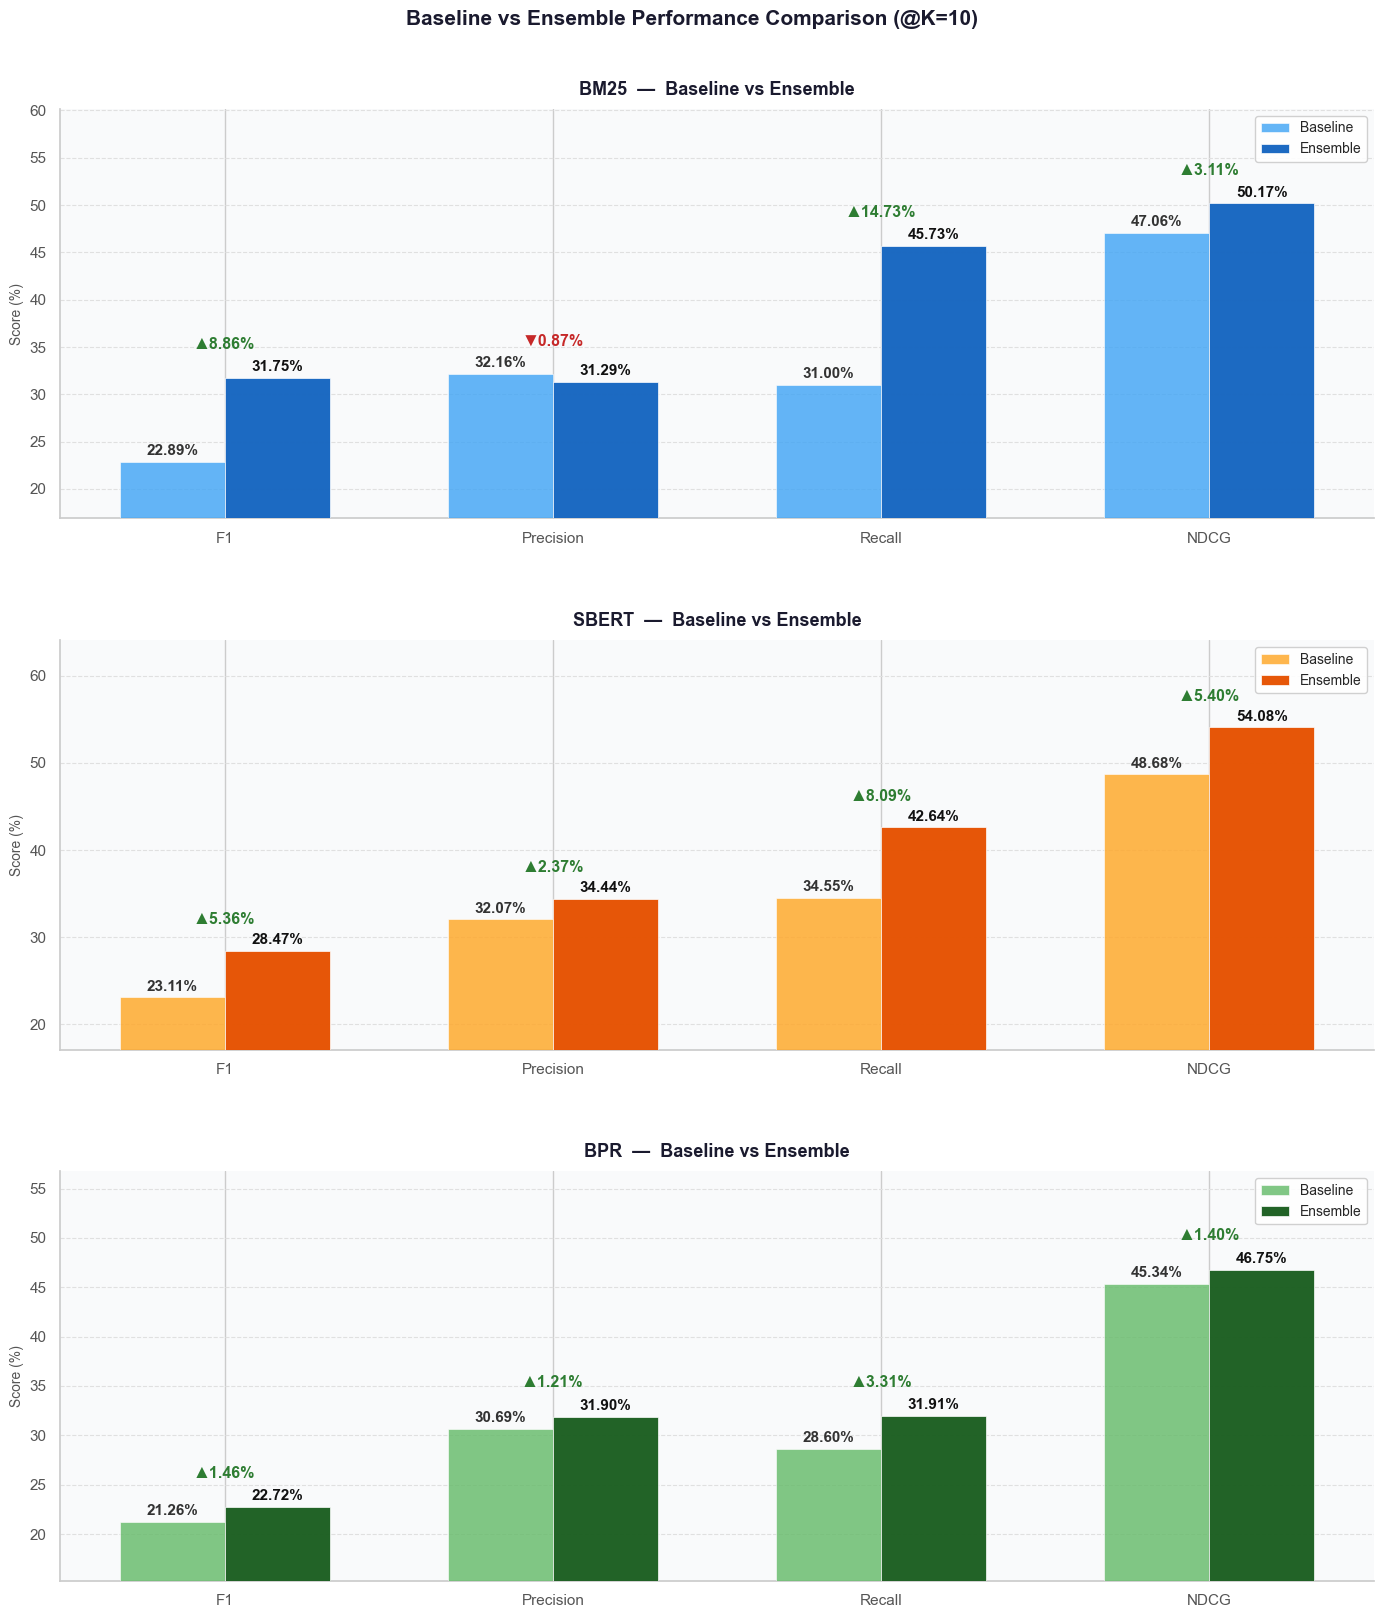

In [ ]:
bm25_base_f1   = globals().get('f1_bm25_baseline', globals().get('f1_bm25', 22.89))
bm25_base_prec = globals().get('precision_bm25_baseline', globals().get('precision_bm25', 32.16))
bm25_base_rec  = globals().get('recall_bm25_baseline', globals().get('recall_bm25', 31.00))
bm25_base_ndcg = globals().get('ndcg_bm25_baseline', globals().get('ndcg_bm25', 47.06))
bm25_ens_f1   = globals().get('f1_bm25_ensemble', globals().get('f1_ens_bm25', 31.75))
bm25_ens_prec = globals().get('precision_bm25_ensemble', globals().get('precision_ens_bm25', 31.29))
bm25_ens_rec  = globals().get('recall_bm25_ensemble', globals().get('recall_ens_bm25', 45.73))
bm25_ens_ndcg = globals().get('ndcg_bm25_ensemble', globals().get('ndcg_ens_bm25', 50.17))

sbert_base_f1   = globals().get('f1_sbert_baseline_loose', 23.11)
sbert_base_prec = globals().get('precision_sbert_baseline_loose', 32.07)
sbert_base_rec  = globals().get('recall_sbert_baseline_loose', 34.55)
sbert_base_ndcg = globals().get('ndcg_sbert_baseline_loose', 48.68)
sbert_ens_f1   = globals().get('f1_sbert_ensemble_loose', 28.47)
sbert_ens_prec = globals().get('precision_sbert_ensemble_loose', 34.44)
sbert_ens_rec  = globals().get('recall_sbert_ensemble_loose', 42.64)
sbert_ens_ndcg = globals().get('ndcg_sbert_ensemble_loose', 54.08)

bpr_base_f1   = globals().get('f1_bpr', 22.24)
bpr_base_prec = globals().get('precision_bpr', 31.38)
bpr_base_rec  = globals().get('recall_bpr', 30.91)
bpr_base_ndcg = globals().get('ndcg_bpr', 46.04)
bpr_ens_f1   = globals().get('f1_bpr_ens', globals().get('f1_ens_bpr', 22.24))
bpr_ens_prec = globals().get('precision_bpr_ens', globals().get('precision_ens_bpr', 31.38))
bpr_ens_rec  = globals().get('recall_bpr_ens', globals().get('recall_ens_bpr', 30.91))
bpr_ens_ndcg = globals().get('ndcg_bpr_ens', globals().get('ndcg_ens_bpr', 46.04))

def sanitize(val):
    if val is None: return 0.0
    return val * 100 if val <= 1.0 and val > 0.0 else val
results = {
    "BM25": {
        "Baseline": {"F1": sanitize(bm25_base_f1), "Precision": sanitize(bm25_base_prec), "Recall": sanitize(bm25_base_rec), "NDCG": sanitize(bm25_base_ndcg)},
        "Ensemble": {"F1": sanitize(bm25_ens_f1),  "Precision": sanitize(bm25_ens_prec),  "Recall": sanitize(bm25_ens_rec),  "NDCG": sanitize(bm25_ens_ndcg)}
    },
    "SBERT": {
        "Baseline": {"F1": sanitize(sbert_base_f1), "Precision": sanitize(sbert_base_prec), "Recall": sanitize(sbert_base_rec), "NDCG": sanitize(sbert_base_ndcg)},
        "Ensemble": {"F1": sanitize(sbert_ens_f1),  "Precision": sanitize(sbert_ens_prec),  "Recall": sanitize(sbert_ens_rec),  "NDCG": sanitize(sbert_ens_ndcg)}
    },
    "BPR": {
        "Baseline": {"F1": sanitize(bpr_base_f1), "Precision": sanitize(bpr_base_prec), "Recall": sanitize(bpr_base_rec), "NDCG": sanitize(bpr_base_ndcg)},
        "Ensemble": {"F1": sanitize(bpr_ens_f1),  "Precision": sanitize(bpr_ens_prec),  "Recall": sanitize(bpr_ens_rec),  "NDCG": sanitize(bpr_ens_ndcg)}
    }
}

metrics      = ["F1", "Precision", "Recall", "NDCG"]
model_labels = ["BM25", "SBERT", "BPR"]
subtitles    = [
    "BM25  —  Baseline vs Ensemble",
    "SBERT  —  Baseline vs Ensemble",
    "BPR  —  Baseline vs Ensemble",
]
colors = {
    "BM25":  {"Baseline": "#42A5F5", "Ensemble": "#1565C0"},
    "SBERT": {"Baseline": "#FFA726", "Ensemble": "#E65100"},
    "BPR":   {"Baseline": "#66BB6A", "Ensemble": "#1B5E20"},
}

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.patch.set_facecolor("white")
bar_w = 0.32
x     = np.arange(len(metrics))

for row_i, model in enumerate(model_labels):
    ax        = axes[row_i]
    ax.set_facecolor("#F9FAFB")
    c_base    = colors[model]["Baseline"]
    c_ens     = colors[model]["Ensemble"]
    base_vals = [results[model]["Baseline"][m] for m in metrics]
    ens_vals  = [results[model]["Ensemble"][m]  for m in metrics]
    bars_b = ax.bar(x - bar_w/2, base_vals, width=bar_w, color=c_base,alpha=0.82, label="Baseline", zorder=3, edgecolor='white', linewidth=0.5)
    bars_e = ax.bar(x + bar_w/2, ens_vals,  width=bar_w, color=c_ens,alpha=0.97, label="Ensemble", zorder=3, edgecolor='white', linewidth=0.5)
    for bar in bars_b:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f"{bar.get_height():.2f}%", ha='center', va='bottom',
                fontsize=11, color='#333333', fontweight='bold')
    for bar in bars_e:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                f"{bar.get_height():.2f}%", ha='center', va='bottom',
                fontsize=11, color='#111111', fontweight='bold')
    for m_i, (bv, ev) in enumerate(zip(base_vals, ens_vals)):
        d   = ev - bv
        col = "#2E7D32" if d >= 0 else "#C62828"
        sym = "▲" if d >= 0 else "▼"
        ax.text(x[m_i], max(bv, ev)+3.0, f"{sym}{abs(d):.2f}%",ha='center', fontsize=11.5, color=col, fontweight='bold')
    ax.set_title(subtitles[row_i], fontsize=13, fontweight='bold', color='#1A1A2E', pad=10)
    ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11, color='#333333')
    ax.tick_params(colors='#555555')
    ax.set_ylabel("Score (%)", fontsize=10, color='#555555')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC'); ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(axis='y', color='#E0E0E0', linestyle='--', linewidth=0.8, zorder=0)
    all_vals = base_vals + ens_vals
    ax.set_ylim(max(0, min(all_vals)-6), max(all_vals)+10)
    ax.legend(fontsize=10, framealpha=0.9, loc='upper right',edgecolor='#CCCCCC', facecolor='white')
plt.suptitle("Baseline vs Ensemble Performance Comparison (@K=10)",fontsize=15, fontweight='bold', color='#1A1A2E', y=1.01)
plt.tight_layout(h_pad=4)
plt.show()

## Comparison Against Ensemble Model

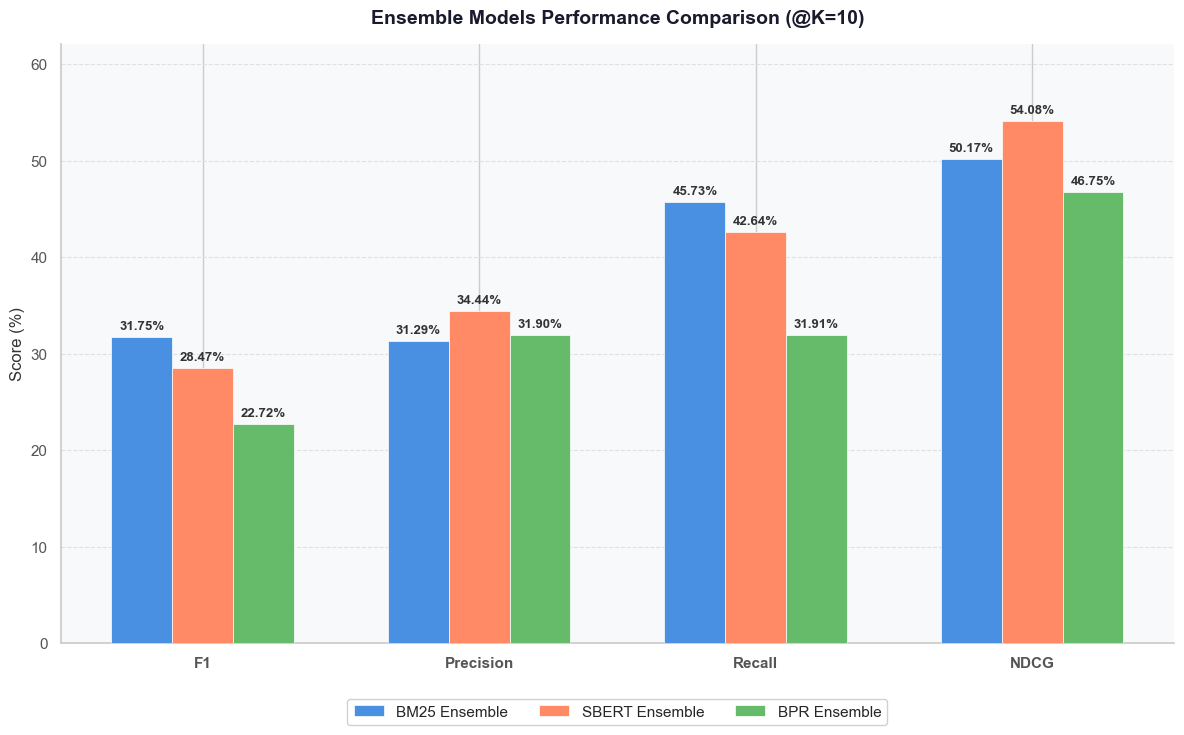

In [ ]:
bm25_ens_f1   = globals().get('f1_bm25_ensemble', globals().get('f1_ens_bm25', 31.75))
bm25_ens_prec = globals().get('precision_bm25_ensemble', globals().get('precision_ens_bm25', 31.29))
bm25_ens_rec  = globals().get('recall_bm25_ensemble', globals().get('recall_ens_bm25', 45.73))
bm25_ens_ndcg = globals().get('ndcg_bm25_ensemble', globals().get('ndcg_ens_bm25', 50.17))

sbert_ens_f1   = globals().get('f1_sbert_ensemble_loose', 28.47)
sbert_ens_prec = globals().get('precision_sbert_ensemble_loose', 34.44)
sbert_ens_rec  = globals().get('recall_sbert_ensemble_loose', 42.64)
sbert_ens_ndcg = globals().get('ndcg_sbert_ensemble_loose', 54.08)

bpr_ens_f1   = globals().get('f1_bpr_ens', globals().get('f1_ens_bpr', 22.24))
bpr_ens_prec = globals().get('precision_bpr_ens', globals().get('precision_ens_bpr', 31.38))
bpr_ens_rec  = globals().get('recall_bpr_ens', globals().get('recall_ens_bpr', 30.91))
bpr_ens_ndcg = globals().get('ndcg_bpr_ens', globals().get('ndcg_ens_bpr', 46.04))

def sanitize(val):
    if val is None: return 0.0
    return val * 100 if val <= 1.0 and val > 0.0 else val
ens_results = {
    "BM25 Ensemble": {
        "F1": sanitize(bm25_ens_f1),
        "Precision": sanitize(bm25_ens_prec),
        "Recall": sanitize(bm25_ens_rec),
        "NDCG": sanitize(bm25_ens_ndcg)
    },
    "SBERT Ensemble": {
        "F1": sanitize(sbert_ens_f1),
        "Precision": sanitize(sbert_ens_prec),
        "Recall": sanitize(sbert_ens_rec),
        "NDCG": sanitize(sbert_ens_ndcg)
    },
    "BPR Ensemble": {
        "F1": sanitize(bpr_ens_f1),
        "Precision": sanitize(bpr_ens_prec),
        "Recall": sanitize(bpr_ens_rec),
        "NDCG": sanitize(bpr_ens_ndcg)
    }
}

metrics = ["F1", "Precision", "Recall", "NDCG"]
models  = list(ens_results.keys())

fig, ax = plt.subplots(figsize=(12, 7.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("#F8F9FA")
bar_width = 0.22
x = np.arange(len(metrics))
colors = ["#4A90E2", "#FF8A65", "#66BB6A"]
bars_bm25  = ax.bar(x - bar_width, [ens_results[models[0]][m] for m in metrics],
                    width=bar_width, color=colors[0], label=models[0], zorder=3, edgecolor='white', linewidth=0.5)
bars_sbert = ax.bar(x, [ens_results[models[1]][m] for m in metrics],
                    width=bar_width, color=colors[1], label=models[1], zorder=3, edgecolor='white', linewidth=0.5)
bars_bpr   = ax.bar(x + bar_width, [ens_results[models[2]][m] for m in metrics],
                    width=bar_width, color=colors[2], label=models[2], zorder=3, edgecolor='white', linewidth=0.5)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f"{height:.2f}%", ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#333333')
add_labels(bars_bm25)
add_labels(bars_sbert)
add_labels(bars_bpr)
ax.set_title("Ensemble Models Performance Comparison (@K=10)", fontsize=14, fontweight='bold', color='#1A1A2E', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12, color='#333333', fontweight='bold')
ax.tick_params(colors='#555555', labelsize=11)
ax.set_ylabel("Score (%)", fontsize=12, color='#333333')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(axis='y', color='#E0E0E0', linestyle='--', linewidth=0.8, zorder=0)
all_values = [val for model_data in ens_results.values() for val in model_data.values()]
ax.set_ylim(0, max(all_values) + 8)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=3,fontsize=11, framealpha=0.9, edgecolor='#CCCCCC', facecolor='white')
plt.tight_layout()
plt.show()

## Compare with Research paper

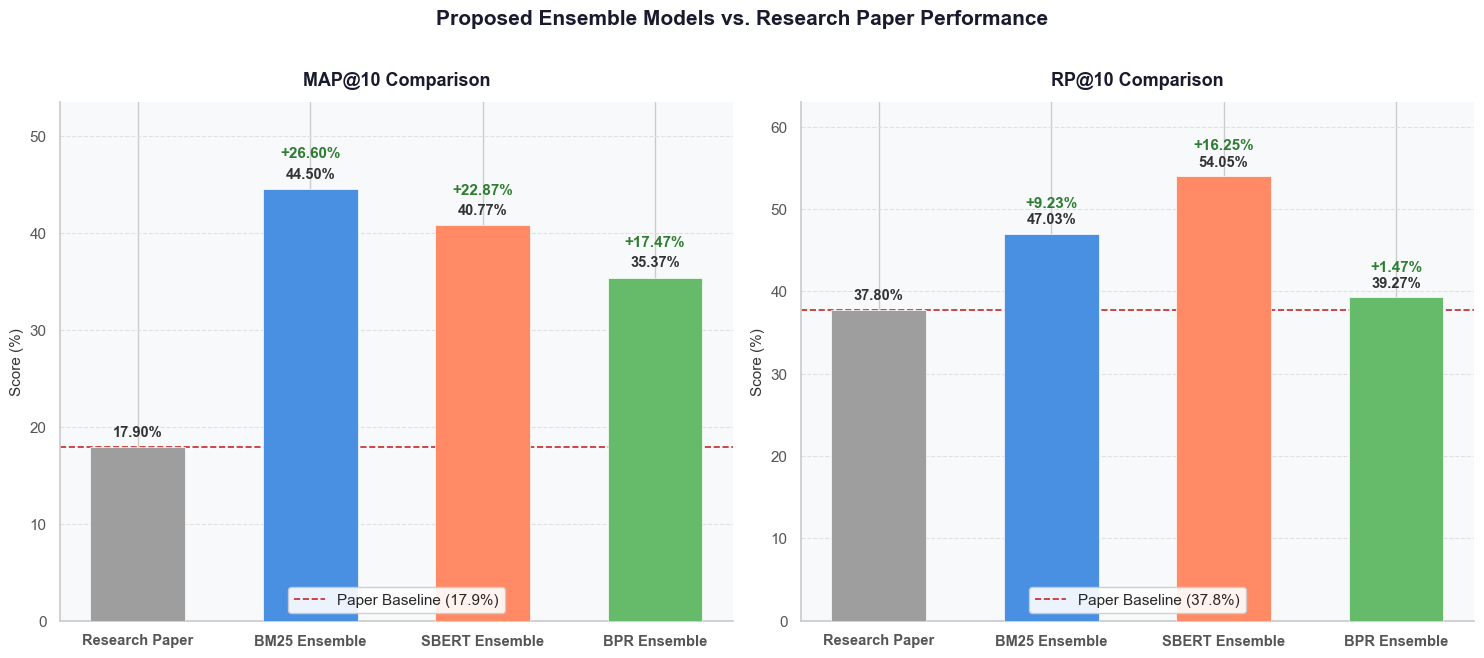

In [ ]:
bm25_map10 = globals().get('map_10_score', 44.24)
bm25_rp10  = globals().get('rp_10_score', 46.92)
sbert_map10 = globals().get('map10_ens', 42.14)
sbert_rp10  = globals().get('rp10_ens', 56.29)
bpr_map10 = globals().get('map10_bpr_ens', globals().get('map10_ens', 34.92))
bpr_rp10  = globals().get('rp10_bpr_ens', globals().get('rp10_ens', 38.68))

def sanitize(val):
    if val is None: return 0.0
    return val * 100 if val <= 1.0 and val > 0.0 else val
models = ["Research Paper", "BM25 Ensemble", "SBERT Ensemble", "BPR Ensemble"]
map_scores = [17.90, sanitize(bm25_map10), sanitize(sbert_map10), sanitize(bpr_map10)]
rp_scores  = [37.80, sanitize(bm25_rp10),  sanitize(sbert_rp10),  sanitize(bpr_rp10)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor("white")
colors = ["#9E9E9E", "#4A90E2", "#FF8A65", "#66BB6A"]
metrics_data = [
    {"title": "MAP@10 Comparison", "scores": map_scores, "baseline": 17.90},
    {"title": "RP@10 Comparison",  "scores": rp_scores,  "baseline": 37.80}
]

for idx, ax in enumerate(axes):
    ax.set_facecolor("#F8F9FA")
    data = metrics_data[idx]
    bars = ax.bar(models, data["scores"], color=colors, zorder=3, edgecolor='white', linewidth=0.5, width=0.55)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.8,f"{height:.2f}%", ha='center', va='bottom', fontsize=10.5, fontweight='bold', color='#333333')
    ax.axhline(y=data["baseline"], color="#C62828", linestyle="--", linewidth=1.2, zorder=2, label=f"Paper Baseline ({data['baseline']:.1f}%)")
    for i in range(1, len(models)):
        diff = data["scores"][i] - data["baseline"]
        ax.text(i, data["scores"][i] + 3.2, f"+{diff:.2f}%", ha='center', fontsize=11, color='#2E7D32', fontweight='bold')
    ax.set_title(data["title"], fontsize=13, fontweight='bold', color='#1A1A2E', pad=12)
    ax.tick_params(colors='#555555', labelsize=11)
    ax.set_ylabel("Score (%)", fontsize=11, color='#333333')
    ax.set_xticklabels(models, fontsize=10.5, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.grid(axis='y', color='#E0E0E0', linestyle='--', linewidth=0.8, zorder=0)
    ax.set_ylim(0, max(data["scores"]) + 9)
    ax.legend(loc='lower center', framealpha=0.9, edgecolor='#CCCCCC', facecolor='white')
plt.suptitle("Proposed Ensemble Models vs. Research Paper Performance", fontsize=15, fontweight='bold', color='#1A1A2E', y=1.01)
plt.tight_layout()
plt.show()